# Trial-by-Trial Neural Dynamics — CISI Protocol

Pipeline:
1. Load BLA epochs (subject 5, BLA channel group: T7, T8, TP7, TP8)
2. Stack subjects & grand-average ERP (`data_bc` and `data_bc_z` from step 1)
3. ERP visualization per channel
4. Feature extraction (§4b): A/T/ant time windows (mean + peak + latency), Welch θ/α/β vs baseline, anticipation 200–500 ms, stability (template r + trial distance)
5. Trial-by-trial plots with rolling mean


In [2]:
#! pip install mne

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path
from utils import load_eeg_data, CHANNEL_GROUPS

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

%load_ext autoreload
%autoreload 2

## 1. Load Data

Stores **`data_bc`** (µV, baseline mean removed) and **`data_bc_z`** (same, then per-subject × channel z-score). Downstream sections keep **both** variants.

In [4]:
CONDITION   = "P1"
SUBJECT_IDS = np.setdiff1d(np.arange(1,18,1), [1, 4, 14])
CHANNELS    = "CISI"                 # T7, T8, TP7, TP8
FREQ_BANDS  = "delta_beta"          # 0.5–30Hz

all_sub_data = {}
all_trial_rows = []

BASELINE_TMIN = -0.500   # −500 ms before stimulus (seconds)
BASELINE_TMAX = -0.050   # −50 ms before stimulus

for sub_id in SUBJECT_IDS:
    epochs = load_eeg_data(CONDITION, sub_id, channels=CHANNELS, freq_band=FREQ_BANDS)

    data = epochs.get_data() * 1e6   # (n_trials, n_channels, n_times), µV
    times = epochs.times
    ch_names = epochs.ch_names
    sfreq = epochs.info["sfreq"]

    n_trials, n_channels, n_times = data.shape

    baseline_mask = (times >= BASELINE_TMIN) & (times <= BASELINE_TMAX)
    if baseline_mask.sum() == 0:
        raise ValueError(
            f"Subject {sub_id}: no samples in baseline [{BASELINE_TMIN}, {BASELINE_TMAX}] s"
        )
    baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)
    data_bc = data - baseline_mean   # µV after baseline subtraction (no z-score)

    data_bc_z = data_bc.copy()
    # Z-score per subject, per channel: mean/std over all trials × all time points
    for c in range(n_channels):
        x = data_bc_z[:, c, :]
        mu = np.nanmean(x)
        sig = np.nanstd(x)
        if sig > 0:
            data_bc_z[:, c, :] = (x - mu) / sig
        else:
            data_bc_z[:, c, :] = x - mu

    all_sub_data[sub_id] = {
        "epochs": epochs,
        "data": data,
        "data_bc": data_bc,
        "data_bc_z": data_bc_z,
        "times": times,
        "ch_names": ch_names,
        "sfreq": sfreq,
        "n_trials": n_trials,
        "n_channels": n_channels,
        "n_times": n_times,
    }

    for t in range(n_trials):
        all_trial_rows.append({
            "sub_id": sub_id,
            "trial_index": t + 1,
        })

    print(
        f"Loaded Subject {sub_id} | trials={n_trials}, "
        f"channels={n_channels}, times={n_times}"
    )

ref_sub = SUBJECT_IDS[0]
times = all_sub_data[ref_sub]["times"]
ch_names = all_sub_data[ref_sub]["ch_names"]
time_ms = times * 1000

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/krabstse/Desktop/GT/课程/Physics of Cognition/Project/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 2 | trials=60, channels=8, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Loaded Subject 3 | trials=60, channels=8, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/krabstse/Desktop/GT/课程/Physics of Cognition/Project/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/Users/krabstse/Desktop/GT/课程/Physics of Cognition/Project/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 5 | trials=60, channels=8, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


...

Loaded Subject 12 | trials=60, channels=8, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Loaded Subject 13 | trials=60, channels=8, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/krabstse/Desktop/GT/课程/Physics of Cognition/Project/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/Users/krabstse/Desktop/GT/课程/Physics of Cognition/Project/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 15 | trials=60, channels=8, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Loaded Subject 16 | trials=60, channels=8, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/krabstse/Desktop/GT/课程/Physics of Cognition/Project/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/Users/krabstse/Desktop/GT/课程/Physics of Cognition/Project/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 17 | trials=60, channels=8, times=1792


### 1b. Grand-average time series (all subjects × all trials)

`data_bc`: baseline mean in **−500 ms to −50 ms** subtracted per trial × channel (µV). **`data_bc_z`**: same baseline removal, then **per-subject, per-channel z-score** over all trials × time. **Thin lines:** each electrode in `CHANNEL_GROUPS[CHANNELS]` order (CISI: T7, TP7, T8, TP8, C3, CP1, C4, CP2). **Thick lines:** pooled mean over **T ∪ TP** and **C ∪ CP** (mean across pooled channels per trial, then grand average). **§1b** plots **both** variants (µV vs z).

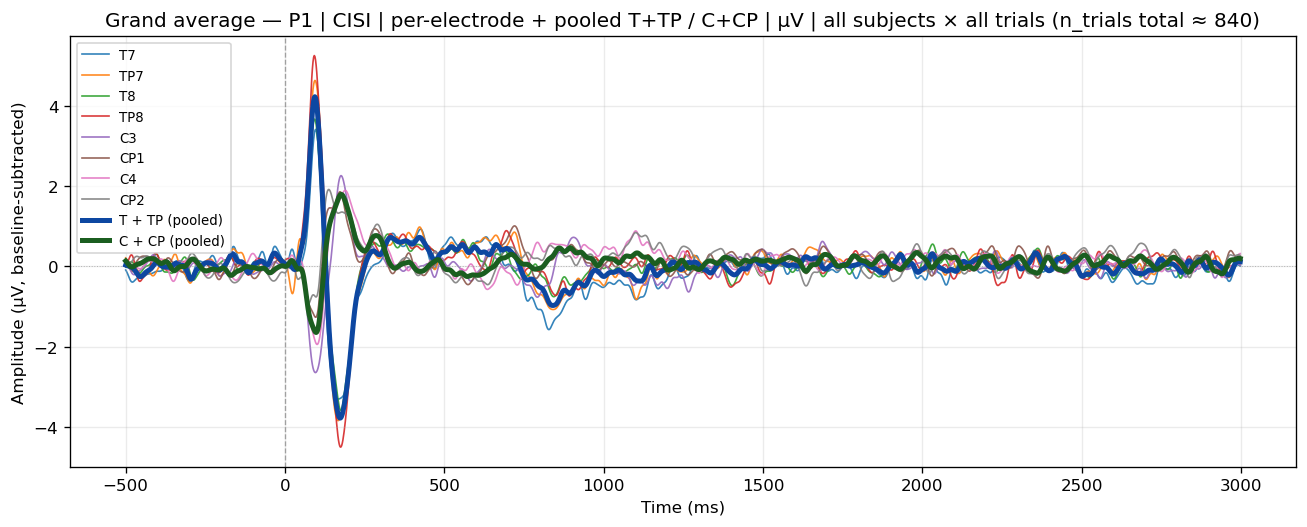

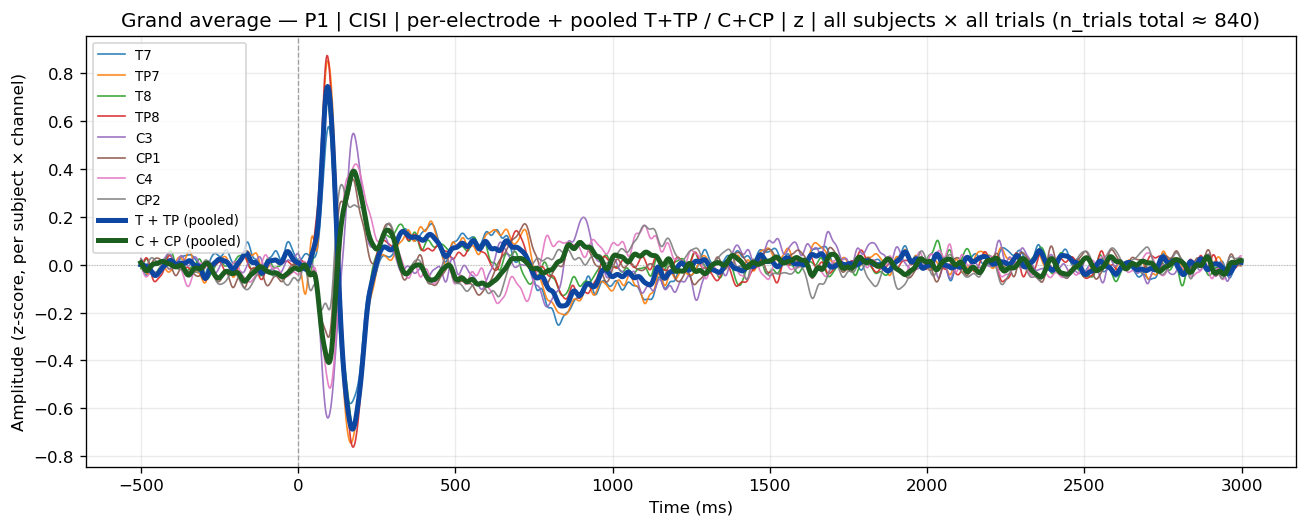

In [5]:
# Grand-average ERP: (1) one thin line per electrode, (2) thick pooled T+TP and C+CP
REGIONS_DICT_LOAD = {
    "CISI": {
        "T": ["T7", "T8"],
        "TP": ["TP7", "TP8"],
        "C": ["C3", "C4"],
        "CP": ["CP1", "CP2"],
    },
    "BLA": {"T": ["T7", "T8"], "TP": ["TP7", "TP8"]},
    "BLT": {"C": ["C3", "C4"], "CP": ["CP1", "CP2"]},
    "VISI": {
        "C": ["C3", "C4"],
        "CP": ["CP1", "CP2"],
        "F": ["F3", "F4"],
        "FC": ["FC1", "FC2", "FC5", "FC6"],
    },
    "RS": {
        "C": ["C3", "C4"],
        "CP": ["CP1", "CP2"],
        "P": ["P1", "P2", "P5", "P6"],
    },
}

regions_of_interest = REGIONS_DICT_LOAD.get(CHANNELS, {})
if not regions_of_interest:
    raise ValueError(f"No subregion map for CHANNELS={CHANNELS!r}")


def grand_avg_roi(roi_chs, data_key="data_bc"):
    """Mean over listed channels per trial, then mean over all trials × subjects."""
    if not roi_chs:
        return None
    stacks = []
    for sub_id in SUBJECT_IDS:
        pack = all_sub_data[sub_id]
        data_bc = pack[data_key]
        names = pack["ch_names"]
        idx = [names.index(ch) for ch in roi_chs if ch in names]
        if not idx:
            continue
        region_ts = data_bc[:, idx, :].mean(axis=1)
        stacks.append(region_ts)
    if not stacks:
        return None
    all_trials = np.concatenate(stacks, axis=0)
    return all_trials.mean(axis=0)


def merge_region_channels(*keys):
    out = []
    for k in keys:
        if k in regions_of_interest:
            out.extend(regions_of_interest[k])
    return out


# Electrode order: same as CHANNEL_GROUPS (CISI: T7, TP7, T8, TP8, C3, CP1, C4, CP2)
ch_order = CHANNEL_GROUPS.get(CHANNELS, list(ch_names))
ref_names = set(all_sub_data[SUBJECT_IDS[0]]["ch_names"])

for data_key, ylab, unit_tag in [
    ("data_bc", "Amplitude (µV, baseline-subtracted)", "µV"),
    ("data_bc_z", "Amplitude (z-score, per subject × channel)", "z"),
]:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    for i, ch in enumerate(ch_order):
        if ch not in ref_names:
            continue
        mean_ts = grand_avg_roi([ch], data_key=data_key)
        if mean_ts is None:
            continue
        ax.plot(
            time_ms,
            mean_ts,
            label=ch,
            color=f"C{i % 10}",
            linewidth=1.0,
            alpha=0.9,
            zorder=1,
        )

    # Pooled T+TP and C+CP (thicker; mean over pooled channels per trial, then grand average)
    if {"T", "TP"} <= set(regions_of_interest.keys()):
        chs_tt = merge_region_channels("T", "TP")
        m_tt = grand_avg_roi(chs_tt, data_key=data_key)
        if m_tt is not None:
            ax.plot(
                time_ms,
                m_tt,
                label="T + TP (pooled)",
                color="#0d47a1",
                linewidth=3.0,
                zorder=4,
            )
    if {"C", "CP"} <= set(regions_of_interest.keys()):
        chs_cc = merge_region_channels("C", "CP")
        m_cc = grand_avg_roi(chs_cc, data_key=data_key)
        if m_cc is not None:
            ax.plot(
                time_ms,
                m_cc,
                label="C + CP (pooled)",
                color="#1b5e20",
                linewidth=3.0,
                zorder=4,
            )

    ax.axvline(0.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.axhline(0.0, color="gray", linestyle=":", linewidth=0.6, alpha=0.5)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel(ylab)
    ax.set_title(
        f"Grand average — {CONDITION} | {CHANNELS} | per-electrode + pooled T+TP / C+CP | "
        f"{unit_tag} | all subjects × all trials (n_trials total ≈ {sum(all_sub_data[s]['n_trials'] for s in SUBJECT_IDS)})"
    )
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

## 2. Concatenate subjects & grand-average ERP

Uses `data_bc` and `data_bc_z` from **§1**. Stacks trials twice (µV vs z) and computes `grand_avg_by_channel` / `grand_avg_auditory` / `grand_avg_tactile` for each, plus `*_z` variants.

In [6]:
# Requires §1 Load Data: `data_bc` and `data_bc_z` in all_sub_data.
if not all_sub_data:
    raise RuntimeError("Run §1 Load Data first — all_sub_data is empty.")

all_data_bc_list = [all_sub_data[s]["data_bc"] for s in SUBJECT_IDS]
all_data_bc_z_list = [all_sub_data[s]["data_bc_z"] for s in SUBJECT_IDS]

# Sanity print (must match §1 baseline window: −500 ms to −50 ms)
_ref = SUBJECT_IDS[0]
_times = all_sub_data[_ref]["times"]
_bmask = (_times >= -0.500) & (_times <= -0.050)
print(
    f"Baseline reference (sub {_ref}): {_bmask.sum()} samples "
    f"({_times[_bmask][0]*1000:.0f} ms to {_times[_bmask][-1]*1000:.0f} ms)"
)
for s in SUBJECT_IDS:
    print(f"  sub {s}: data_bc {all_sub_data[s]['data_bc'].shape}, data_bc_z {all_sub_data[s]['data_bc_z'].shape}")

# Concatenate all subjects (trial axis)
all_data_bc = np.concatenate(all_data_bc_list, axis=0)   # (total_trials, n_channels, n_times)
all_data_bc_z = np.concatenate(all_data_bc_z_list, axis=0)

print("All-subject concatenated data_bc shape:", all_data_bc.shape)
print("All-subject concatenated data_bc_z shape:", all_data_bc_z.shape)

_ref_ch_names = list(all_sub_data[SUBJECT_IDS[0]]["ch_names"])
AUDITORY_ROI_GRAND = ["T7", "T8", "TP7", "TP8"]
SOMATO_ROI_GRAND = ["C3", "C4", "CP1", "CP2"]

def _compute_grand_avg_stack(stack):
    """Channel-wise GA + pooled T+TP and C+CP (not all 8 electrodes)."""
    g_ch = np.nanmean(stack, axis=0)   # (n_channels, T)

    def _roi_grand_avg(ch_list):
        idx = [_ref_ch_names.index(ch) for ch in ch_list]
        return np.nanmean(g_ch[idx, :], axis=0)

    return g_ch, _roi_grand_avg(AUDITORY_ROI_GRAND), _roi_grand_avg(SOMATO_ROI_GRAND)

grand_avg_by_channel, grand_avg_auditory, grand_avg_tactile = _compute_grand_avg_stack(all_data_bc)
grand_avg_by_channel_z, grand_avg_auditory_z, grand_avg_tactile_z = _compute_grand_avg_stack(all_data_bc_z)

print("grand_avg_by_channel (µV) shape:", grand_avg_by_channel.shape)
print("grand_avg_auditory / tactile (µV) shapes:", grand_avg_auditory.shape, grand_avg_tactile.shape)
print("grand_avg_by_channel_z shape:", grand_avg_by_channel_z.shape)
print("grand_avg_auditory_z / tactile_z shapes:", grand_avg_auditory_z.shape, grand_avg_tactile_z.shape)


Baseline reference (sub 2): 231 samples (-500 ms to -51 ms)
  sub 2: data_bc (60, 8, 1792), data_bc_z (60, 8, 1792)
  sub 3: data_bc (60, 8, 1792), data_bc_z (60, 8, 1792)
  sub 5: data_bc (60, 8, 1792), data_bc_z (60, 8, 1792)
  sub 6: data_bc (60, 8, 1792), data_bc_z (60, 8, 1792)
  sub 7: data_bc (60, 8, 1792), data_bc_z (60, 8, 1792)
  sub 8: data_bc (60, 8, 1792), data_bc_z (60, 8, 1792)
  sub 9: data_bc (60, 8, 1792), data_bc_z (60, 8, 1792)
  sub 10: data_bc (60, 8, 1792), data_bc_z (60, 8, 1792)
  sub 11: data_bc (60, 8, 1792), data_bc_z (60, 8, 1792)
  sub 12: data_bc (60, 8, 1792), data_bc_z (60, 8, 1792)
  sub 13: data_bc (60, 8, 1792), data_bc_z (60, 8, 1792)
  sub 15: data_bc (60, 8, 1792), data_bc_z (60, 8, 1792)
  sub 16: data_bc (60, 8, 1792), data_bc_z (60, 8, 1792)
  sub 17: data_bc (60, 8, 1792), data_bc_z (60, 8, 1792)
All-subject concatenated data_bc shape: (840, 8, 1792)
All-subject concatenated data_bc_z shape: (840, 8, 1792)
grand_avg_by_channel (µV) shape: (8, 

## 3. ERP Visualization per Channel

Average across all trials to reveal the event-related potential. **Pooled ROI curves** are **T∪TP** (auditory) vs **C∪CP** (somatosensory) separately — not one average over all eight electrodes. **Colored shaded bands** use **`final_start_ms` / `final_end_ms`** from **§3 detection** (`res_aud_*`, `res_tac_*`) when you run the detection cell before plotting; vertical lines at **0 ms** (auditory) and **500 ms** (tactile).

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_peak_in_window(time_ms, signal, window_ms, polarity="pos"):
    """
    在给定时间窗内找 peak / trough

    Parameters
    ----------
    time_ms : array-like, shape [T]
    signal : array-like, shape [T]
    window_ms : [start_ms, end_ms]
    polarity : {"pos", "neg"}
        pos: 找最大值
        neg: 找最小值

    Returns
    -------
    out : dict
        {
            "peak_idx": int or None,
            "peak_time_ms": float or np.nan,
            "peak_amp": float or np.nan,
            "search_start_ms": float,
            "search_end_ms": float,
            "polarity": str,
        }
    """
    time_ms = np.asarray(time_ms, dtype=float)
    signal = np.asarray(signal, dtype=float)

    start_ms, end_ms = window_ms
    mask = (time_ms >= start_ms) & (time_ms <= end_ms)

    if not np.any(mask):
        return {
            "peak_idx": None,
            "peak_time_ms": np.nan,
            "peak_amp": np.nan,
            "search_start_ms": start_ms,
            "search_end_ms": end_ms,
            "polarity": polarity,
        }

    idx_local = np.where(mask)[0]
    seg = signal[idx_local]

    if polarity == "pos":
        best_local = np.nanargmax(seg)
    elif polarity == "neg":
        best_local = np.nanargmin(seg)
    else:
        raise ValueError("polarity must be 'pos' or 'neg'")

    peak_idx = idx_local[best_local]

    return {
        "peak_idx": int(peak_idx),
        "peak_time_ms": float(time_ms[peak_idx]),
        "peak_amp": float(signal[peak_idx]),
        "search_start_ms": float(start_ms),
        "search_end_ms": float(end_ms),
        "polarity": polarity,
    }


def _default_half_width_ms(peak_time_ms):
    """
    根据 peak latency 自动决定最终窗半宽
    """
    if peak_time_ms < 120:
        return 15.0
    elif peak_time_ms < 250:
        return 25.0
    else:
        return 40.0


def build_final_window_from_peak(
    peak_time_ms,
    half_width_ms=None,
    min_time_ms=None,
    max_time_ms=None,
):
    """
    由 peak time 生成最终分析窗
    """
    if np.isnan(peak_time_ms):
        return [np.nan, np.nan]

    if half_width_ms is None:
        half_width_ms = _default_half_width_ms(peak_time_ms)

    tw = [peak_time_ms - half_width_ms, peak_time_ms + half_width_ms]

    if min_time_ms is not None:
        tw[0] = max(tw[0], min_time_ms)
    if max_time_ms is not None:
        tw[1] = min(tw[1], max_time_ms)

    return [float(tw[0]), float(tw[1])]


def detect_erp_windows_from_grand_avg(
    time_ms,
    grand_avg,
    search_windows,
    polarity_map=None,
    half_width_map=None,
    min_time_ms=None,
    max_time_ms=None,
):
    """
    在 grand average 上自动检测 ERP 成分，并生成最终时间窗

    Parameters
    ----------
    time_ms : array-like, shape [T]
    grand_avg : array-like, shape [T]
    search_windows : dict
        例如:
        {
            "P50": [30, 80],
            "N1": [70, 140],
            "P2": [130, 220],
            "N2": [180, 300],
            "P3": [250, 450],
        }

    polarity_map : dict or None
        例如:
        {
            "P50": "pos",
            "N1": "neg",
            "P2": "pos",
            "N2": "neg",
            "P3": "pos",
        }
        如果不提供，默认全是 "pos"

    half_width_map : dict or None
        每个成分最终窗半宽（ms）
        例如:
        {
            "P50": 12,
            "N1": 15,
            "P2": 20,
            "N2": 25,
            "P3": 40,
        }
        不提供则自动按 peak latency 决定

    Returns
    -------
    res_df : pd.DataFrame
        index 为 component name
        columns:
            peak_idx
            peak_time_ms
            peak_amp
            search_start_ms
            search_end_ms
            polarity
            final_start_ms
            final_end_ms
            final_half_width_ms
    """
    time_ms = np.asarray(time_ms, dtype=float)
    grand_avg = np.asarray(grand_avg, dtype=float)

    if polarity_map is None:
        polarity_map = {k: "pos" for k in search_windows}

    rows = []
    for comp, tw in search_windows.items():
        polarity = polarity_map.get(comp, "pos")

        peak_info = _find_peak_in_window(
            time_ms=time_ms,
            signal=grand_avg,
            window_ms=tw,
            polarity=polarity,
        )

        peak_time = peak_info["peak_time_ms"]

        if half_width_map is not None and comp in half_width_map:
            half_width = float(half_width_map[comp])
        else:
            half_width = _default_half_width_ms(peak_time) if not np.isnan(peak_time) else np.nan

        final_tw = build_final_window_from_peak(
            peak_time_ms=peak_time,
            half_width_ms=half_width if not np.isnan(half_width) else None,
            min_time_ms=min_time_ms,
            max_time_ms=max_time_ms,
        )

        row = {
            "component": comp,
            **peak_info,
            "final_start_ms": final_tw[0],
            "final_end_ms": final_tw[1],
            "final_half_width_ms": half_width,
        }
        rows.append(row)

    res_df = pd.DataFrame(rows).set_index("component")
    return res_df


def plot_grand_avg_with_windows(
    time_ms,
    grand_avg,
    res_df,
    title="Grand Average ERP with Detected Windows",
    figsize=(10, 5),
):
    """
    画 grand average，并标注 peak 和 final windows
    """
    time_ms = np.asarray(time_ms, dtype=float)
    grand_avg = np.asarray(grand_avg, dtype=float)

    plt.figure(figsize=figsize)
    plt.plot(time_ms, grand_avg, linewidth=2, label="grand avg", color="black")
    plt.axvline(0, linestyle="--", alpha=0.6)

    y_min = np.nanmin(grand_avg)
    y_max = np.nanmax(grand_avg)
    y_span = y_max - y_min if y_max > y_min else 1.0

    for comp, row in res_df.iterrows():
        fs = row["final_start_ms"]
        fe = row["final_end_ms"]
        pt = row["peak_time_ms"]
        pa = row["peak_amp"]
        color = "orange" if row["polarity"] == "pos" else "cyan"

        if not np.isnan(fs) and not np.isnan(fe):
            plt.axvspan(fs, fe, alpha=0.15, color=color)

        if not np.isnan(pt) and not np.isnan(pa):
            plt.scatter([pt], [pa], s=60, color=color)
            plt.text(
                pt,
                pa + 0.03 * y_span,
                f"{comp}\n{pt:.1f} ms",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    plt.xlim(-200, 900)
    plt.ylim(-1.5, 1.5)
    plt.xticks(np.arange(-200, 901, 50))
    plt.xlabel("Time (ms)")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# Fixed A-locked / T-locked windows (ms on epoch axis; fallback if §3 detection not passed)
A_ERP_WINDOWS_MS = {
    "P50_A": (30, 100),
    "N1_A": (80, 160),
    "P2_A": (150, 250),
    "N2_A": (180, 320),
    "P3_A": (250, 500),
}
T_ERP_WINDOWS_MS = {
    "P50_T": (520, 570),
    "N1_T": (550, 620),
    "P2_T": (600, 700),
    "N2_T": (630, 760),
    "P3_T": (720, 900),
}
_A_SHADE_COLORS = ["#e3f2fd", "#bbdefb", "#90caf9", "#64b5f6", "#42a5f5"]
_T_SHADE_COLORS = ["#fff3e0", "#ffe0b2", "#ffcc80", "#ffb74d", "#ffa726"]


def _row_final_or_search_ms(row):
    fs = float(row["final_start_ms"])
    fe = float(row["final_end_ms"])
    if np.isnan(fs) or np.isnan(fe):
        fs = float(row["search_start_ms"])
        fe = float(row["search_end_ms"])
    return fs, fe


def shade_a_t_erp_windows(ax, y_min=None, y_max=None, res_aud_df=None, res_tac_df=None):
    """Shade A/T windows. If `res_aud_df` and `res_tac_df` are set (§3 detection), use final_* ms; else fixed dicts."""
    if y_min is None or y_max is None:
        y_min, y_max = ax.get_ylim()
    ax.axvline(0, color="black", linestyle="--", linewidth=1.0, alpha=0.75, zorder=1)
    ax.axvline(500, color="black", linestyle=":", linewidth=1.0, alpha=0.75, zorder=1)
    span = y_max - y_min if y_max > y_min else 1.0
    if res_aud_df is not None and res_tac_df is not None:
        for i, (name, row) in enumerate(res_aud_df.iterrows()):
            t0, t1 = _row_final_or_search_ms(row)
            ax.axvspan(t0, t1, alpha=0.35, color=_A_SHADE_COLORS[i % len(_A_SHADE_COLORS)], zorder=0)
            ax.text((t0 + t1) / 2, y_max - 0.04 * span, name, ha="center", va="top", fontsize=8, color="#1a237e")
        for i, (name, row) in enumerate(res_tac_df.iterrows()):
            t0, t1 = _row_final_or_search_ms(row)
            ax.axvspan(t0, t1, alpha=0.35, color=_T_SHADE_COLORS[i % len(_T_SHADE_COLORS)], zorder=0)
            ax.text((t0 + t1) / 2, y_min + 0.04 * span, name, ha="center", va="bottom", fontsize=8, color="#bf360c")
    else:
        for i, (name, (t0, t1)) in enumerate(A_ERP_WINDOWS_MS.items()):
            ax.axvspan(t0, t1, alpha=0.35, color=_A_SHADE_COLORS[i % len(_A_SHADE_COLORS)], zorder=0)
            ax.text((t0 + t1) / 2, y_max - 0.04 * span, name, ha="center", va="top", fontsize=8, color="#1a237e")
        for i, (name, (t0, t1)) in enumerate(T_ERP_WINDOWS_MS.items()):
            ax.axvspan(t0, t1, alpha=0.35, color=_T_SHADE_COLORS[i % len(_T_SHADE_COLORS)], zorder=0)
            ax.text((t0 + t1) / 2, y_min + 0.04 * span, name, ha="center", va="bottom", fontsize=8, color="#bf360c")


def plot_grand_avg_with_at_windows(
    time_ms,
    grand_avg,
    grand_avg2=None,
    label1="grand avg",
    label2="Somatosensory (C+CP)",
    title="Grand average ERP — A-locked & T-locked windows",
    ylabel="Amplitude (z-score, per subject × channel)",
    figsize=(10, 5),
    xlim=(-200, 900),
    res_aud_df=None,
    res_tac_df=None,
):
    """One or two ROI pooled ERP traces; A/T shading uses `res_aud_df`/`res_tac_df` (final_* ms) when given."""
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    time_ms = np.asarray(time_ms, dtype=float)
    grand_avg = np.asarray(grand_avg, dtype=float)
    fig, ax = plt.subplots(figsize=figsize)
    c1 = "black" if grand_avg2 is None else "#1f77b4"
    ax.plot(time_ms, grand_avg, linewidth=2, color=c1, label=label1, zorder=2)
    y_min = float(np.nanmin(grand_avg))
    y_max = float(np.nanmax(grand_avg))
    legend_lines = [Line2D([0], [0], color=c1, lw=2, label=label1)]
    if grand_avg2 is not None:
        g2 = np.asarray(grand_avg2, dtype=float)
        ax.plot(time_ms, g2, linewidth=2, color="crimson", label=label2, zorder=2)
        y_min = min(y_min, float(np.nanmin(g2)))
        y_max = max(y_max, float(np.nanmax(g2)))
        legend_lines.append(Line2D([0], [0], color="crimson", lw=2, label=label2))
    shade_a_t_erp_windows(ax, y_min=y_min, y_max=y_max, res_aud_df=res_aud_df, res_tac_df=res_tac_df)
    ax.set_xlim(xlim)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    ax.legend(
        handles=legend_lines + [
            Patch(facecolor=_A_SHADE_COLORS[1], alpha=0.35, edgecolor="none", label="A-locked (0 ms)"),
            Patch(facecolor=_T_SHADE_COLORS[1], alpha=0.35, edgecolor="none", label="T-locked (500 ms)"),
        ],
        loc="upper right",
        fontsize=8,
    )
    plt.tight_layout()
    plt.show()

In [8]:
# Search windows (ms, absolute epoch: 0 = auditory onset, ~500 = tactile onset).
# Five components per modality (same as BLA 2: P50…P3); keys suffixed _A / _T.
auditory_search = {
    "P50_A": [30, 100],
    "N1_A": [80, 160],
    "P2_A": [150, 250],
    "N2_A": [180, 320],
    "P3_A": [250, 500],
}

tactile_search = {
    "P50_T": [520, 570],
    "N1_T": [550, 620],
    "P2_T": [600, 700],
    "N2_T": [630, 760],
    "P3_T": [720, 900],
}

half_width_map = {
    "P50_A": 15,
    "N1_A": 25,
    "P2_A": 25,
    "N2_A": 25,
    "P3_A": 50,
    "P50_T": 15,
    "N1_T": 25,
    "P2_T": 25,
    "N2_T": 25,
    "P3_T": 50,
}

auditory_polarity = {
    "P50_A": "pos",
    "N1_A": "neg",
    "P2_A": "pos",
    "N2_A": "neg",
    "P3_A": "pos",
}

tactile_polarity = {
    "P50_T": "pos",
    "N1_T": "neg",
    "P2_T": "pos",
    "N2_T": "neg",
    "P3_T": "pos",
}

=== Auditory ROI (µV) — P50_A…P3_A (5 comps) ===
           peak_idx  peak_time_ms  peak_amp  search_start_ms  search_end_ms  \
component                                                                     
P50_A           304     93.750000  4.226172             30.0          100.0   
N1_A            337    158.203125 -3.304723             80.0          160.0   
P2_A            384    250.000000  0.009128            150.0          250.0   
N2_A            349    181.640625 -3.617295            180.0          320.0   
P3_A            472    421.875000  0.724783            250.0          500.0   

          polarity  final_start_ms  final_end_ms  final_half_width_ms  
component                                                              
P50_A          pos       78.750000    108.750000                 15.0  
N1_A           neg      133.203125    183.203125                 25.0  
P2_A           pos      225.000000    275.000000                 25.0  
N2_A           neg      156.640625   

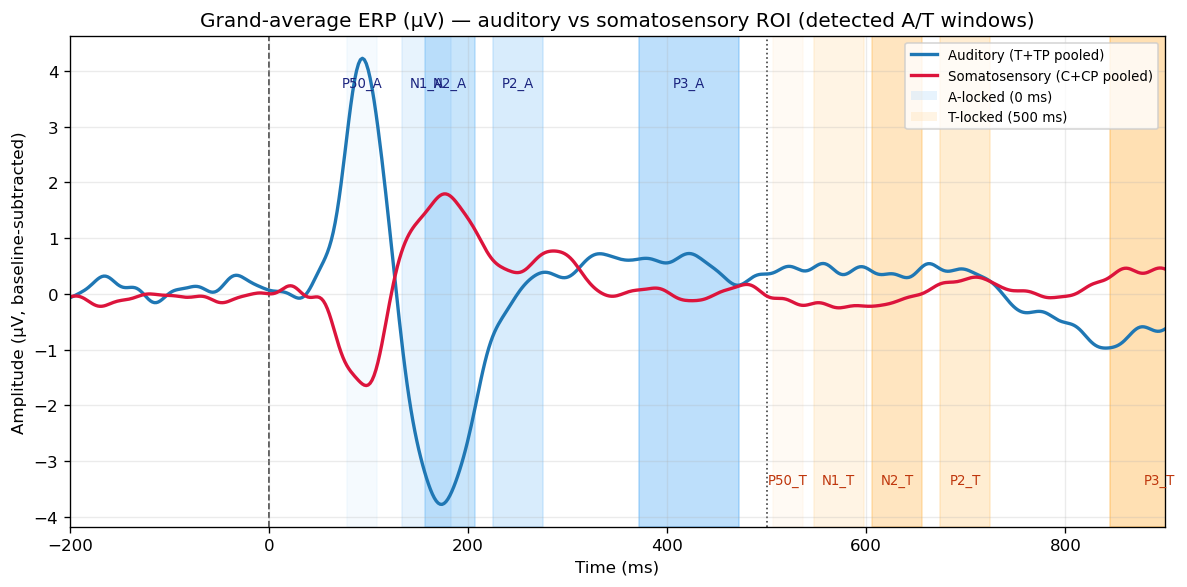

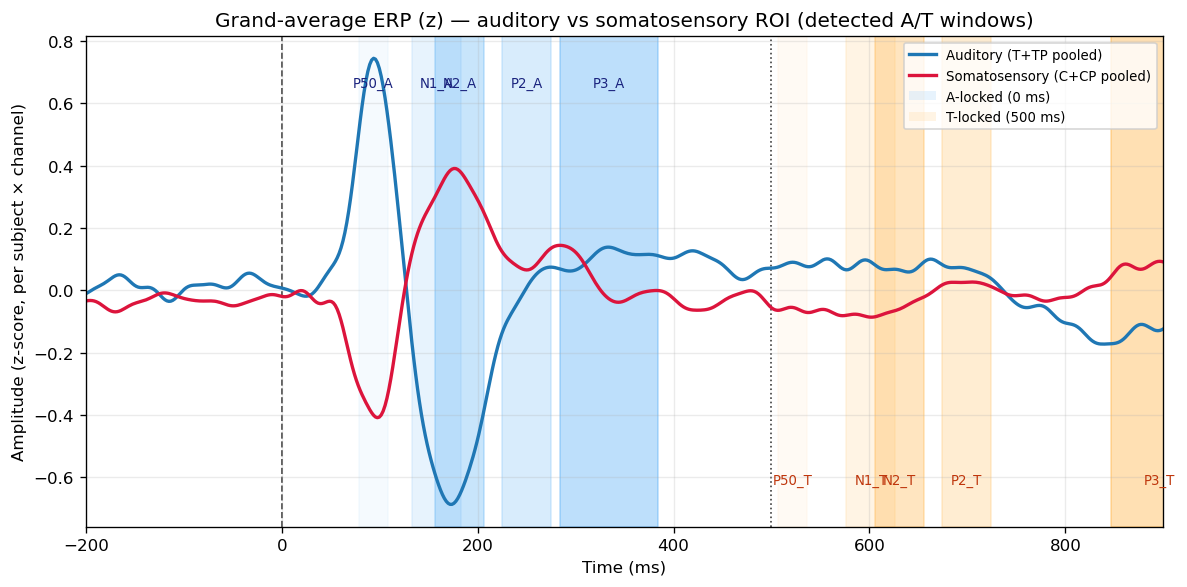

In [9]:
res_aud_bc = detect_erp_windows_from_grand_avg(
    time_ms=time_ms,
    grand_avg=grand_avg_auditory,
    search_windows=auditory_search,
    polarity_map=auditory_polarity,
    half_width_map=half_width_map,
    min_time_ms=time_ms.min(),
    max_time_ms=time_ms.max(),
)
res_aud_z = detect_erp_windows_from_grand_avg(
    time_ms=time_ms,
    grand_avg=grand_avg_auditory_z,
    search_windows=auditory_search,
    polarity_map=auditory_polarity,
    half_width_map=half_width_map,
    min_time_ms=time_ms.min(),
    max_time_ms=time_ms.max(),
)

res_tac_bc = detect_erp_windows_from_grand_avg(
    time_ms=time_ms,
    grand_avg=grand_avg_tactile,
    search_windows=tactile_search,
    polarity_map=tactile_polarity,
    half_width_map=half_width_map,
    min_time_ms=time_ms.min(),
    max_time_ms=time_ms.max(),
)
res_tac_z = detect_erp_windows_from_grand_avg(
    time_ms=time_ms,
    grand_avg=grand_avg_tactile_z,
    search_windows=tactile_search,
    polarity_map=tactile_polarity,
    half_width_map=half_width_map,
    min_time_ms=time_ms.min(),
    max_time_ms=time_ms.max(),
)

print("=== Auditory ROI (µV) — P50_A…P3_A (5 comps) ===")
print(res_aud_bc)
print("=== Auditory ROI (z) ===")
print(res_aud_z)
print("=== Somatosensory ROI (µV) — P50_T…P3_T (5 comps) ===")
print(res_tac_bc)
print("=== Somatosensory ROI (z) ===")
print(res_tac_z)
print("§4b uses these final_start_ms/final_end_ms per variant (µV vs z). §3 plots also shade these detected A/T windows when res_* are passed.")

plot_grand_avg_with_at_windows(
    time_ms=time_ms,
    grand_avg=grand_avg_auditory,
    grand_avg2=grand_avg_tactile,
    label1="Auditory (T+TP pooled)",
    label2="Somatosensory (C+CP pooled)",
    title="Grand-average ERP (µV) — auditory vs somatosensory ROI (detected A/T windows)",
    ylabel="Amplitude (µV, baseline-subtracted)",
    res_aud_df=res_aud_bc,
    res_tac_df=res_tac_bc,
)
plot_grand_avg_with_at_windows(
    time_ms=time_ms,
    grand_avg=grand_avg_auditory_z,
    grand_avg2=grand_avg_tactile_z,
    label1="Auditory (T+TP pooled)",
    label2="Somatosensory (C+CP pooled)",
    title="Grand-average ERP (z) — auditory vs somatosensory ROI (detected A/T windows)",
    ylabel="Amplitude (z-score, per subject × channel)",
    res_aud_df=res_aud_z,
    res_tac_df=res_tac_z,
)

# Alias: component-based extraction in §4a defaults to µV windows
res_aud = res_aud_bc


## 4. Feature Extraction with Two Locked Window Sets

Full feature set is in **§4b** (time + frequency + stability + anticipation). **§4a** and **§4b** use the same **BLA-style ERP detection** as `trial_dynamics_BLA 2.ipynb`: on grand-average pooled **auditory** (`grand_avg_auditory` / `_z`) and **somatosensory** (`grand_avg_tactile` / `_z`), each of **`P50_A…P3_A`** and **`P50_T…P3_T`** (five components per modality) has a **search** window (ms, absolute epoch), peak/trough polarity, then **`final_start_ms` / `final_end_ms`** from peak ± half-width. **µV** and **z-score** each use their own detected bounds. **`f_ant`** remains a **fixed** 200–500 ms window on central ROI.


In [10]:
import numpy as np
import pandas as pd


def _row_to_tmin_tmax_s(row):
    """Use final window; fall back to search window if final is NaN."""
    fs = row["final_start_ms"]
    fe = row["final_end_ms"]
    if np.isnan(fs) or np.isnan(fe):
        fs = row["search_start_ms"]
        fe = row["search_end_ms"]
    return fs / 1000.0, fe / 1000.0


def _component_extraction(res_aud_df, res_tac_df, data_key, variant_label):
    """Build component_windows from auditory + tactile detection (same as BLA peak→final window)."""
    component_windows = {}
    for comp, row in res_aud_df.iterrows():
        t0, t1 = _row_to_tmin_tmax_s(row)
        component_windows[comp] = {
            "tmin_s": t0,
            "tmax_s": t1,
            "polarity": row["polarity"],
        }
    for comp, row in res_tac_df.iterrows():
        t0, t1 = _row_to_tmin_tmax_s(row)
        component_windows[comp] = {
            "tmin_s": t0,
            "tmax_s": t1,
            "polarity": row["polarity"],
        }

    print(f"Detected windows (A+T) ({variant_label}):")
    for comp, info in component_windows.items():
        print(
            f"  {comp}: {info['tmin_s']*1000:.1f}–{info['tmax_s']*1000:.1f} ms "
            f"(polarity={info['polarity']})"
        )

    all_features_df_list = []
    all_roi_features_df_list = []

    for sub_id in SUBJECT_IDS:
        sub_pack = all_sub_data[sub_id]
        data_bc = sub_pack[data_key]
        times = sub_pack["times"]
        ch_names = sub_pack["ch_names"]

        n_trials, n_channels, _ = data_bc.shape

        window_masks = {}
        for comp, info in component_windows.items():
            mask = (times >= info["tmin_s"]) & (times <= info["tmax_s"])
            window_masks[comp] = mask

        feat_mean = {}
        for comp, mask in window_masks.items():
            feat_mean[comp] = np.nanmean(data_bc[:, :, mask], axis=-1)

        feat_peak_amp = {}
        feat_peak_lat_ms = {}

        for comp, mask in window_masks.items():
            polarity = component_windows[comp]["polarity"]
            times_win = times[mask]
            win_data = data_bc[:, :, mask]

            if polarity == "pos":
                peak_ix = np.nanargmax(win_data, axis=-1)
            elif polarity == "neg":
                peak_ix = np.nanargmin(win_data, axis=-1)
            else:
                raise ValueError(f"Unknown polarity for {comp}: {polarity}")

            peak_amp = np.take_along_axis(
                win_data,
                peak_ix[..., None],
                axis=-1
            ).squeeze(-1)

            peak_lat_ms = times_win[peak_ix] * 1000.0

            feat_peak_amp[comp] = peak_amp
            feat_peak_lat_ms[comp] = peak_lat_ms

        rows = []
        for t in range(n_trials):
            for c, ch in enumerate(ch_names):
                row = {
                    "sub_id": sub_id,
                    "trial_index": t + 1,
                    "channel": ch,
                }
                for comp in component_windows.keys():
                    row[f"{comp}_mean_amp"] = feat_mean[comp][t, c]
                    row[f"{comp}_peak_amp"] = feat_peak_amp[comp][t, c]
                    row[f"{comp}_peak_lat_ms"] = feat_peak_lat_ms[comp][t, c]
                rows.append(row)

        features_df_sub = pd.DataFrame(rows)
        all_features_df_list.append(features_df_sub)

        roi_rows = []
        for t in range(n_trials):
            row = {
                "sub_id": sub_id,
                "trial_index": t + 1,
            }
            for comp in component_windows.keys():
                row[f"{comp}_mean_amp_roi"] = np.nanmean(feat_mean[comp][t])
                row[f"{comp}_peak_amp_roi"] = np.nanmean(feat_peak_amp[comp][t])
                row[f"{comp}_peak_lat_ms_roi"] = np.nanmean(feat_peak_lat_ms[comp][t])
            roi_rows.append(row)

        roi_features_df_sub = pd.DataFrame(roi_rows)
        all_roi_features_df_list.append(roi_features_df_sub)

    erp_features_all_df = pd.concat(all_features_df_list, ignore_index=True)
    erp_roi_features_all_df = pd.concat(all_roi_features_df_list, ignore_index=True)
    return erp_features_all_df, erp_roi_features_all_df


erp_features_all_df_bc, erp_roi_features_all_df_bc = _component_extraction(
    res_aud_bc, res_tac_bc, "data_bc", "µV baseline-subtracted"
)
erp_features_all_df_z, erp_roi_features_all_df_z = _component_extraction(
    res_aud_z, res_tac_z, "data_bc_z", "z-score"
)

# Legacy names (µV) for any downstream code expecting a single table
erp_features_all_df = erp_features_all_df_bc
erp_roi_features_all_df = erp_roi_features_all_df_bc

print("Per-channel feature df (µV):")
display(erp_features_all_df_bc.head())
print("Per-channel feature df (z):")
display(erp_features_all_df_z.head())

print("ROI feature df (µV):")
display(erp_roi_features_all_df_bc.head())
print("ROI feature df (z):")
display(erp_roi_features_all_df_z.head())


Detected windows (A+T) (µV baseline-subtracted):
  P50_A: 78.8–108.8 ms (polarity=pos)
  N1_A: 133.2–183.2 ms (polarity=neg)
  P2_A: 225.0–275.0 ms (polarity=pos)
  N2_A: 156.6–206.6 ms (polarity=neg)
  P3_A: 371.9–471.9 ms (polarity=pos)
  P50_T: 506.5–536.5 ms (polarity=pos)
  N1_T: 547.3–597.3 ms (polarity=neg)
  P2_T: 674.2–724.2 ms (polarity=pos)
  N2_T: 605.9–655.9 ms (polarity=neg)
  P3_T: 844.5–944.5 ms (polarity=pos)
Detected windows (A+T) (z-score):
  P50_A: 78.8–108.8 ms (polarity=pos)
  N1_A: 133.2–183.2 ms (polarity=neg)
  P2_A: 225.0–275.0 ms (polarity=pos)
  N2_A: 156.6–206.6 ms (polarity=neg)
  P3_A: 284.0–384.0 ms (polarity=pos)
  P50_T: 506.5–536.5 ms (polarity=pos)
  N1_T: 576.6–626.6 ms (polarity=neg)
  P2_T: 674.2–724.2 ms (polarity=pos)
  N2_T: 605.9–655.9 ms (polarity=neg)
  P3_T: 846.5–946.5 ms (polarity=pos)
Per-channel feature df (µV):


,sub_id,trial_index,channel,P50_A_mean_amp,P50_A_peak_amp,P50_A_peak_lat_ms,N1_A_mean_amp,N1_A_peak_amp,N1_A_peak_lat_ms,P2_A_mean_amp,...,N1_T_peak_lat_ms,P2_T_mean_amp,P2_T_peak_amp,P2_T_peak_lat_ms,N2_T_mean_amp,N2_T_peak_amp,N2_T_peak_lat_ms,P3_T_mean_amp,P3_T_peak_amp,P3_T_peak_lat_ms
0,2,1,T7,-2.979178,-1.313169,80.078125,-8.325668,-11.326406,173.828125,-6.635444,...,548.828125,9.487013,12.961500,687.500000,4.354533,2.542885,619.140625,0.027750,2.992644,927.734375
1,2,1,TP7,-2.801683,0.168061,101.562500,-9.765039,-13.156482,177.734375,-10.198326,...,550.781250,8.869780,16.373659,693.359375,1.578065,-0.978798,625.000000,-1.835484,1.683337,916.015625
2,2,1,T8,1.324681,3.647125,99.609375,-7.759132,-12.614767,181.640625,-8.534106,...,576.171875,3.714689,8.808747,675.781250,4.960622,-3.317411,607.421875,-5.402139,1.882259,853.515625
3,2,1,TP8,4.987108,8.305860,99.609375,3.887529,-5.394705,181.640625,-4.182364,...,578.125000,1.501730,4.148132,675.781250,-0.314017,-4.457120,609.375000,-9.401708,-0.884911,849.609375
4,2,1,C3,-6.724349,-2.652638,80.078125,-5.839286,-8.624321,134.765625,-1.523859,...,558.593750,3.857757,7.959098,691.406250,-2.975247,-6.537097,654.296875,3.543352,8.156384,919.921875


Per-channel feature df (z):


,sub_id,trial_index,channel,P50_A_mean_amp,P50_A_peak_amp,P50_A_peak_lat_ms,N1_A_mean_amp,N1_A_peak_amp,N1_A_peak_lat_ms,P2_A_mean_amp,...,N1_T_peak_lat_ms,P2_T_mean_amp,P2_T_peak_amp,P2_T_peak_lat_ms,N2_T_mean_amp,N2_T_peak_amp,N2_T_peak_lat_ms,P3_T_mean_amp,P3_T_peak_amp,P3_T_peak_lat_ms
0,2,1,T7,-0.614164,-0.224627,80.078125,-1.864252,-2.565868,173.828125,-1.469053,...,585.937500,2.300614,3.113000,687.500000,1.100565,0.676975,619.140625,0.091608,0.782135,927.734375
1,2,1,TP7,-0.476926,0.089074,101.562500,-1.804065,-2.450437,177.734375,-1.886645,...,625.000000,1.747525,3.177682,693.359375,0.357805,-0.129505,625.000000,-0.271623,0.377869,916.015625
2,2,1,T8,0.208422,0.574997,99.609375,-1.225371,-1.991787,181.640625,-1.347694,...,605.468750,0.585662,1.389710,675.781250,0.782320,-0.524288,607.421875,-0.870281,0.296430,853.515625
3,2,1,TP8,0.761278,1.266973,99.609375,0.593730,-0.820651,181.640625,-0.635920,...,609.375000,0.230194,0.633439,675.781250,-0.046481,-0.677786,609.375000,-1.461534,-0.133471,849.609375
4,2,1,C3,-1.619446,-0.630727,80.078125,-1.404529,-2.080810,134.765625,-0.356630,...,623.046875,0.950169,1.946083,691.406250,-0.709065,-1.573976,654.296875,0.900426,1.993990,919.921875


ROI feature df (µV):


,sub_id,trial_index,P50_A_mean_amp_roi,P50_A_peak_amp_roi,P50_A_peak_lat_ms_roi,N1_A_mean_amp_roi,N1_A_peak_amp_roi,N1_A_peak_lat_ms_roi,P2_A_mean_amp_roi,P2_A_peak_amp_roi,...,N1_T_peak_lat_ms_roi,P2_T_mean_amp_roi,P2_T_peak_amp_roi,P2_T_peak_lat_ms_roi,N2_T_mean_amp_roi,N2_T_peak_amp_roi,N2_T_peak_lat_ms_roi,P3_T_mean_amp_roi,P3_T_peak_amp_roi,P3_T_peak_lat_ms_roi
0,2,1,-1.230572,1.591881,94.970703,-3.252839,-6.902910,168.457031,-3.885239,-0.250269,...,571.777344,1.732346,6.221782,695.312500,-1.685133,-5.623158,626.953125,-3.076005,1.420724,905.761719
1,2,2,0.528647,3.960833,94.238281,-3.724994,-7.340158,156.494141,-0.210020,2.815987,...,577.392578,-2.108196,0.771247,705.566406,-1.694310,-4.388068,628.417969,0.848958,5.060584,919.921875
2,2,3,0.221783,2.516833,93.505859,-2.129086,-6.252193,154.052734,0.399480,4.623998,...,570.312500,-0.066380,3.283772,684.570312,0.264600,-1.997935,637.451172,0.589153,3.575498,903.076172
3,2,4,1.679289,3.090456,90.820312,-1.756244,-5.280493,163.574219,0.672356,4.418231,...,577.636719,-1.261676,2.545019,686.767578,1.103575,-2.241131,629.150391,-0.260747,4.935202,894.775391
4,2,5,2.446155,4.548474,92.529297,-0.846626,-5.527945,158.203125,-0.557371,2.478130,...,582.763672,2.494065,5.539292,697.998047,1.172526,-5.100445,627.197266,1.103747,4.835006,895.751953


ROI feature df (z):


,sub_id,trial_index,P50_A_mean_amp_roi,P50_A_peak_amp_roi,P50_A_peak_lat_ms_roi,N1_A_mean_amp_roi,N1_A_peak_amp_roi,N1_A_peak_lat_ms_roi,P2_A_mean_amp_roi,P2_A_peak_amp_roi,...,N1_T_peak_lat_ms_roi,P2_T_mean_amp_roi,P2_T_peak_amp_roi,P2_T_peak_lat_ms_roi,N2_T_mean_amp_roi,N2_T_peak_amp_roi,N2_T_peak_lat_ms_roi,P3_T_mean_amp_roi,P3_T_peak_amp_roi,P3_T_peak_lat_ms_roi
0,2,1,-0.344099,0.224942,94.970703,-0.705125,-1.383482,168.457031,-0.757751,-0.004690,...,609.863281,0.356559,1.270870,695.312500,-0.397553,-1.160931,626.953125,-0.517978,0.340907,906.005859
1,2,2,-0.110367,0.568962,94.238281,-0.789139,-1.539890,156.494141,-0.134520,0.488114,...,593.017578,-0.446446,0.123714,705.566406,-0.349184,-0.900101,628.417969,0.180239,0.975204,920.410156
2,2,3,0.113235,0.558977,93.505859,-0.251158,-1.121637,154.052734,0.098571,0.919131,...,601.806641,-0.064903,0.592150,684.570312,0.086881,-0.352850,637.451172,0.165936,0.781561,913.574219
3,2,4,0.317180,0.603050,90.820312,-0.388032,-1.149845,163.574219,0.095591,0.872996,...,599.365234,-0.286396,0.502876,686.767578,0.191249,-0.466012,629.150391,-0.010873,1.026622,897.949219
4,2,5,0.355024,0.787953,92.529297,-0.157355,-1.113268,158.203125,-0.170031,0.449791,...,599.121094,0.396988,1.012440,697.998047,0.210907,-1.066743,627.197266,0.149474,0.879089,895.751953


### 4b. Time / frequency / stability / anticipation (proposal §5.1–5.3 + H3)

The next cell builds **`erp_features_all_df_{bc,z}`** (per channel) and **`erp_roi_features_all_df_{bc,z}`** (trial-level ROI summaries):

**Time (11 windows × 3 = 33 metrics per channel):** `P50_A…P3_A`, `P50_T…P3_T` (**§3 detection**), and **`f_ant` (200–500 ms, fixed)** on **central (C3,C4,CP1,CP2)**. For each: **mean amplitude**, **peak amplitude**, **peak latency**; polarities from §3 for A/T, positive peak for `f_ant`.

**Frequency (Welch, dB vs baseline −500…−50 ms):** θ/α/β band power change in **A 0–400 ms** (auditory ROI), **ANT 200–500 ms** (central ROI), **T 500–900 ms** (somato ROI) — proposal §5.2.

**Stability (µV ERP, 0–900 ms):** per subregion **T, TP, C, CP** — Pearson **r** to trial-mean template and **Euclidean** distance to previous trial — proposal §5.3.

Rolling in §5 uses the list **`ROLLING_VALUE_COLS`** (time + freq + stab).

In [11]:
import numpy as np
import pandas as pd
from scipy.signal import welch

# NumPy 2.0 removed np.trapz; NumPy 2.0+ uses np.trapezoid
_np_trapz = getattr(np, "trapezoid", None) or getattr(np, "trapz", None)

# --- Time windows: A/T from grand-average detection (§3, same as BLA); anticipation fixed (CISI H3) ---
AUDITORY_COMPS = ["P50_A", "N1_A", "P2_A", "N2_A", "P3_A"]
TACTILE_COMPS = ["P50_T", "N1_T", "P2_T", "N2_T", "P3_T"]
AT_FEATURES = AUDITORY_COMPS + TACTILE_COMPS
ANT_WINDOWS = {
    "f_ant": (0.300, 0.500),
}


def _build_at_windows_from_detection(res_aud_df, res_tac_df):
    """final_start_ms/final_end_ms from detect_erp_windows_from_grand_avg; fallback to search window."""
    fw = {}
    pol = {}
    for df in (res_aud_df, res_tac_df):
        for comp, row in df.iterrows():
            fs = float(row["final_start_ms"])
            fe = float(row["final_end_ms"])
            if np.isnan(fs) or np.isnan(fe):
                fs = float(row["search_start_ms"])
                fe = float(row["search_end_ms"])
            fw[comp] = (fs / 1000.0, fe / 1000.0)
            pol[comp] = row["polarity"]
    for k, (a, b) in ANT_WINDOWS.items():
        fw[k] = (a, b)
        pol[k] = "pos"
    return fw, pol

AUDITORY_ROI = ["T7", "T8", "TP7", "TP8"]
SOMATO_ROI = ["C3", "C4", "CP1", "CP2"]
ANT_ROI = ["C3", "C4", "CP1", "CP2"]

REGIONS_STAB = {
    "T": ["T7", "T8"],
    "TP": ["TP7", "TP8"],
    "C": ["C3", "C4"],
    "CP": ["CP1", "CP2"],
}

feature_order = list(AT_FEATURES) + list(ANT_WINDOWS.keys())

TIME_SUFFIXES = ("mean_amp", "peak_amp", "peak_lat_ms")

BASELINE_TMIN, BASELINE_TMAX = -0.500, -0.050

BANDS = {"theta": (4.0, 8.0), "alpha": (8.0, 13.0), "beta": (13.0, 30.0)}

FREQ_WINDOWS = {
    "A0_400": ((0.0, 0.4), "auditory", AUDITORY_ROI),
    "ANT200_500": ((0.2, 0.5), "central", ANT_ROI),
    "T500_900": ((0.5, 0.9), "somato", SOMATO_ROI),
}

FREQ_FEATURE_COLS = []
for win_name in FREQ_WINDOWS:
    for band in BANDS:
        FREQ_FEATURE_COLS.append(f"freq_{win_name}_{band}_db")

STAB_FEATURE_COLS = []
for r in REGIONS_STAB:
    STAB_FEATURE_COLS.append(f"stab_sim_{r}")
    STAB_FEATURE_COLS.append(f"stab_dist_{r}")


def _band_power(freqs, psd, f_lo, f_hi):
    m = (freqs >= f_lo) & (freqs < f_hi)
    if not np.any(m):
        return np.nan
    return float(_np_trapz(psd[m], freqs[m]))


def _welch_psd_1d(x, sfreq):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 8:
        return None, None
    nperseg = min(256, max(8, n // 2))
    return welch(x, fs=sfreq, nperseg=nperseg, noverlap=nperseg // 2)


def _db_ratio(post_bp, base_bp, eps=1e-20):
    return 10.0 * np.log10((post_bp + eps) / (base_bp + eps))


def _roi_freq_features(data_uV, times, sfreq, baseline_mask, roi_idx, t0, t1):
    post_mask = (times >= t0) & (times <= t1)
    n_trials = data_uV.shape[0]
    out = {f"{band}_db": np.full(n_trials, np.nan) for band in BANDS}
    if not roi_idx or post_mask.sum() < 8 or baseline_mask.sum() < 8:
        return out

    base_seg = data_uV[:, roi_idx, :][:, :, baseline_mask].mean(axis=1)
    post_seg = data_uV[:, roi_idx, :][:, :, post_mask].mean(axis=1)

    for t in range(n_trials):
        fb, pb = _welch_psd_1d(base_seg[t], sfreq)
        fp, pp = _welch_psd_1d(post_seg[t], sfreq)
        if fb is None or fp is None:
            continue
        for bname, (lo, hi) in BANDS.items():
            bb = _band_power(fb, pb, lo, hi)
            bp = _band_power(fp, pp, lo, hi)
            out[f"{bname}_db"][t] = _db_ratio(bp, bb)
    return out


def _stability_one_region(data_uV, times, roi_idx, t0=0.0, t1=0.9):
    n_trials = data_uV.shape[0]
    sim = np.full(n_trials, np.nan)
    dist = np.full(n_trials, np.nan)
    if not roi_idx:
        return sim, dist
    m = (times >= t0) & (times <= t1)
    if m.sum() < 2:
        return sim, dist
    X = data_uV[:, roi_idx, :][:, :, m].mean(axis=1)
    tpl = np.nanmean(X, axis=0)
    for t in range(n_trials):
        a, b = X[t], tpl
        if np.nanstd(a) < 1e-15 or np.nanstd(b) < 1e-15:
            continue
        sim[t] = np.corrcoef(a, b)[0, 1]
    for t in range(1, n_trials):
        dist[t] = np.linalg.norm(X[t] - X[t - 1])
    return sim, dist


def _extract_all_features(data_key):
    if data_key == "data_bc":
        res_aud_use, res_tac_use = res_aud_bc, res_tac_bc
    elif data_key == "data_bc_z":
        res_aud_use, res_tac_use = res_aud_z, res_tac_z
    else:
        raise ValueError(f"Unknown data_key: {data_key}")

    feature_windows, polarity_for_feat = _build_at_windows_from_detection(
        res_aud_use, res_tac_use
    )

    all_features_df_list = []
    all_roi_features_df_list = []

    for sub_id in SUBJECT_IDS:
        sub_pack = all_sub_data[sub_id]
        data_arr = sub_pack[data_key]
        data_uV = sub_pack["data_bc"]
        times = sub_pack["times"]
        ch_names = sub_pack["ch_names"]
        sfreq = float(sub_pack["sfreq"])

        n_trials, n_channels, _ = data_arr.shape

        baseline_mask = (times >= BASELINE_TMIN) & (times <= BASELINE_TMAX)

        window_masks = {}
        for feat, (tmin_s, tmax_s) in feature_windows.items():
            mask = (times >= tmin_s) & (times <= tmax_s)
            if mask.sum() == 0:
                raise ValueError(f"No samples for {feat} in [{tmin_s}, {tmax_s}] s")
            window_masks[feat] = mask

        feat_mean = {}
        feat_peak_amp = {}
        feat_peak_lat_ms = {}
        for feat, mask in window_masks.items():
            feat_mean[feat] = np.nanmean(data_arr[:, :, mask], axis=-1)
            polarity = polarity_for_feat[feat]
            times_win = times[mask]
            win_data = data_arr[:, :, mask]
            if polarity == "pos":
                peak_ix = np.nanargmax(win_data, axis=-1)
            else:
                peak_ix = np.nanargmin(win_data, axis=-1)
            peak_amp = np.take_along_axis(win_data, peak_ix[..., None], axis=-1).squeeze(-1)
            peak_lat_ms = times_win[peak_ix] * 1000.0
            feat_peak_amp[feat] = peak_amp
            feat_peak_lat_ms[feat] = peak_lat_ms

        ch_to_idx = {ch: i for i, ch in enumerate(ch_names)}
        aud_idx = [ch_to_idx[ch] for ch in AUDITORY_ROI if ch in ch_to_idx]
        som_idx = [ch_to_idx[ch] for ch in SOMATO_ROI if ch in ch_to_idx]
        ant_idx = [ch_to_idx[ch] for ch in ANT_ROI if ch in ch_to_idx]
        reg_idx = {r: [ch_to_idx[c] for c in chs if c in ch_to_idx] for r, chs in REGIONS_STAB.items()}

        def _idx_for_feat(feat):
            if feat.endswith("_A"):
                return aud_idx
            if feat.endswith("_T"):
                return som_idx
            if feat == "f_ant":
                return ant_idx
            return aud_idx

        freq_by_win = {}
        for win_name, ((t0, t1), _label, roi_list) in FREQ_WINDOWS.items():
            roi_ix = [ch_to_idx[c] for c in roi_list if c in ch_to_idx]
            freq_by_win[win_name] = _roi_freq_features(
                data_uV, times, sfreq, baseline_mask, roi_ix, t0, t1
            )

        stab = {}
        for rname, ix in reg_idx.items():
            stab[rname] = _stability_one_region(data_uV, times, ix)

        rows = []
        for t in range(n_trials):
            for c, ch in enumerate(ch_names):
                row = {
                    "sub_id": sub_id,
                    "trial_index": t + 1,
                    "channel": ch,
                }
                for feat in feature_order:
                    row[f"{feat}_mean_amp"] = feat_mean[feat][t, c]
                    row[f"{feat}_peak_amp"] = feat_peak_amp[feat][t, c]
                    row[f"{feat}_peak_lat_ms"] = feat_peak_lat_ms[feat][t, c]

                for win_name, ((t0, t1), _lab, roi_list) in FREQ_WINDOWS.items():
                    roi_ix = [ch_to_idx[c] for c in roi_list if c in ch_to_idx]
                    if not roi_ix or ch not in roi_list:
                        for band in BANDS:
                            row[f"freq_{win_name}_{band}_db"] = np.nan
                    else:
                        for band in BANDS:
                            row[f"freq_{win_name}_{band}_db"] = freq_by_win[win_name][f"{band}_db"][t]

                for rname, ix in reg_idx.items():
                    if ch in [ch_names[i] for i in ix]:
                        sim, dist = stab[rname]
                        row[f"stab_sim_{rname}"] = sim[t]
                        row[f"stab_dist_{rname}"] = dist[t]
                    else:
                        row[f"stab_sim_{rname}"] = np.nan
                        row[f"stab_dist_{rname}"] = np.nan

                rows.append(row)

        features_df_sub = pd.DataFrame(rows)
        all_features_df_list.append(features_df_sub)

        roi_rows = []
        for t in range(n_trials):
            row = {
                "sub_id": sub_id,
                "trial_index": t + 1,
            }
            for feat in feature_order:
                idx = _idx_for_feat(feat)
                if len(idx) == 0:
                    row[f"{feat}_mean_amp_roi"] = np.nan
                    row[f"{feat}_peak_amp_roi"] = np.nan
                    row[f"{feat}_peak_lat_ms_roi"] = np.nan
                else:
                    row[f"{feat}_mean_amp_roi"] = np.nanmean(feat_mean[feat][t, idx])
                    row[f"{feat}_peak_amp_roi"] = np.nanmean(feat_peak_amp[feat][t, idx])
                    row[f"{feat}_peak_lat_ms_roi"] = np.nanmean(feat_peak_lat_ms[feat][t, idx])

            for win_name in FREQ_WINDOWS:
                roi_list = FREQ_WINDOWS[win_name][2]
                roi_ix = [ch_to_idx[c] for c in roi_list if c in ch_to_idx]
                if not roi_ix:
                    for band in BANDS:
                        row[f"freq_{win_name}_{band}_db"] = np.nan
                else:
                    for band in BANDS:
                        row[f"freq_{win_name}_{band}_db"] = freq_by_win[win_name][f"{band}_db"][t]

            for rname in REGIONS_STAB:
                sim, dist = stab[rname]
                row[f"stab_sim_{rname}"] = sim[t]
                row[f"stab_dist_{rname}"] = dist[t]

            roi_rows.append(row)

        roi_features_df_sub = pd.DataFrame(roi_rows)
        all_roi_features_df_list.append(roi_features_df_sub)

    return pd.concat(all_features_df_list, ignore_index=True), pd.concat(
        all_roi_features_df_list, ignore_index=True
    )


erp_features_all_df_bc, erp_roi_features_all_df_bc = _extract_all_features("data_bc")
erp_features_all_df_z, erp_roi_features_all_df_z = _extract_all_features("data_bc_z")

erp_features_all_df = erp_features_all_df_bc
erp_roi_features_all_df = erp_roi_features_all_df_bc

ROLLING_VALUE_COLS = (
    [f"{feat}_{s}" for feat in feature_order for s in TIME_SUFFIXES]
    + FREQ_FEATURE_COLS
    + STAB_FEATURE_COLS
)

print("Feature order (P50_A…P3_A & P50_T…P3_T from §3 detection; f_ant fixed):", feature_order)
print("Per-channel time features:", len(feature_order) * len(TIME_SUFFIXES))
print("ROLLING_VALUE_COLS length:", len(ROLLING_VALUE_COLS))

print("Per-channel feature df (µV):")
display(erp_features_all_df_bc.head())
print("Per-channel feature df (z):")
display(erp_features_all_df_z.head())
print("ROI feature df (µV):")
display(erp_roi_features_all_df_bc.head())
print("ROI feature df (z):")
display(erp_roi_features_all_df_z.head())


Feature order (P50_A…P3_A & P50_T…P3_T from §3 detection; f_ant fixed): ['P50_A', 'N1_A', 'P2_A', 'N2_A', 'P3_A', 'P50_T', 'N1_T', 'P2_T', 'N2_T', 'P3_T', 'f_ant']
Per-channel time features: 33
ROLLING_VALUE_COLS length: 50
Per-channel feature df (µV):


,sub_id,trial_index,channel,P50_A_mean_amp,P50_A_peak_amp,P50_A_peak_lat_ms,N1_A_mean_amp,N1_A_peak_amp,N1_A_peak_lat_ms,P2_A_mean_amp,...,freq_T500_900_alpha_db,freq_T500_900_beta_db,stab_sim_T,stab_dist_T,stab_sim_TP,stab_dist_TP,stab_sim_C,stab_dist_C,stab_sim_CP,stab_dist_CP
0,2,1,T7,-2.979178,-1.313169,80.078125,-8.325668,-11.326406,173.828125,-6.635444,...,NaN,NaN,0.427495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,TP7,-2.801683,0.168061,101.562500,-9.765039,-13.156482,177.734375,-10.198326,...,NaN,NaN,NaN,NaN,0.391981,NaN,NaN,NaN,NaN,NaN
2,2,1,T8,1.324681,3.647125,99.609375,-7.759132,-12.614767,181.640625,-8.534106,...,NaN,NaN,0.427495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,1,TP8,4.987108,8.305860,99.609375,3.887529,-5.394705,181.640625,-4.182364,...,NaN,NaN,NaN,NaN,0.391981,NaN,NaN,NaN,NaN,NaN
4,2,1,C3,-6.724349,-2.652638,80.078125,-5.839286,-8.624321,134.765625,-1.523859,...,0.0,2.203521,NaN,NaN,NaN,NaN,0.301193,NaN,NaN,NaN


Per-channel feature df (z):


,sub_id,trial_index,channel,P50_A_mean_amp,P50_A_peak_amp,P50_A_peak_lat_ms,N1_A_mean_amp,N1_A_peak_amp,N1_A_peak_lat_ms,P2_A_mean_amp,...,freq_T500_900_alpha_db,freq_T500_900_beta_db,stab_sim_T,stab_dist_T,stab_sim_TP,stab_dist_TP,stab_sim_C,stab_dist_C,stab_sim_CP,stab_dist_CP
0,2,1,T7,-0.614164,-0.224627,80.078125,-1.864252,-2.565868,173.828125,-1.469053,...,NaN,NaN,0.427495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,TP7,-0.476926,0.089074,101.562500,-1.804065,-2.450437,177.734375,-1.886645,...,NaN,NaN,NaN,NaN,0.391981,NaN,NaN,NaN,NaN,NaN
2,2,1,T8,0.208422,0.574997,99.609375,-1.225371,-1.991787,181.640625,-1.347694,...,NaN,NaN,0.427495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,1,TP8,0.761278,1.266973,99.609375,0.593730,-0.820651,181.640625,-0.635920,...,NaN,NaN,NaN,NaN,0.391981,NaN,NaN,NaN,NaN,NaN
4,2,1,C3,-1.619446,-0.630727,80.078125,-1.404529,-2.080810,134.765625,-0.356630,...,0.0,2.203521,NaN,NaN,NaN,NaN,0.301193,NaN,NaN,NaN


ROI feature df (µV):


,sub_id,trial_index,P50_A_mean_amp_roi,P50_A_peak_amp_roi,P50_A_peak_lat_ms_roi,N1_A_mean_amp_roi,N1_A_peak_amp_roi,N1_A_peak_lat_ms_roi,P2_A_mean_amp_roi,P2_A_peak_amp_roi,...,freq_T500_900_alpha_db,freq_T500_900_beta_db,stab_sim_T,stab_dist_T,stab_sim_TP,stab_dist_TP,stab_sim_C,stab_dist_C,stab_sim_CP,stab_dist_CP
0,2,1,0.132732,2.701969,95.214844,-5.490577,-10.623090,178.710938,-7.387560,-4.417878,...,0.0,2.203521,0.427495,NaN,0.391981,NaN,0.301193,NaN,0.491981,NaN
1,2,2,3.124217,6.973227,93.750000,-3.419609,-7.258321,158.203125,1.482784,4.019606,...,0.0,-2.360626,0.559296,114.650236,0.425018,123.456660,0.296175,82.346900,0.334690,69.695743
2,2,3,-2.709143,-0.820716,84.960938,-8.637138,-10.993396,154.296875,-0.298647,5.028058,...,0.0,-7.877335,0.481725,82.103669,0.616928,118.043437,0.248934,111.247756,-0.024583,100.270981
3,2,4,3.024960,4.094244,90.820312,-0.779727,-3.874074,170.898438,3.896248,6.151755,...,0.0,0.643272,0.262454,91.247420,0.491864,105.377935,-0.131110,69.364699,0.316361,99.592012
4,2,5,2.357929,4.069644,83.007812,-3.165483,-7.460120,172.851562,-1.488502,2.073639,...,0.0,4.815052,0.249216,71.216218,0.522697,98.075484,0.363626,59.473763,0.213912,83.623624


ROI feature df (z):


,sub_id,trial_index,P50_A_mean_amp_roi,P50_A_peak_amp_roi,P50_A_peak_lat_ms_roi,N1_A_mean_amp_roi,N1_A_peak_amp_roi,N1_A_peak_lat_ms_roi,P2_A_mean_amp_roi,P2_A_peak_amp_roi,...,freq_T500_900_alpha_db,freq_T500_900_beta_db,stab_sim_T,stab_dist_T,stab_sim_TP,stab_dist_TP,stab_sim_C,stab_dist_C,stab_sim_CP,stab_dist_CP
0,2,1,-0.030348,0.426604,95.214844,-1.074990,-1.957186,178.710938,-1.334828,-0.776254,...,0.0,2.203521,0.427495,NaN,0.391981,NaN,0.301193,NaN,0.491981,NaN
1,2,2,0.431136,1.125181,93.750000,-0.586366,-1.293919,158.203125,0.248686,0.702191,...,0.0,-2.360626,0.559296,114.650236,0.425018,123.456660,0.296175,82.346900,0.334690,69.695743
2,2,3,-0.411677,-0.090024,84.960938,-1.488519,-1.894906,154.296875,-0.026244,0.899942,...,0.0,-7.877335,0.481725,82.103669,0.616928,118.043437,0.248934,111.247756,-0.024583,100.270981
3,2,4,0.587262,0.780185,90.820312,-0.129259,-0.755340,170.898438,0.757532,1.169841,...,0.0,0.643272,0.262454,91.247420,0.491864,105.377935,-0.131110,69.364699,0.316361,99.592012
4,2,5,0.298189,0.611779,83.007812,-0.615841,-1.388093,172.851562,-0.346141,0.333307,...,0.0,4.815052,0.249216,71.216218,0.522697,98.075484,0.363626,59.473763,0.213912,83.623624


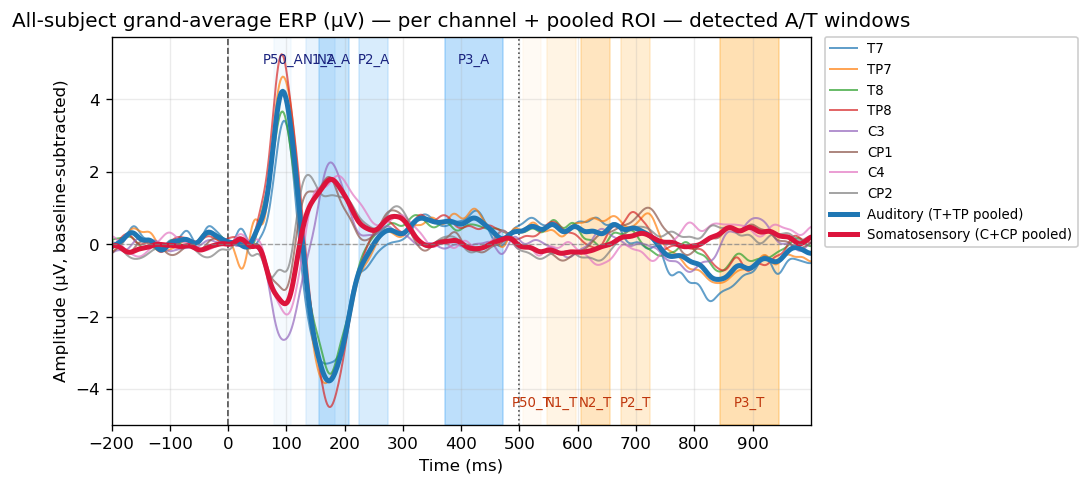

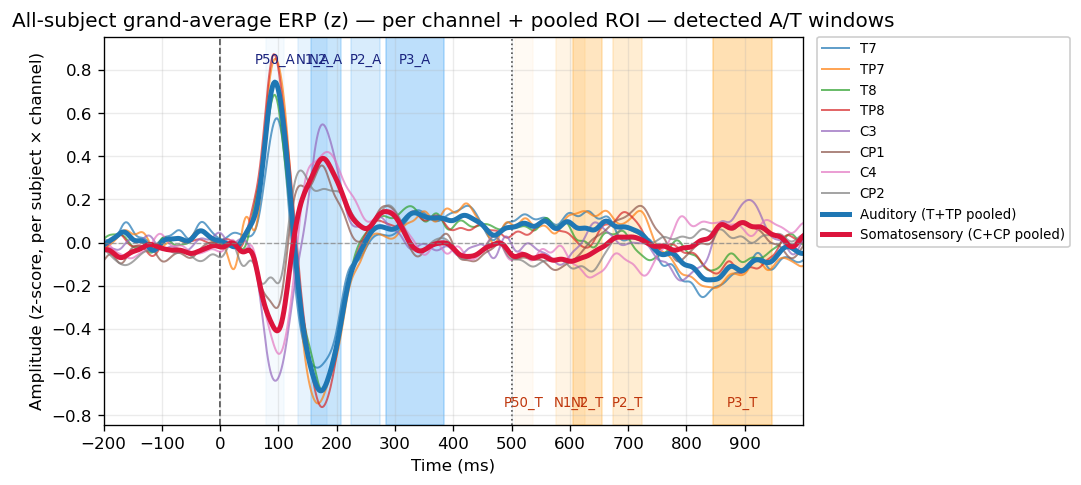

In [12]:
for g_ch, g_aud, g_tac, ylab, unit_tag, res_a, res_t in [
    (
        grand_avg_by_channel,
        grand_avg_auditory,
        grand_avg_tactile,
        "Amplitude (µV, baseline-subtracted)",
        "µV",
        res_aud_bc,
        res_tac_bc,
    ),
    (
        grand_avg_by_channel_z,
        grand_avg_auditory_z,
        grand_avg_tactile_z,
        "Amplitude (z-score, per subject × channel)",
        "z",
        res_aud_z,
        res_tac_z,
    ),
]:
    # Wider figure so legend can sit outside the axes (not over the data)
    fig, ax = plt.subplots(figsize=(10.5, 4.2))

    for c, ch in enumerate(ch_names):
        ax.plot(
            time_ms,
            g_ch[c],
            linewidth=1.2,
            alpha=0.7,
            label=ch,
        )

    ax.plot(
        time_ms,
        g_aud,
        color="#1f77b4",
        linewidth=3,
        label="Auditory (T+TP pooled)",
    )
    ax.plot(
        time_ms,
        g_tac,
        color="crimson",
        linewidth=3,
        label="Somatosensory (C+CP pooled)",
    )

    y_stack = np.concatenate([g_ch.ravel(), g_aud, g_tac])
    y_min = float(np.nanmin(y_stack))
    y_max = float(np.nanmax(y_stack))
    pad = 0.05 * (y_max - y_min if y_max > y_min else 1.0)
    shade_a_t_erp_windows(
        ax,
        y_min=y_min - pad,
        y_max=y_max + pad,
        res_aud_df=res_a,
        res_tac_df=res_t,
    )

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

    ax.set_title(
        f"All-subject grand-average ERP ({unit_tag}) — per channel + pooled ROI — detected A/T windows"
    )
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel(ylab)
    ax.set_xlim(-200, 1000)
    ax.set_xticks(np.arange(-200, 1000, 100))
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.grid(True, alpha=0.25)
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
        fontsize=8,
        framealpha=0.95,
    )
    fig.subplots_adjust(right=0.68)
    plt.show()


## 5. Trial-by-Trial Dynamics

Plot each feature against trial index and overlay a rolling mean to reveal learning-related trends.

In [13]:
# ROLLING_WINDOW = 10

# for sub_id in SUBJECT_IDS:
#     roi_features_df = erp_roi_features_all_df.query("sub_id == @sub_id").copy()
#     trial_idx = roi_features_df["trial_index"].values

#     windows = []
#     for comp in component_windows.keys():
#         windows.append((
#             f"{comp} mean amp",
#             roi_features_df[f"{comp}_mean_amp_roi"].values,
#             "royalblue",
#             "Mean amplitude (a.u.)"
#         ))
#         windows.append((
#             f"{comp} peak amp",
#             roi_features_df[f"{comp}_peak_amp_roi"].values,
#             "purple",
#             "Peak amplitude (a.u.)"
#         ))
#         windows.append((
#             f"{comp} peak latency",
#             roi_features_df[f"{comp}_peak_lat_ms_roi"].values,
#             "brown",
#             "Latency (ms)"
#         ))

#     n_plots = len(windows)
#     fig, axes = plt.subplots(n_plots, 1, figsize=(12, 3*n_plots), sharex=True)

#     if n_plots == 1:
#         axes = [axes]

#     for ax, (label, values, color, ylab) in zip(axes, windows):
#         ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label="Trial value")
#         ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

#         rolling = pd.Series(values).rolling(
#             window=ROLLING_WINDOW,
#             center=True,
#             min_periods=1
#         ).mean()

#         ax.plot(
#             trial_idx,
#             rolling,
#             color=color,
#             linewidth=2.5,
#             zorder=3,
#             label=f"Rolling mean (w={ROLLING_WINDOW})"
#         )

#         if "latency" not in label.lower():
#             ax.axhline(0, color="gray", linewidth=0.6, linestyle="--", alpha=0.6)

#         ax.set_ylabel(ylab, fontsize=10)
#         ax.set_title(f"Subject {sub_id} — ROI average — {label}", fontsize=10, fontweight="bold")
#         ax.legend(loc="upper right", fontsize=8)
#         ax.grid(True, alpha=0.25)

#     axes[-1].set_xlabel("Trial index", fontsize=11)

#     fig.suptitle(
#         f"{CONDITION} Protocol — Subject {sub_id}\nTrial-by-Trial Neural Dynamics",
#         fontsize=12,
#         fontweight="bold"
#     )

#     fig.tight_layout()
#     plt.show()

In [14]:
import pandas as pd

ROLLING_WINDOW = 5

REGIONS_DICT = {
    'BLA': {
        'T':  ['T7', 'T8'],
        'TP': ['TP7', 'TP8'],
    },

    'BLT': {
        'C':  ['C3', 'C4'],
        'CP': ['CP1', 'CP2'],
    },

    'CISI': {
        'T':  ['T7', 'T8'],
        'TP': ['TP7', 'TP8'],
        'C':  ['C3', 'C4'],
        'CP': ['CP1', 'CP2'],
    },

    'VISI': {
        'C':  ['C3', 'C4'],
        'CP': ['CP1', 'CP2'],
        'F':  ['F3', 'F4'],
        'FC': ['FC1', 'FC2', 'FC5', 'FC6'],
    },

    'RS': {
        'C':  ['C3', 'C4'],
        'CP': ['CP1', 'CP2'],
        'P':  ['P1', 'P2', 'P5', 'P6'],
    },
}


regions_of_interest = REGIONS_DICT.get(CHANNELS, {})
if len(regions_of_interest) == 0:
    raise ValueError(f"No regions found for CHANNELS={CHANNELS}")

print(f"CONDITION = {CHANNELS}")
print("Subregions:", list(regions_of_interest.keys()))


try:
    feature_cols = ROLLING_VALUE_COLS
except NameError as e:
    raise RuntimeError("Run §4b (cell 16) first — need ROLLING_VALUE_COLS from feature extraction.") from e

for _df, _name in [
    (erp_features_all_df_bc, "erp_features_all_df_bc"),
    (erp_features_all_df_z, "erp_features_all_df_z"),
]:
    missing_cols = [col for col in feature_cols if col not in _df.columns]
    if len(missing_cols) > 0:
        raise ValueError(
            f"Missing feature columns in {_name} (showing first 15): {missing_cols[:15]}"
        )


rolling_by_tag = {}

for tag, erp_features_all_df in [
    ("bc", erp_features_all_df_bc),
    ("z", erp_features_all_df_z),
]:
    print(f"\n######## Rolling pipeline ({tag}) ########")

    all_region_group_roll_df = []
    all_region_subject_roll_df = []
    all_region_subject_feature_df = []

    for region_name, roi_channels in regions_of_interest.items():
        print(f"\nProcessing region = {region_name}, channels = {roi_channels}")

        df_roi = erp_features_all_df[
            erp_features_all_df["channel"].isin(roi_channels)
        ].copy()

        if len(df_roi) == 0:
            print(f"  Skipped: no data found for region {region_name}")
            continue

        agg_dict = {col: "mean" for col in feature_cols}

        erp_region_features_df = (
            df_roi
            .groupby(["sub_id", "trial_index"], observed=True, as_index=False)
            .agg(agg_dict)
            .sort_values(["sub_id", "trial_index"])
            .reset_index(drop=True)
        )

        erp_region_features_df["condition"] = CHANNELS
        erp_region_features_df["region"] = region_name

        all_region_subject_feature_df.append(erp_region_features_df)

        region_roll_list = []

        for sub_id in erp_region_features_df["sub_id"].unique():
            df_sub = erp_region_features_df.query("sub_id == @sub_id").copy()
            if len(df_sub) == 0:
                continue

            df_sub = df_sub.sort_values("trial_index").reset_index(drop=True)

            for col in feature_cols:
                roll_col = f"{col}_roll"
                df_sub[roll_col] = df_sub[col].rolling(
                    window=ROLLING_WINDOW,
                    center=True,
                    min_periods=1
                ).mean()

            df_sub["condition"] = CHANNELS
            df_sub["region"] = region_name

            region_roll_list.append(df_sub)

        if len(region_roll_list) == 0:
            print(f"  Skipped: no rolling result for region {region_name}")
            continue

        erp_region_roll_df = pd.concat(region_roll_list, ignore_index=True)
        all_region_subject_roll_df.append(erp_region_roll_df)

        group_rows = []

        for trial_index, df_trial in erp_region_roll_df.groupby("trial_index", observed=True):
            row = {
                "trial_index": trial_index,
                "condition": CHANNELS,
                "region": region_name,
            }

            for col in feature_cols:
                roll_col = f"{col}_roll"
                row[f"{roll_col}_mean"] = df_trial[roll_col].mean()
                row[f"{roll_col}_sem"] = df_trial[roll_col].sem()

            group_rows.append(row)

        erp_region_group_roll_df = (
            pd.DataFrame(group_rows)
            .sort_values("trial_index")
            .reset_index(drop=True)
        )

        all_region_group_roll_df.append(erp_region_group_roll_df)

    if len(all_region_subject_feature_df) > 0:
        erp_roi_features_df = pd.concat(all_region_subject_feature_df, ignore_index=True)
    else:
        erp_roi_features_df = pd.DataFrame()

    if len(all_region_subject_roll_df) > 0:
        erp_roi_roll_df = pd.concat(all_region_subject_roll_df, ignore_index=True)
    else:
        erp_roi_roll_df = pd.DataFrame()

    if len(all_region_group_roll_df) > 0:
        erp_roi_group_roll_df = pd.concat(all_region_group_roll_df, ignore_index=True)
        erp_roi_group_roll_df = erp_roi_group_roll_df.sort_values(
            ["region", "trial_index"]
        ).reset_index(drop=True)
    else:
        erp_roi_group_roll_df = pd.DataFrame()

    rolling_by_tag[tag] = {
        "erp_roi_features_df": erp_roi_features_df,
        "erp_roi_roll_df": erp_roi_roll_df,
        "erp_roi_group_roll_df": erp_roi_group_roll_df,
    }


erp_roi_features_df_bc = rolling_by_tag["bc"]["erp_roi_features_df"]
erp_roi_roll_df_bc = rolling_by_tag["bc"]["erp_roi_roll_df"]
erp_roi_group_roll_df_bc = rolling_by_tag["bc"]["erp_roi_group_roll_df"]

erp_roi_features_df_z = rolling_by_tag["z"]["erp_roi_features_df"]
erp_roi_roll_df_z = rolling_by_tag["z"]["erp_roi_roll_df"]
erp_roi_group_roll_df_z = rolling_by_tag["z"]["erp_roi_group_roll_df"]

erp_roi_features_df = erp_roi_features_df_bc
erp_roi_roll_df = erp_roi_roll_df_bc
erp_roi_group_roll_df = erp_roi_group_roll_df_bc


for tag, lab in [("bc", "µV baseline-subtracted"), ("z", "z-score")]:
    print(f"\n[{lab}] Per-subject region-aggregated features")
    display(rolling_by_tag[tag]["erp_roi_features_df"].head())

    print(f"\n[{lab}] Per-subject rolling features")
    display(rolling_by_tag[tag]["erp_roi_roll_df"].head())

    print(f"\n[{lab}] Grand average rolling features")
    display(rolling_by_tag[tag]["erp_roi_group_roll_df"].head())


CONDITION = CISI
Subregions: ['T', 'TP', 'C', 'CP']

######## Rolling pipeline (bc) ########

Processing region = T, channels = ['T7', 'T8']

Processing region = TP, channels = ['TP7', 'TP8']

Processing region = C, channels = ['C3', 'C4']

Processing region = CP, channels = ['CP1', 'CP2']

######## Rolling pipeline (z) ########

Processing region = T, channels = ['T7', 'T8']

Processing region = TP, channels = ['TP7', 'TP8']

Processing region = C, channels = ['C3', 'C4']

Processing region = CP, channels = ['CP1', 'CP2']

[µV baseline-subtracted] Per-subject region-aggregated features


,sub_id,trial_index,P50_A_mean_amp,P50_A_peak_amp,P50_A_peak_lat_ms,N1_A_mean_amp,N1_A_peak_amp,N1_A_peak_lat_ms,P2_A_mean_amp,P2_A_peak_amp,...,stab_sim_T,stab_dist_T,stab_sim_TP,stab_dist_TP,stab_sim_C,stab_dist_C,stab_sim_CP,stab_dist_CP,condition,region
0,2,1,-0.827249,1.166978,89.843750,-8.042400,-11.970587,177.734375,-7.584775,-4.212812,...,0.427495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CISI,T
1,2,2,2.219221,6.951709,80.078125,-5.318025,-9.248486,158.203125,-0.050402,2.346983,...,0.559296,114.650236,NaN,NaN,NaN,NaN,NaN,NaN,CISI,T
2,2,3,-3.435573,-1.440484,86.914062,-6.156660,-7.873782,150.390625,1.437378,3.423031,...,0.481725,82.103669,NaN,NaN,NaN,NaN,NaN,NaN,CISI,T
3,2,4,2.006624,2.945808,89.843750,0.998955,-2.868078,160.156250,3.679270,5.817836,...,0.262454,91.247420,NaN,NaN,NaN,NaN,NaN,NaN,CISI,T
4,2,5,2.235834,3.550858,83.007812,-0.851939,-4.642185,170.898438,0.175288,3.943903,...,0.249216,71.216218,NaN,NaN,NaN,NaN,NaN,NaN,CISI,T



[µV baseline-subtracted] Per-subject rolling features


,sub_id,trial_index,P50_A_mean_amp,P50_A_peak_amp,P50_A_peak_lat_ms,N1_A_mean_amp,N1_A_peak_amp,N1_A_peak_lat_ms,P2_A_mean_amp,P2_A_peak_amp,...,freq_T500_900_alpha_db_roll,freq_T500_900_beta_db_roll,stab_sim_T_roll,stab_dist_T_roll,stab_sim_TP_roll,stab_dist_TP_roll,stab_sim_C_roll,stab_dist_C_roll,stab_sim_CP_roll,stab_dist_CP_roll
0,2,1,-0.827249,1.166978,89.843750,-8.042400,-11.970587,177.734375,-7.584775,-4.212812,...,NaN,NaN,0.489506,98.376953,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2,2.219221,6.951709,80.078125,-5.318025,-9.248486,158.203125,-0.050402,2.346983,...,NaN,NaN,0.432743,96.000442,NaN,NaN,NaN,NaN,NaN,NaN
2,2,3,-3.435573,-1.440484,86.914062,-6.156660,-7.873782,150.390625,1.437378,3.423031,...,NaN,NaN,0.396037,89.804386,NaN,NaN,NaN,NaN,NaN,NaN
3,2,4,2.006624,2.945808,89.843750,0.998955,-2.868078,160.156250,3.679270,5.817836,...,NaN,NaN,0.363097,88.250768,NaN,NaN,NaN,NaN,NaN,NaN
4,2,5,2.235834,3.550858,83.007812,-0.851939,-4.642185,170.898438,0.175288,3.943903,...,NaN,NaN,0.310580,83.944770,NaN,NaN,NaN,NaN,NaN,NaN



[µV baseline-subtracted] Grand average rolling features


...

,sub_id,trial_index,P50_A_mean_amp,P50_A_peak_amp,P50_A_peak_lat_ms,N1_A_mean_amp,N1_A_peak_amp,N1_A_peak_lat_ms,P2_A_mean_amp,P2_A_peak_amp,...,stab_sim_T,stab_dist_T,stab_sim_TP,stab_dist_TP,stab_sim_C,stab_dist_C,stab_sim_CP,stab_dist_CP,condition,region
0,2,1,-0.202871,0.175185,89.843750,-1.544811,-2.278827,177.734375,-1.408373,-0.731031,...,0.427495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CISI,T
1,2,2,0.257272,1.179337,80.078125,-0.891138,-1.655680,158.203125,-0.004745,0.470297,...,0.559296,114.650236,NaN,NaN,NaN,NaN,NaN,NaN,CISI,T
2,2,3,-0.582705,-0.227518,86.914062,-1.134060,-1.439344,150.390625,0.257188,0.638846,...,0.481725,82.103669,NaN,NaN,NaN,NaN,NaN,NaN,CISI,T
3,2,4,0.430487,0.616205,89.843750,0.183957,-0.654640,160.156250,0.732381,1.156920,...,0.262454,91.247420,NaN,NaN,NaN,NaN,NaN,NaN,CISI,T
4,2,5,0.248689,0.512497,83.007812,-0.298896,-1.037241,170.898438,-0.156984,0.611477,...,0.249216,71.216218,NaN,NaN,NaN,NaN,NaN,NaN,CISI,T



[z-score] Per-subject rolling features


,sub_id,trial_index,P50_A_mean_amp,P50_A_peak_amp,P50_A_peak_lat_ms,N1_A_mean_amp,N1_A_peak_amp,N1_A_peak_lat_ms,P2_A_mean_amp,P2_A_peak_amp,...,freq_T500_900_alpha_db_roll,freq_T500_900_beta_db_roll,stab_sim_T_roll,stab_dist_T_roll,stab_sim_TP_roll,stab_dist_TP_roll,stab_sim_C_roll,stab_dist_C_roll,stab_sim_CP_roll,stab_dist_CP_roll
0,2,1,-0.202871,0.175185,89.843750,-1.544811,-2.278827,177.734375,-1.408373,-0.731031,...,NaN,NaN,0.489506,98.376953,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2,0.257272,1.179337,80.078125,-0.891138,-1.655680,158.203125,-0.004745,0.470297,...,NaN,NaN,0.432743,96.000442,NaN,NaN,NaN,NaN,NaN,NaN
2,2,3,-0.582705,-0.227518,86.914062,-1.134060,-1.439344,150.390625,0.257188,0.638846,...,NaN,NaN,0.396037,89.804386,NaN,NaN,NaN,NaN,NaN,NaN
3,2,4,0.430487,0.616205,89.843750,0.183957,-0.654640,160.156250,0.732381,1.156920,...,NaN,NaN,0.363097,88.250768,NaN,NaN,NaN,NaN,NaN,NaN
4,2,5,0.248689,0.512497,83.007812,-0.298896,-1.037241,170.898438,-0.156984,0.611477,...,NaN,NaN,0.310580,83.944770,NaN,NaN,NaN,NaN,NaN,NaN



[z-score] Grand average rolling features


,trial_index,condition,region,P50_A_mean_amp_roll_mean,P50_A_mean_amp_roll_sem,P50_A_peak_amp_roll_mean,P50_A_peak_amp_roll_sem,P50_A_peak_lat_ms_roll_mean,P50_A_peak_lat_ms_roll_sem,N1_A_mean_amp_roll_mean,...,stab_dist_TP_roll_mean,stab_dist_TP_roll_sem,stab_sim_C_roll_mean,stab_sim_C_roll_sem,stab_dist_C_roll_mean,stab_dist_C_roll_sem,stab_sim_CP_roll_mean,stab_sim_CP_roll_sem,stab_dist_CP_roll_mean,stab_dist_CP_roll_sem
0,1,CISI,C,-0.515916,0.093499,0.058596,0.106836,91.959635,1.214517,0.215088,...,NaN,NaN,0.356084,0.047477,74.341997,7.684847,NaN,NaN,NaN,NaN
1,2,CISI,C,-0.442799,0.101791,0.135996,0.108784,91.866629,0.933151,0.236155,...,NaN,NaN,0.342093,0.039112,77.616648,7.290449,NaN,NaN,NaN,NaN
2,3,CISI,C,-0.495479,0.099251,0.107327,0.100687,92.117746,0.788090,0.269382,...,NaN,NaN,0.352539,0.034468,77.580000,7.498278,NaN,NaN,NaN,NaN
3,4,CISI,C,-0.460751,0.084630,0.146256,0.086183,92.340960,0.741096,0.309170,...,NaN,NaN,0.348967,0.032188,77.963011,7.980598,NaN,NaN,NaN,NaN
4,5,CISI,C,-0.457179,0.090775,0.169117,0.084155,92.675781,0.936182,0.341607,...,NaN,NaN,0.344811,0.033010,78.376543,7.873268,NaN,NaN,NaN,NaN


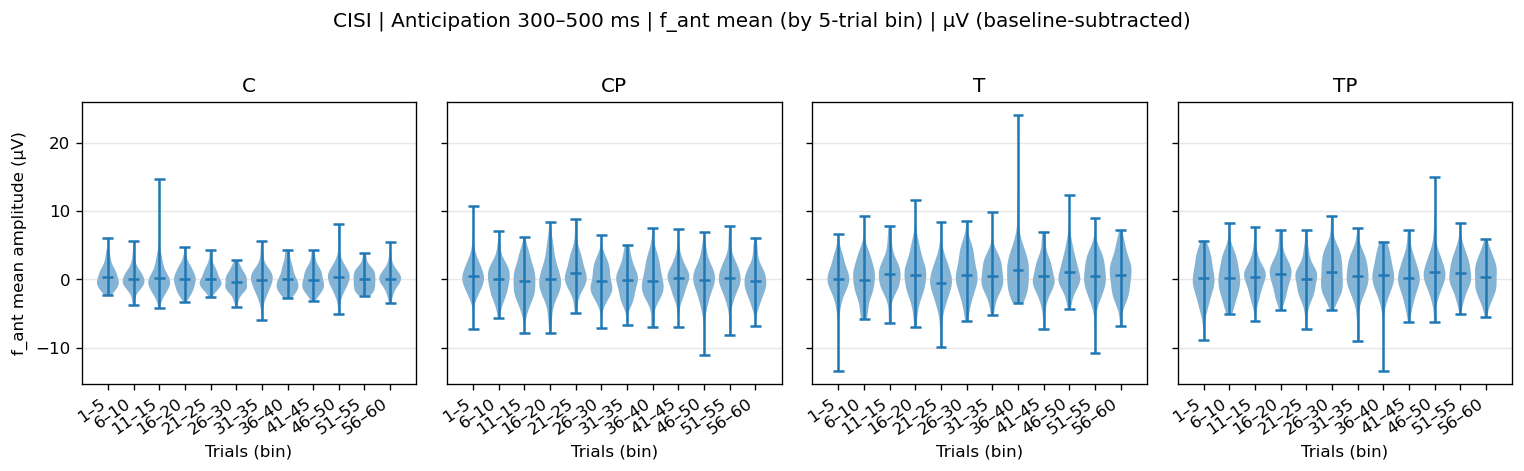


--- First 5 vs last 5 trials (within-subject mean f_ant_mean_amp) | µV (baseline-subtracted) ---


,region,n_sub,mean_first10,mean_last10,mean_diff_last_minus_first,paired_t_p,wilcoxon_p
0,C,14,0.360970,0.142081,-0.218889,0.495259,0.583008
1,CP,14,0.495192,-0.256043,-0.751235,0.126343,0.135254
2,T,14,0.017341,0.723175,0.705834,0.073015,0.118896
3,TP,14,0.183203,0.356132,0.172929,0.663392,0.541626


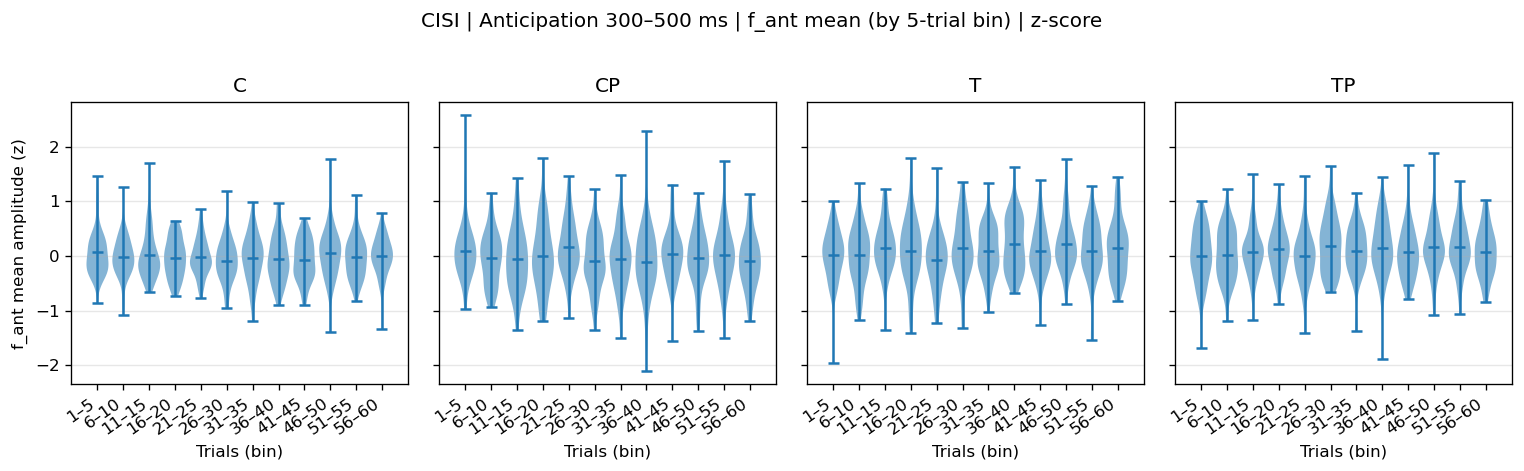


--- First 5 vs last 5 trials (within-subject mean f_ant_mean_amp) | z-score ---


,region,n_sub,mean_first10,mean_last10,mean_diff_last_minus_first,paired_t_p,wilcoxon_p
0,C,14,0.074390,-0.006946,-0.081335,0.326940,0.426270
1,CP,14,0.092985,-0.091594,-0.184579,0.099378,0.118896
2,T,14,0.023803,0.145054,0.121251,0.122831,0.104004
3,TP,14,0.000947,0.064841,0.063894,0.348658,0.390991


In [15]:
# §5c — Anticipation (300–500 ms, f_ant): 10-trial bins (violin) + first 10 vs last 10 per subject
# Run after §4b (cell 16) and the rolling cell (cell 20). Uses region-mean `f_ant_mean_amp` (no rolling).

from scipy import stats

ANT_VIOLIN_BIN = 5
_ant_col = "f_ant_mean_amp"


def _trial_bin_label(trial_index, bin_size=ANT_VIOLIN_BIN):
    b = int((int(trial_index) - 1) // bin_size)
    lo = b * bin_size + 1
    hi = b * bin_size + bin_size
    return f"{lo}–{hi}"


def _anticipation_violin_and_first_last(roll_df, tag_human, y_label):
    if roll_df is None or len(roll_df) == 0:
        print(f"[anticipation bins] skip ({tag_human}): empty dataframe")
        return
    if _ant_col not in roll_df.columns:
        raise RuntimeError(f"Missing {_ant_col}; run feature + rolling cells first.")

    df = roll_df[["sub_id", "region", "trial_index", _ant_col]].dropna(subset=[_ant_col]).copy()
    df["trial_bin"] = df["trial_index"].map(_trial_bin_label)
    bin_order = sorted(df["trial_bin"].unique(), key=lambda s: int(s.split("–")[0]))
    regions = sorted(df["region"].unique())

    n_reg = len(regions)
    fig, axes = plt.subplots(
        1, n_reg, figsize=(max(3.2 * n_reg, 6), 3.8), sharey=True, squeeze=False
    )
    for ax, region in zip(axes[0], regions):
        sub = df[df["region"] == region]
        data = [
            sub.loc[sub["trial_bin"] == lab, _ant_col].to_numpy()
            for lab in bin_order
        ]
        parts = ax.violinplot(
            data,
            positions=np.arange(len(bin_order)),
            showmeans=True,
            showmedians=False,
            widths=0.85,
        )
        for b in parts["bodies"]:
            b.set_alpha(0.55)
        ax.set_xticks(np.arange(len(bin_order)))
        ax.set_xticklabels(bin_order, rotation=35, ha="right")
        ax.set_title(region)
        ax.set_xlabel("Trials (bin)")
        ax.grid(True, axis="y", alpha=0.3)
    axes[0, 0].set_ylabel(y_label)
    fig.suptitle(
        f"{CHANNELS} | Anticipation 300–500 ms | f_ant mean (by {ANT_VIOLIN_BIN}-trial bin) | {tag_human}",
        y=1.02,
    )
    fig.tight_layout()
    plt.show()

    # First 10 vs last 10: within-subject means, paired tests
    rows = []
    for region in regions:
        sub = df[df["region"] == region]
        first_last = []
        for sid, g in sub.groupby("sub_id"):
            g = g.sort_values("trial_index")
            tmax = int(g["trial_index"].max())
            if tmax < 2 * ANT_VIOLIN_BIN:
                continue
            m_first = g.loc[g["trial_index"] <= ANT_VIOLIN_BIN, _ant_col].mean()
            m_last = g.loc[g["trial_index"] > tmax - ANT_VIOLIN_BIN, _ant_col].mean()
            if np.isnan(m_first) or np.isnan(m_last):
                continue
            first_last.append((sid, m_first, m_last))
        if len(first_last) < 3:
            rows.append(
                {
                    "region": region,
                    "n_sub": len(first_last),
                    "note": "too few subjects for paired test",
                }
            )
            continue
        a = np.array([x[1] for x in first_last])
        b = np.array([x[2] for x in first_last])
        tt = stats.ttest_rel(a, b, nan_policy="omit")
        try:
            wil = stats.wilcoxon(a, b, zero_method="wilcox", alternative="two-sided")
            wp, wstat = wil.pvalue, wil.statistic
        except ValueError:
            wp, wstat = np.nan, np.nan
        rows.append(
            {
                "region": region,
                "n_sub": len(first_last),
                "mean_first10": float(np.nanmean(a)),
                "mean_last10": float(np.nanmean(b)),
                "mean_diff_last_minus_first": float(np.nanmean(b - a)),
                "paired_t_p": float(tt.pvalue),
                "wilcoxon_p": float(wp) if wp == wp else np.nan,
            }
        )

    stat_df = pd.DataFrame(rows)
    print(f"\n--- First {ANT_VIOLIN_BIN} vs last {ANT_VIOLIN_BIN} trials (within-subject mean {_ant_col}) | {tag_human} ---")
    display(stat_df)


for _tag_key, _lab, _y in [
    ("bc", "µV (baseline-subtracted)", "f_ant mean amplitude (µV)"),
    ("z", "z-score", "f_ant mean amplitude (z)"),
]:
    _df_roll = rolling_by_tag[_tag_key]["erp_roi_roll_df"]
    _anticipation_violin_and_first_last(_df_roll, _lab, _y)


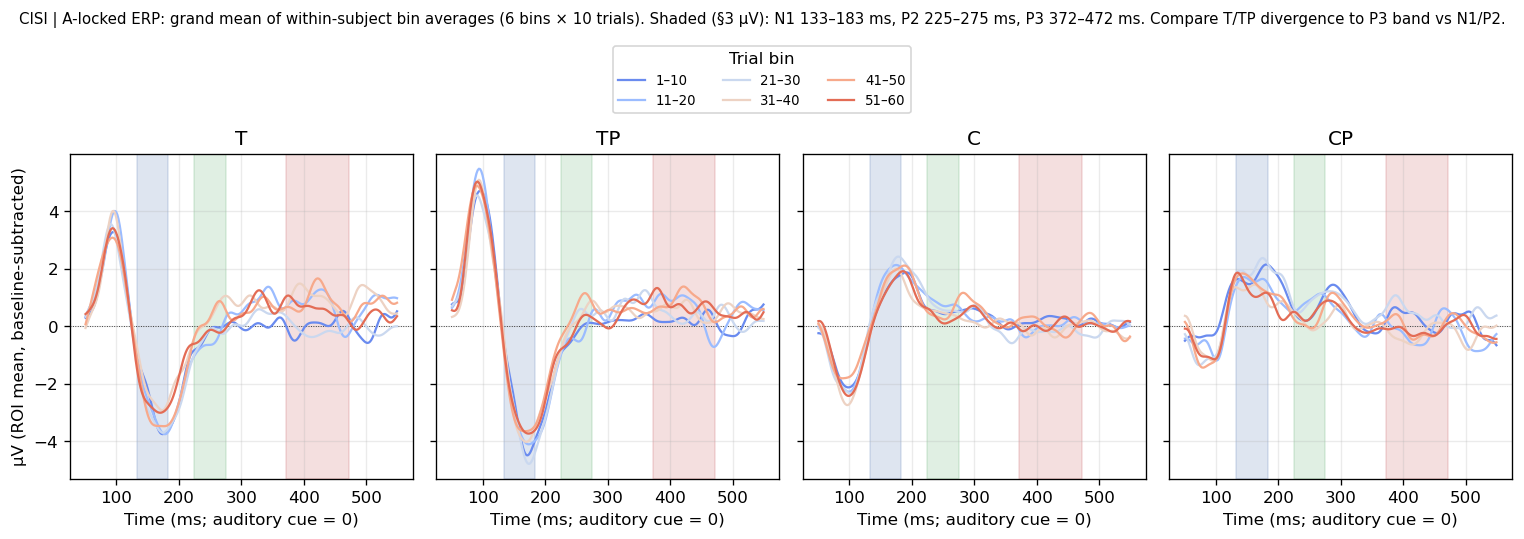

In [16]:
# §5d — Auditory onset = 0 ms: mean ERP in 6 trial bins, with §3 N1_A / P2_A / P3_A windows
# If T/TP bin differences line up with the shaded P3 window, the f_ant (300–500 ms) effect may track cue-locked P3 rather than anticipation-specific generators.

N_BINS_WF = 6
TRIALS_PER_BIN_WF = 10
A_COMPS_SHADE = ["N1_A", "P2_A", "P3_A"]
TMIN_PLOT_MS, TMAX_PLOT_MS = 50.0, 550.0
_COMP_FACE = {"N1_A": "#4c72b0", "P2_A": "#55a868", "P3_A": "#c44e52"}


def _win_s_from_res_row(row):
    fs, fe = row["final_start_ms"], row["final_end_ms"]
    if np.isnan(fs) or np.isnan(fe):
        fs, fe = row["search_start_ms"], row["search_end_ms"]
    return fs / 1000.0, fe / 1000.0


def _grand_avg_binned_waveforms_bc(region_channels):
    """Grand mean ERP: per subject, mean µV within each trial bin (ROI channels), then mean across subjects."""
    times_ref = None
    sub_curves = []
    for sub_id in SUBJECT_IDS:
        pack = all_sub_data[sub_id]
        data = pack["data_bc"]
        times_s = pack["times"]
        ch_names = pack["ch_names"]
        cmap = {ch: i for i, ch in enumerate(ch_names)}
        ix = [cmap[c] for c in region_channels if c in cmap]
        if not ix:
            continue
        if times_ref is None:
            times_ref = np.asarray(times_s, dtype=float)
        elif len(times_s) != len(times_ref) or not np.allclose(times_s, times_ref):
            raise RuntimeError("Inconsistent time axis across subjects.")
        w = np.nanmean(data[:, ix, :], axis=1)
        n = w.shape[0]
        curves = []
        for b in range(N_BINS_WF):
            lo = b * TRIALS_PER_BIN_WF
            hi = min((b + 1) * TRIALS_PER_BIN_WF, n)
            if lo >= hi:
                curves.append(np.full(data.shape[2], np.nan))
            else:
                curves.append(np.nanmean(w[lo:hi], axis=0))
        sub_curves.append(np.stack(curves))
    if times_ref is None or len(sub_curves) == 0:
        raise RuntimeError("No data for binned waveforms.")
    return times_ref, np.nanmean(np.stack(sub_curves), axis=0)


try:
    _regions_wf = REGIONS_DICT[CHANNELS]
except NameError as e:
    raise RuntimeError("Run the rolling cell that defines REGIONS_DICT.") from e

if "res_aud_bc" not in globals():
    raise RuntimeError("Run §3 detection first — need res_aud_bc.")

_times_wf, _ = _grand_avg_binned_waveforms_bc(next(iter(_regions_wf.values())))
_t_ms = _times_wf * 1000.0
_m_wf = (_t_ms >= TMIN_PLOT_MS) & (_t_ms <= TMAX_PLOT_MS)

_bin_colors_wf = plt.cm.coolwarm(np.linspace(0.15, 0.85, N_BINS_WF))
fig_wf, axes_wf = plt.subplots(
    1, len(_regions_wf), figsize=(3.2 * len(_regions_wf), 3.9), sharey=True, squeeze=False
)

for ax_wf, (rname_wf, rchs_wf) in zip(axes_wf[0], _regions_wf.items()):
    _, wb_wf = _grand_avg_binned_waveforms_bc(rchs_wf)
    for comp in A_COMPS_SHADE:
        t0s, t1s = _win_s_from_res_row(res_aud_bc.loc[comp])
        ax_wf.axvspan(
            t0s * 1000,
            t1s * 1000,
            alpha=0.18,
            color=_COMP_FACE[comp],
            zorder=0,
        )
    for b in range(N_BINS_WF):
        ax_wf.plot(
            _t_ms[_m_wf],
            wb_wf[b][_m_wf],
            color=_bin_colors_wf[b],
            lw=1.35,
            label=f"{b * TRIALS_PER_BIN_WF + 1}–{(b + 1) * TRIALS_PER_BIN_WF}",
            zorder=2,
        )
    ax_wf.axhline(0, color="k", lw=0.55, ls=":", zorder=1)
    ax_wf.set_xlabel("Time (ms; auditory cue = 0)")
    ax_wf.set_title(rname_wf)
    ax_wf.grid(True, alpha=0.25)

axes_wf[0, 0].set_ylabel("µV (ROI mean, baseline-subtracted)")
_h_wf, _l_wf = axes_wf[0, -1].get_legend_handles_labels()
fig_wf.legend(
    _h_wf,
    _l_wf,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.08),
    fontsize=8,
    title="Trial bin",
)

_comp_lbl = []
for comp in A_COMPS_SHADE:
    t0s, t1s = _win_s_from_res_row(res_aud_bc.loc[comp])
    short = comp.replace("_A", "")
    _comp_lbl.append(f"{short} {t0s * 1000:.0f}–{t1s * 1000:.0f} ms")
fig_wf.suptitle(
    f"{CHANNELS} | A-locked ERP: grand mean of within-subject bin averages ({N_BINS_WF} bins × {TRIALS_PER_BIN_WF} trials). "
    f"Shaded (§3 µV): {', '.join(_comp_lbl)}. Compare T/TP divergence to P3 band vs N1/P2.",
    y=1.14,
    fontsize=9,
)
fig_wf.tight_layout()
plt.show()


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


def _fit_line_and_label(x, y):
    """Linear regression y ~ x; return slope, intercept, p-value, significance str, mask."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 3:
        return None
    res = linregress(x[m], y[m])
    sig = ""
    if res.pvalue < 0.001:
        sig = "***"
    elif res.pvalue < 0.01:
        sig = "**"
    elif res.pvalue < 0.05:
        sig = "*"
    else:
        sig = "(n.s.)"
    return res.slope, res.intercept, float(res.pvalue), sig, m


def plot_group_trial_dynamics(
    erp_roi_group_roll_df,
    feature_keys,
    CONDITION=None,
    group_col="region",
    b_plot_channel_seperate=True,
    feature_specs=None,
    comp_colors=None,
    linestyle_map=None,
    figsize_per_row=(8, 3),
    show_linear_fit=True,
    fit_linestyle=":",
    fit_linewidth=1.4,
    fit_alpha=0.9,
    report_console="all",
    show_comp_legend=True,
):
    """
    Plot grand-average rolling ERP features.

    If show_linear_fit is True, overlays OLS of rolling mean vs trial_index.
    Stats (β, p, significance) are printed only — not drawn on the figure.
    report_console: "all" | "sig" | "none" — which fits to print.
    show_comp_legend: if True, draw a figure-level legend on the right (component / curve keys).
    """

    if feature_specs is None:
        feature_specs = [
            ("mean_amp_roll_mean", "mean_amp_roll_sem", "Mean amplitude (z)", "Mean amplitude"),
        ]

    if comp_colors is None:
        color_list = [
            "royalblue", "crimson", "seagreen", "darkorange",
            "purple", "brown", "teal", "magenta"
        ]
        comp_colors = {
            comp: color for comp, color in zip(feature_keys, color_list)
        }

    if group_col not in erp_roi_group_roll_df.columns:
        raise ValueError(f"`{group_col}` not found in dataframe columns")

    group_names = list(erp_roi_group_roll_df[group_col].dropna().unique())
    if len(group_names) == 0:
        raise ValueError(f"No valid groups found in column `{group_col}`")

    # One line per figure so §5b visibly runs
    print(
        f"[trial dynamics] {CONDITION or 'ERP'} | keys={feature_keys} | n_groups={len(group_names)}",
        flush=True,
    )

    if linestyle_map is None:
        base_styles = ["-", "--", ":", "-."]
        linestyle_map = {
            g: base_styles[i % len(base_styles)]
            for i, g in enumerate(group_names)
        }

    # ======================================================
    # Mode 1: separate subplot for each group
    # ======================================================
    if b_plot_channel_seperate:
        n_rows = len(feature_specs)
        n_cols = len(group_names)
        # Cap width so Jupyter / VS Code does not choke on 8*4=32" wide figures
        max_fig_w = 18.0
        col_w = min(figsize_per_row[0], max_fig_w / max(n_cols, 1))

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(col_w * n_cols, figsize_per_row[1] * n_rows),
            sharex=True,
            squeeze=False
        )

        for c, group_name in enumerate(group_names):
            df_g = (
                erp_roi_group_roll_df[erp_roi_group_roll_df[group_col] == group_name]
                .sort_values("trial_index")
                .reset_index(drop=True)
            )

            trial_idx = df_g["trial_index"].values.astype(float)

            for r, (mean_suffix, sem_suffix, ylab, title_feat) in enumerate(feature_specs):
                ax = axes[r, c]

                for comp in feature_keys:
                    mean_col = f"{comp}_{mean_suffix}"
                    sem_col = f"{comp}_{sem_suffix}"

                    if mean_col not in df_g.columns or sem_col not in df_g.columns:
                        print(f"Skip {group_name}-{comp}: missing {mean_col} or {sem_col}")
                        continue

                    mean_vals = df_g[mean_col].values
                    sem_vals = df_g[sem_col].values
                    color = comp_colors.get(comp, None)

                    ax.plot(
                        trial_idx,
                        mean_vals,
                        linewidth=2.0,
                        color=color,
                        linestyle="-",
                        label=comp
                    )

                    ax.fill_between(
                        trial_idx,
                        mean_vals - sem_vals,
                        mean_vals + sem_vals,
                        alpha=0.18,
                        color=color,
                        linewidth=0
                    )

                    if show_linear_fit:
                        fit = _fit_line_and_label(trial_idx, mean_vals)
                        if fit is not None:
                            slope, intercept, pval, sig, _ = fit
                            xline = np.array(
                                [np.nanmin(trial_idx), np.nanmax(trial_idx)], dtype=float
                            )
                            ax.plot(
                                xline,
                                intercept + slope * xline,
                                linestyle=fit_linestyle,
                                linewidth=fit_linewidth,
                                color=color,
                                alpha=fit_alpha,
                                zorder=3,
                            )
                            line = f"{comp}: β={slope:.4g}, p={pval:.3g} {sig}"
                            if report_console != "none":
                                if report_console == "all" or sig != "(n.s.)":
                                    print(
                                        f"{CONDITION} | {group_name} | {title_feat} | {line}",
                                        flush=True,
                                    )

                if "latency" not in title_feat.lower():
                    ax.axhline(0, color="gray", linewidth=0.6, linestyle="--", alpha=0.6)

                if c == 0:
                    ax.set_ylabel(ylab, fontsize=10)

                ax.set_title(f"{group_name} — {title_feat}", fontsize=11)
                ax.grid(True, alpha=0.25)

        for ax in axes[-1, :]:
            ax.set_xlabel("Trial index", fontsize=11)

        title_prefix = CONDITION if CONDITION is not None else "ERP"
        fig.suptitle(
            f"{title_prefix} — Group Trial-by-Trial Neural Dynamics\n"
            f"(separate {group_col} panels; dashed line = OLS of rolling mean vs trial)",
            fontsize=13
        )
        fig.tight_layout(rect=[0, 0, 0.88, 0.95])
        if show_comp_legend:
            h, l = axes[0, 0].get_legend_handles_labels()
            if h:
                fig.legend(
                    h,
                    l,
                    loc="center right",
                    bbox_to_anchor=(1.0, 0.5),
                    bbox_transform=fig.transFigure,
                    fontsize=9,
                    frameon=True,
                )
        plt.show()

    # ======================================================
    # Mode 2: overlay all groups in one subplot per feature
    # ======================================================
    else:
        n_plots = len(feature_specs)
        fig, axes = plt.subplots(
            n_plots, 1,
            figsize=(6, 3 * n_plots),
            sharex=True
        )

        if n_plots == 1:
            axes = [axes]

        for ax, (mean_suffix, sem_suffix, ylab, title_feat) in zip(axes, feature_specs):
            for group_name in group_names:
                df_g = (
                    erp_roi_group_roll_df[erp_roi_group_roll_df[group_col] == group_name]
                    .sort_values("trial_index")
                    .reset_index(drop=True)
                )

                trial_idx = df_g["trial_index"].values.astype(float)
                ls = linestyle_map[group_name]

                for comp in feature_keys:
                    mean_col = f"{comp}_{mean_suffix}"
                    sem_col = f"{comp}_{sem_suffix}"

                    if mean_col not in df_g.columns or sem_col not in df_g.columns:
                        print(f"Skip {group_name}-{comp}: missing {mean_col} or {sem_col}")
                        continue

                    mean_vals = df_g[mean_col].values
                    sem_vals = df_g[sem_col].values
                    color = comp_colors.get(comp, None)

                    ax.plot(
                        trial_idx,
                        mean_vals,
                        linewidth=2.0,
                        color=color,
                        linestyle=ls,
                        label=f"{comp}-{group_name}"
                    )

                    ax.fill_between(
                        trial_idx,
                        mean_vals - sem_vals,
                        mean_vals + sem_vals,
                        alpha=0.08,
                        color=color,
                        linewidth=0
                    )

                    if show_linear_fit:
                        fit = _fit_line_and_label(trial_idx, mean_vals)
                        if fit is not None:
                            slope, intercept, pval, sig, _ = fit
                            xline = np.array(
                                [np.nanmin(trial_idx), np.nanmax(trial_idx)], dtype=float
                            )
                            ax.plot(
                                xline,
                                intercept + slope * xline,
                                linestyle=fit_linestyle,
                                linewidth=fit_linewidth,
                                color=color,
                                alpha=fit_alpha,
                                zorder=3,
                            )
                            line = f"{comp}-{group_name}: β={slope:.4g}, p={pval:.3g} {sig}"
                            if report_console != "none":
                                if report_console == "all" or sig != "(n.s.)":
                                    print(
                                        f"{CONDITION} | overlay | {title_feat} | {line}",
                                        flush=True,
                                    )

            if "latency" not in title_feat.lower():
                ax.axhline(0, color="gray", linewidth=0.6, linestyle="--", alpha=0.6)

            ax.set_ylabel(ylab, fontsize=10)
            ax.set_title(f"Group trend — {title_feat}", fontsize=11)
            ax.grid(True, alpha=0.25)

        axes[-1].set_xlabel("Trial index", fontsize=11)

        title_prefix = CONDITION if CONDITION is not None else "ERP"
        fig.suptitle(
            f"{title_prefix} — Group Trial-by-Trial Neural Dynamics\n"
            f"(overlay {group_col}; dashed line = OLS of rolling mean vs trial)",
            fontsize=13
        )
        fig.tight_layout(rect=[0, 0, 0.88, 0.95])
        if show_comp_legend:
            h, l = axes[0].get_legend_handles_labels()
            if h:
                fig.legend(
                    h,
                    l,
                    loc="center right",
                    bbox_to_anchor=(1.0, 0.5),
                    bbox_transform=fig.transFigure,
                    fontsize=8,
                    frameon=True,
                )
        plt.show()


§5b: trial dynamics — generating figures (one [trial dynamics] line per figure)
[trial dynamics] CISI | A-locked (0 ms) | Mean amplitude | µV | keys=['P50_A', 'N1_A', 'P2_A', 'N2_A', 'P3_A'] | n_groups=4
CISI | A-locked (0 ms) | Mean amplitude | µV | C | Mean amplitude | P50_A: β=-4.658e-05, p=0.982 (n.s.)
CISI | A-locked (0 ms) | Mean amplitude | µV | C | Mean amplitude | N1_A: β=-0.003499, p=0.0976 (n.s.)
CISI | A-locked (0 ms) | Mean amplitude | µV | C | Mean amplitude | P2_A: β=-0.006154, p=0.00026 ***
CISI | A-locked (0 ms) | Mean amplitude | µV | C | Mean amplitude | N2_A: β=-0.002295, p=0.251 (n.s.)
CISI | A-locked (0 ms) | Mean amplitude | µV | C | Mean amplitude | P3_A: β=-0.002412, p=0.124 (n.s.)
CISI | A-locked (0 ms) | Mean amplitude | µV | CP | Mean amplitude | P50_A: β=-0.01562, p=2.59e-08 ***
CISI | A-locked (0 ms) | Mean amplitude | µV | CP | Mean amplitude | N1_A: β=-0.008342, p=0.0136 *
CISI | A-locked (0 ms) | Mean amplitude | µV | CP | Mean amplitude | P2_A: β=-0.00

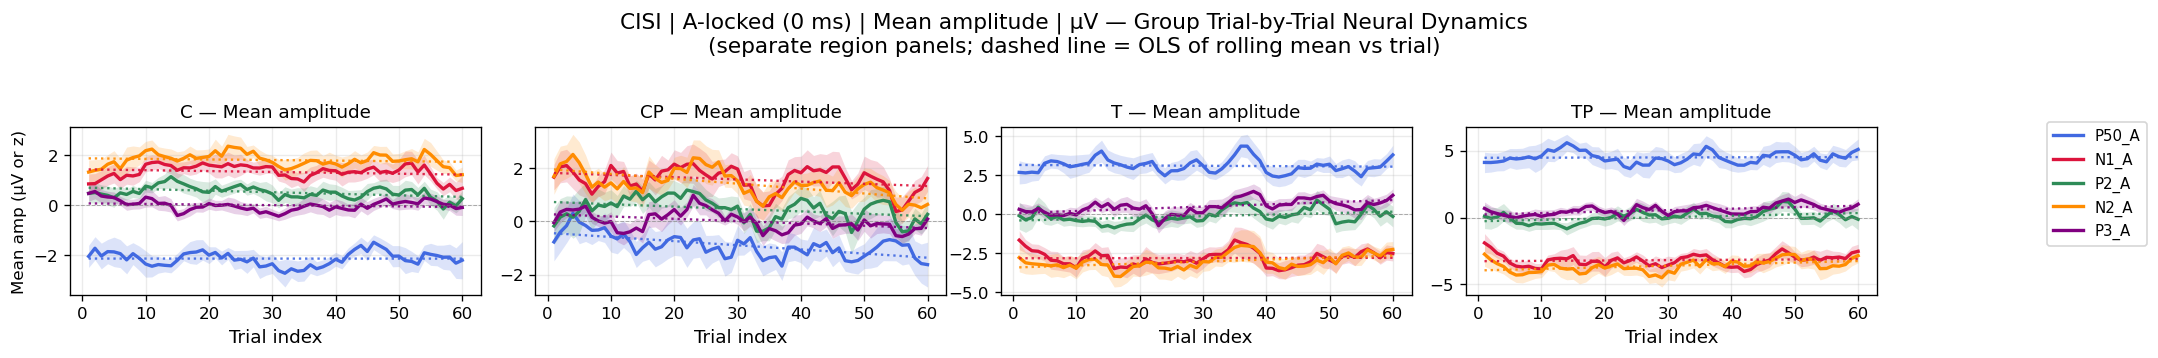

[trial dynamics] CISI | T-locked (500 ms) | Mean amplitude | µV | keys=['P50_T', 'N1_T', 'P2_T', 'N2_T', 'P3_T'] | n_groups=4
CISI | T-locked (500 ms) | Mean amplitude | µV | C | Mean amplitude | P50_T: β=-0.003313, p=0.0306 *
CISI | T-locked (500 ms) | Mean amplitude | µV | C | Mean amplitude | N1_T: β=0.007026, p=0.000181 ***
CISI | T-locked (500 ms) | Mean amplitude | µV | C | Mean amplitude | P2_T: β=0.009798, p=1.61e-08 ***
CISI | T-locked (500 ms) | Mean amplitude | µV | C | Mean amplitude | N2_T: β=0.006209, p=0.000152 ***
CISI | T-locked (500 ms) | Mean amplitude | µV | C | Mean amplitude | P3_T: β=-0.003004, p=0.0444 *
CISI | T-locked (500 ms) | Mean amplitude | µV | CP | Mean amplitude | P50_T: β=-0.0007076, p=0.861 (n.s.)
CISI | T-locked (500 ms) | Mean amplitude | µV | CP | Mean amplitude | N1_T: β=0.006395, p=0.0133 *
CISI | T-locked (500 ms) | Mean amplitude | µV | CP | Mean amplitude | P2_T: β=0.0008194, p=0.803 (n.s.)
CISI | T-locked (500 ms) | Mean amplitude | µV | CP 

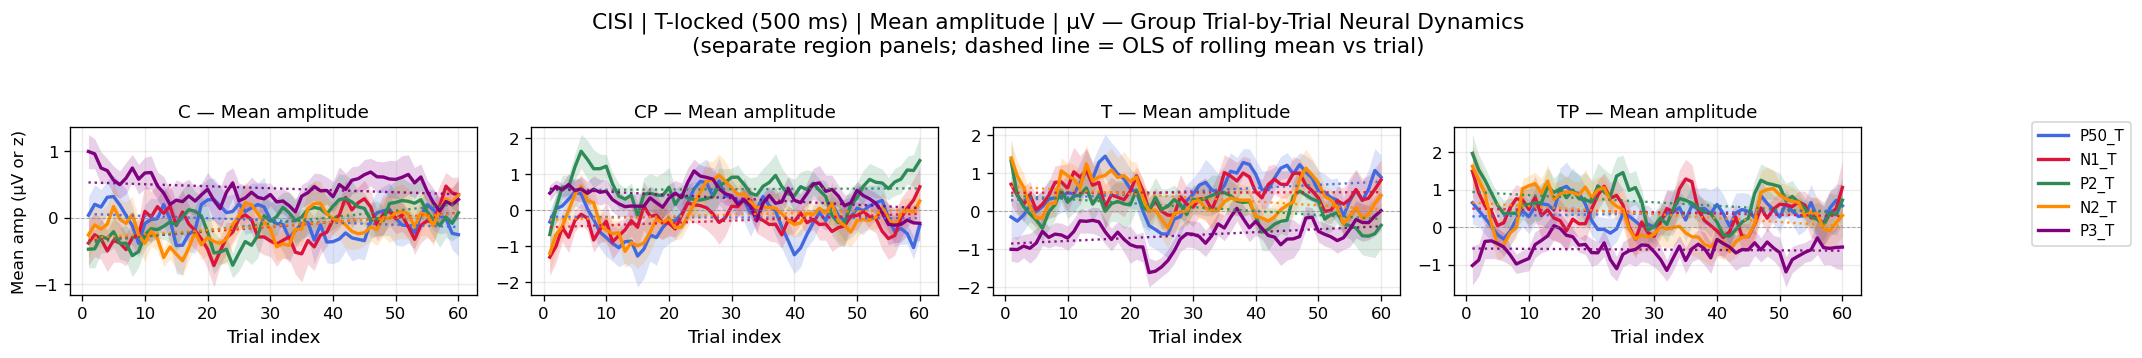

[trial dynamics] CISI | Anticipation (300–500 ms) | Mean amplitude | µV | keys=['f_ant'] | n_groups=4
CISI | Anticipation (300–500 ms) | Mean amplitude | µV | C | Mean amplitude | f_ant: β=-0.0006924, p=0.604 (n.s.)
CISI | Anticipation (300–500 ms) | Mean amplitude | µV | CP | Mean amplitude | f_ant: β=-0.006155, p=0.006 **
CISI | Anticipation (300–500 ms) | Mean amplitude | µV | T | Mean amplitude | f_ant: β=0.01202, p=7.05e-06 ***
CISI | Anticipation (300–500 ms) | Mean amplitude | µV | TP | Mean amplitude | f_ant: β=0.007879, p=0.000424 ***


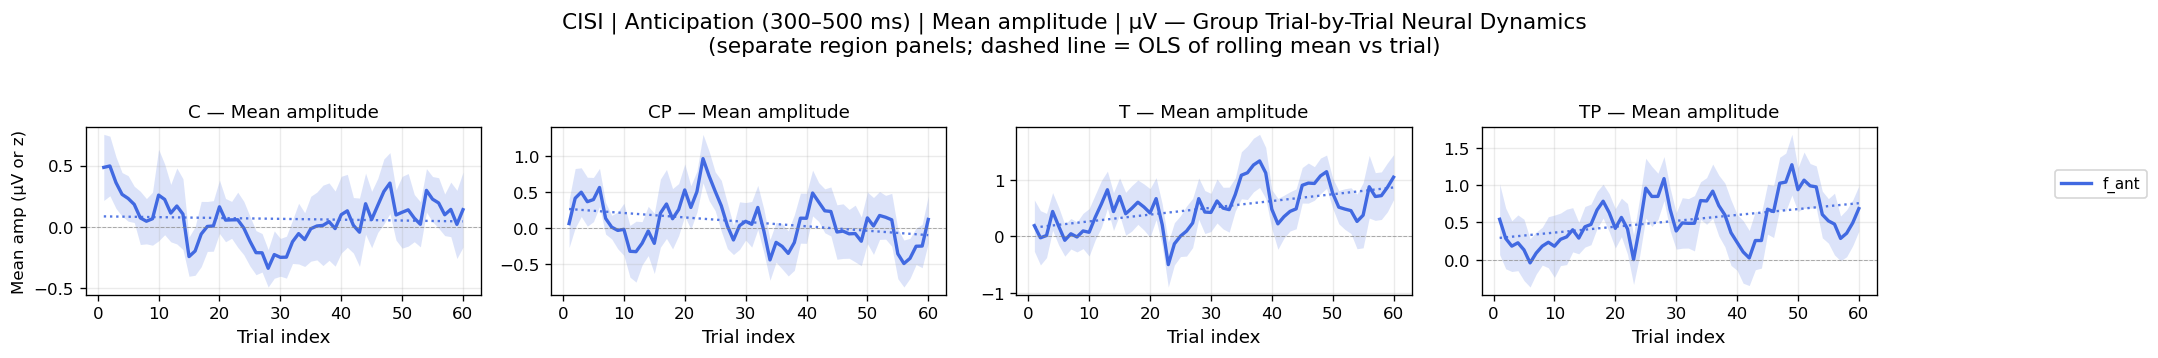

[trial dynamics] CISI | A-locked (0 ms) | Peak amplitude | µV | keys=['P50_A', 'N1_A', 'P2_A', 'N2_A', 'P3_A'] | n_groups=4
CISI | A-locked (0 ms) | Peak amplitude | µV | C | Peak amplitude | P50_A: β=0.001828, p=0.366 (n.s.)
CISI | A-locked (0 ms) | Peak amplitude | µV | C | Peak amplitude | N1_A: β=-0.006583, p=0.0168 *
CISI | A-locked (0 ms) | Peak amplitude | µV | C | Peak amplitude | P2_A: β=-0.00209, p=0.346 (n.s.)
CISI | A-locked (0 ms) | Peak amplitude | µV | C | Peak amplitude | N2_A: β=-0.005276, p=0.0348 *
CISI | A-locked (0 ms) | Peak amplitude | µV | C | Peak amplitude | P3_A: β=0.001563, p=0.432 (n.s.)
CISI | A-locked (0 ms) | Peak amplitude | µV | CP | Peak amplitude | P50_A: β=-0.009909, p=0.000171 ***
CISI | A-locked (0 ms) | Peak amplitude | µV | CP | Peak amplitude | N1_A: β=-0.01502, p=1e-05 ***
CISI | A-locked (0 ms) | Peak amplitude | µV | CP | Peak amplitude | P2_A: β=-0.004321, p=0.191 (n.s.)
CISI | A-locked (0 ms) | Peak amplitude | µV | CP | Peak amplitude | N

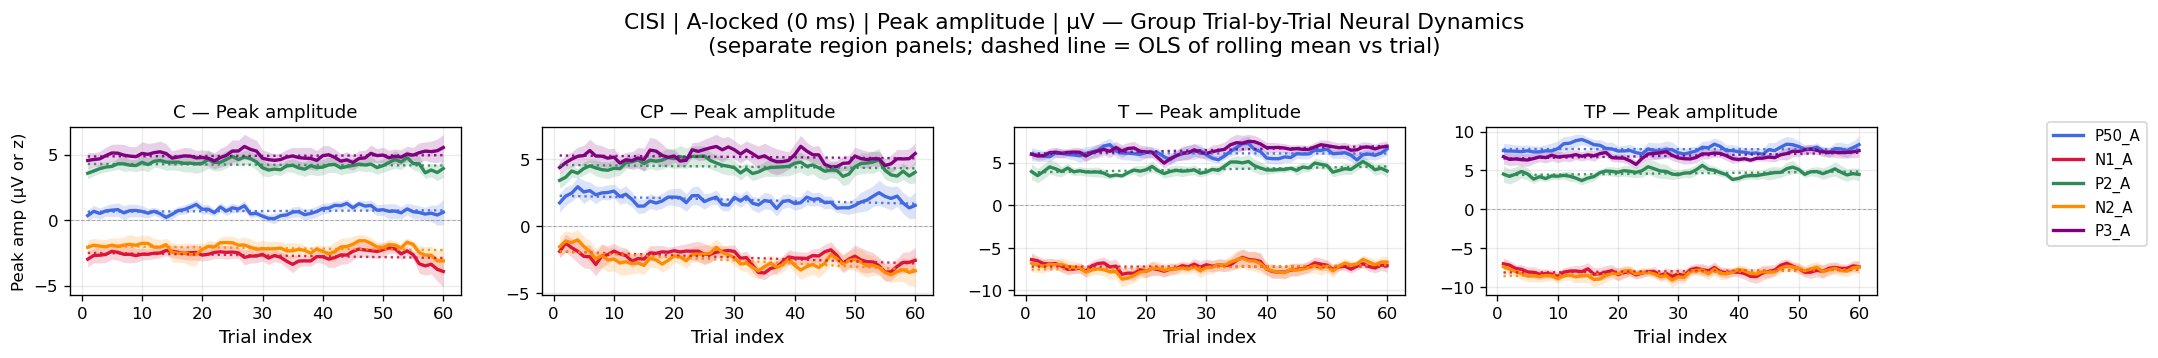

[trial dynamics] CISI | T-locked (500 ms) | Peak amplitude | µV | keys=['P50_T', 'N1_T', 'P2_T', 'N2_T', 'P3_T'] | n_groups=4
CISI | T-locked (500 ms) | Peak amplitude | µV | C | Peak amplitude | P50_T: β=-0.002285, p=0.285 (n.s.)
CISI | T-locked (500 ms) | Peak amplitude | µV | C | Peak amplitude | N1_T: β=0.007719, p=0.00237 **
CISI | T-locked (500 ms) | Peak amplitude | µV | C | Peak amplitude | P2_T: β=0.01826, p=3.67e-15 ***
CISI | T-locked (500 ms) | Peak amplitude | µV | C | Peak amplitude | N2_T: β=0.0009266, p=0.563 (n.s.)
CISI | T-locked (500 ms) | Peak amplitude | µV | C | Peak amplitude | P3_T: β=0.003661, p=0.0724 (n.s.)
CISI | T-locked (500 ms) | Peak amplitude | µV | CP | Peak amplitude | P50_T: β=0.001341, p=0.697 (n.s.)
CISI | T-locked (500 ms) | Peak amplitude | µV | CP | Peak amplitude | N1_T: β=0.003354, p=0.236 (n.s.)
CISI | T-locked (500 ms) | Peak amplitude | µV | CP | Peak amplitude | P2_T: β=0.007153, p=0.0308 *
CISI | T-locked (500 ms) | Peak amplitude | µV | 

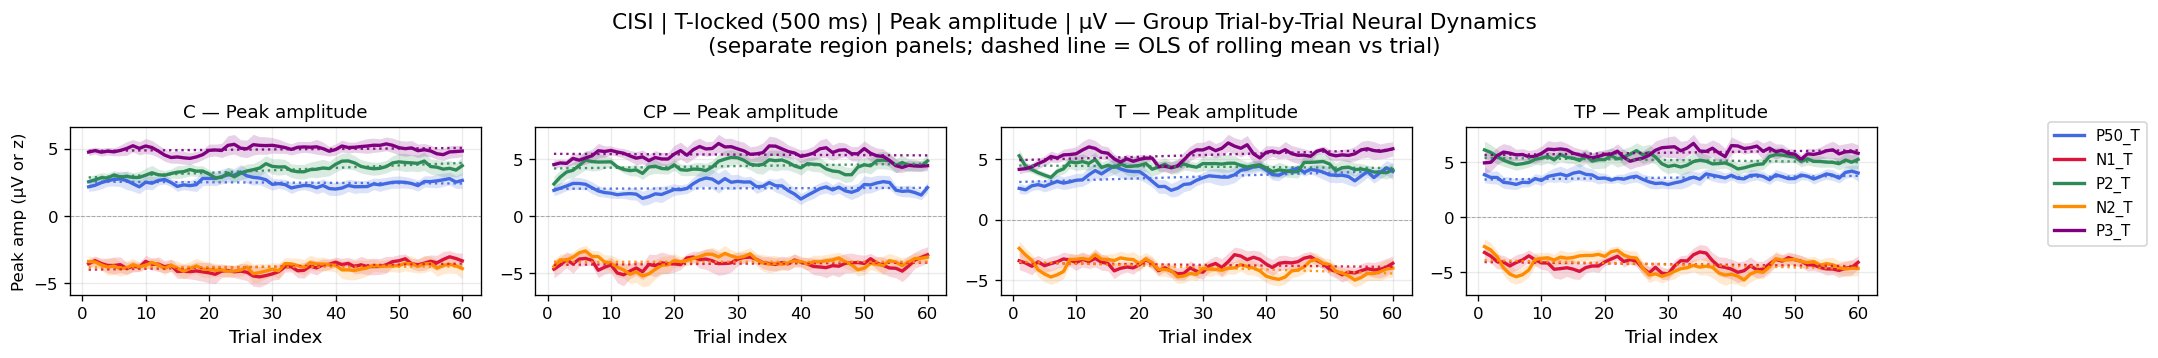

[trial dynamics] CISI | Anticipation (300–500 ms) | Peak amplitude | µV | keys=['f_ant'] | n_groups=4
CISI | Anticipation (300–500 ms) | Peak amplitude | µV | C | Peak amplitude | f_ant: β=0.0008666, p=0.69 (n.s.)
CISI | Anticipation (300–500 ms) | Peak amplitude | µV | CP | Peak amplitude | f_ant: β=-0.004006, p=0.185 (n.s.)
CISI | Anticipation (300–500 ms) | Peak amplitude | µV | T | Peak amplitude | f_ant: β=0.01901, p=3.43e-07 ***
CISI | Anticipation (300–500 ms) | Peak amplitude | µV | TP | Peak amplitude | f_ant: β=0.01034, p=0.000644 ***


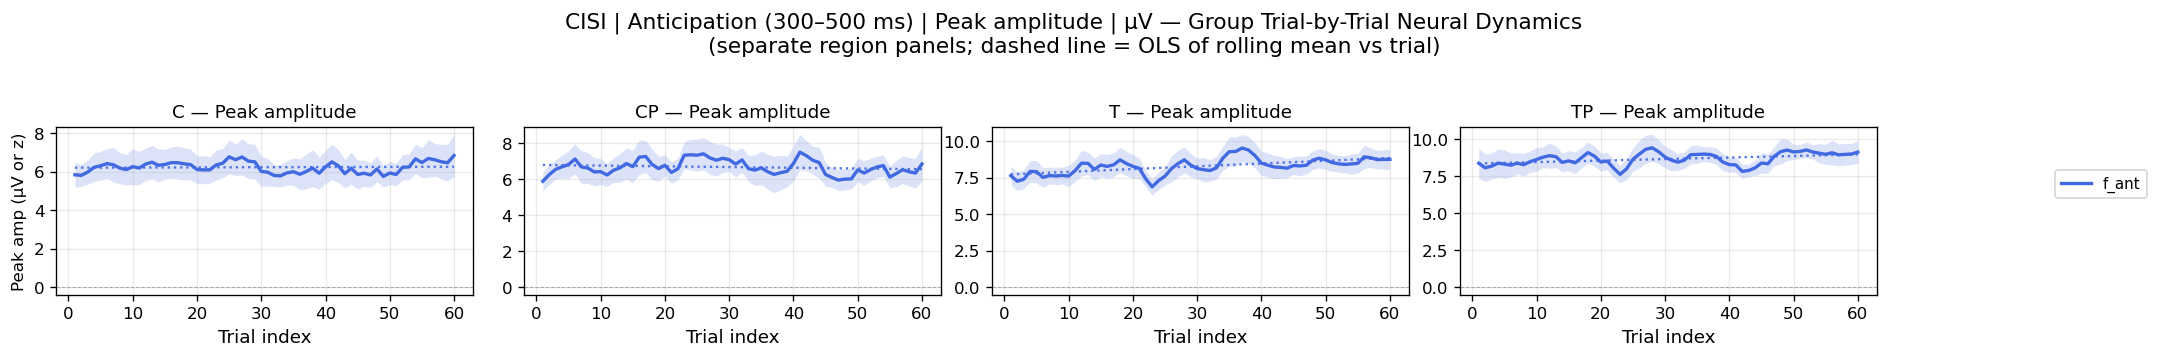

[trial dynamics] CISI | A-locked (0 ms) | Peak latency | µV | keys=['P50_A', 'N1_A', 'P2_A', 'N2_A', 'P3_A'] | n_groups=4
CISI | A-locked (0 ms) | Peak latency | µV | C | Peak latency | P50_A: β=0.03386, p=1.84e-07 ***
CISI | A-locked (0 ms) | Peak latency | µV | C | Peak latency | N1_A: β=0.02451, p=0.0158 *
CISI | A-locked (0 ms) | Peak latency | µV | C | Peak latency | P2_A: β=0.006798, p=0.522 (n.s.)
CISI | A-locked (0 ms) | Peak latency | µV | C | Peak latency | N2_A: β=0.02181, p=0.0065 **
CISI | A-locked (0 ms) | Peak latency | µV | C | Peak latency | P3_A: β=0.01744, p=0.493 (n.s.)
CISI | A-locked (0 ms) | Peak latency | µV | CP | Peak latency | P50_A: β=-0.02021, p=0.0183 *
CISI | A-locked (0 ms) | Peak latency | µV | CP | Peak latency | N1_A: β=0.03446, p=0.00367 **
CISI | A-locked (0 ms) | Peak latency | µV | CP | Peak latency | P2_A: β=-0.008684, p=0.49 (n.s.)
CISI | A-locked (0 ms) | Peak latency | µV | CP | Peak latency | N2_A: β=0.02373, p=0.027 *
CISI | A-locked (0 ms) 

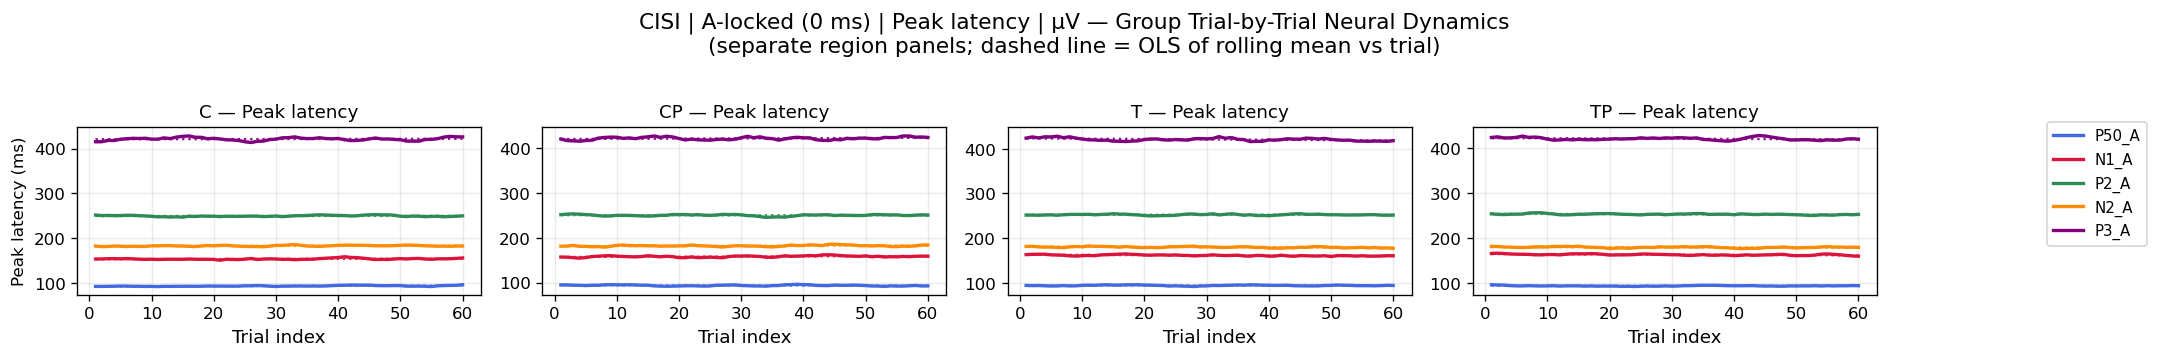

[trial dynamics] CISI | T-locked (500 ms) | Peak latency | µV | keys=['P50_T', 'N1_T', 'P2_T', 'N2_T', 'P3_T'] | n_groups=4
CISI | T-locked (500 ms) | Peak latency | µV | C | Peak latency | P50_T: β=0.0175, p=0.000109 ***
CISI | T-locked (500 ms) | Peak latency | µV | C | Peak latency | N1_T: β=-0.02209, p=0.0156 *
CISI | T-locked (500 ms) | Peak latency | µV | C | Peak latency | P2_T: β=0.002072, p=0.79 (n.s.)
CISI | T-locked (500 ms) | Peak latency | µV | C | Peak latency | N2_T: β=0.04267, p=3.99e-05 ***
CISI | T-locked (500 ms) | Peak latency | µV | C | Peak latency | P3_T: β=-0.02352, p=0.187 (n.s.)
CISI | T-locked (500 ms) | Peak latency | µV | CP | Peak latency | P50_T: β=0.02123, p=0.0295 *
CISI | T-locked (500 ms) | Peak latency | µV | CP | Peak latency | N1_T: β=-0.00584, p=0.542 (n.s.)
CISI | T-locked (500 ms) | Peak latency | µV | CP | Peak latency | P2_T: β=0.01526, p=0.154 (n.s.)
CISI | T-locked (500 ms) | Peak latency | µV | CP | Peak latency | N2_T: β=0.01875, p=0.0579 

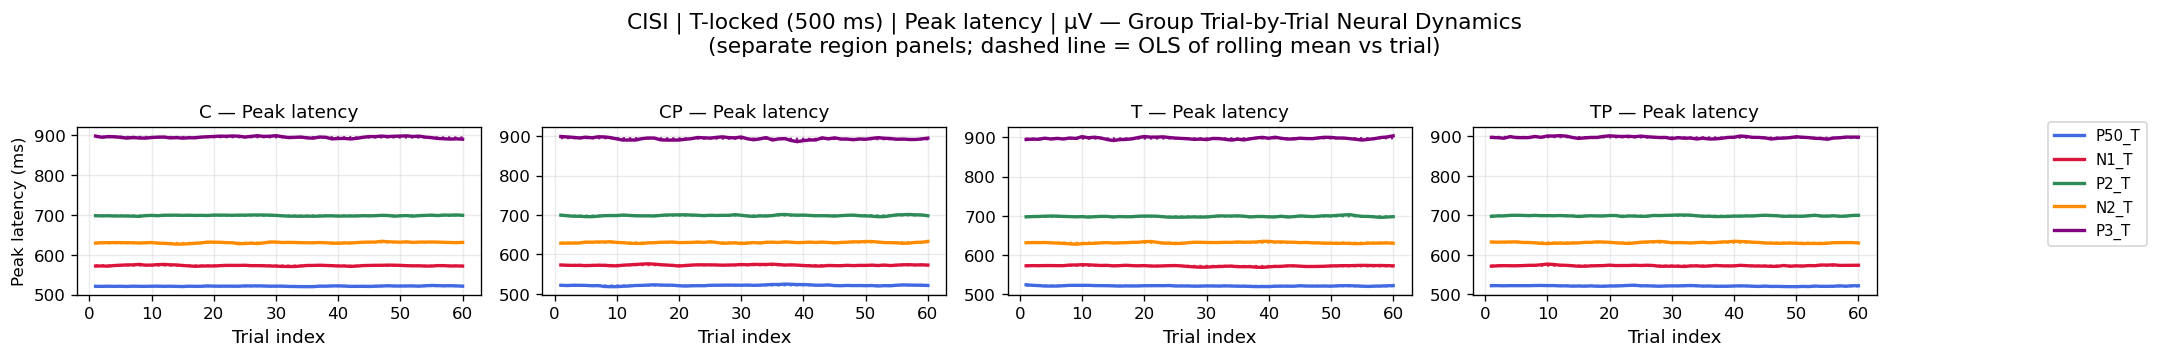

[trial dynamics] CISI | Anticipation (300–500 ms) | Peak latency | µV | keys=['f_ant'] | n_groups=4
CISI | Anticipation (300–500 ms) | Peak latency | µV | C | Peak latency | f_ant: β=-0.03297, p=0.485 (n.s.)
CISI | Anticipation (300–500 ms) | Peak latency | µV | CP | Peak latency | f_ant: β=0.04205, p=0.129 (n.s.)
CISI | Anticipation (300–500 ms) | Peak latency | µV | T | Peak latency | f_ant: β=0.008316, p=0.836 (n.s.)
CISI | Anticipation (300–500 ms) | Peak latency | µV | TP | Peak latency | f_ant: β=0.01817, p=0.675 (n.s.)


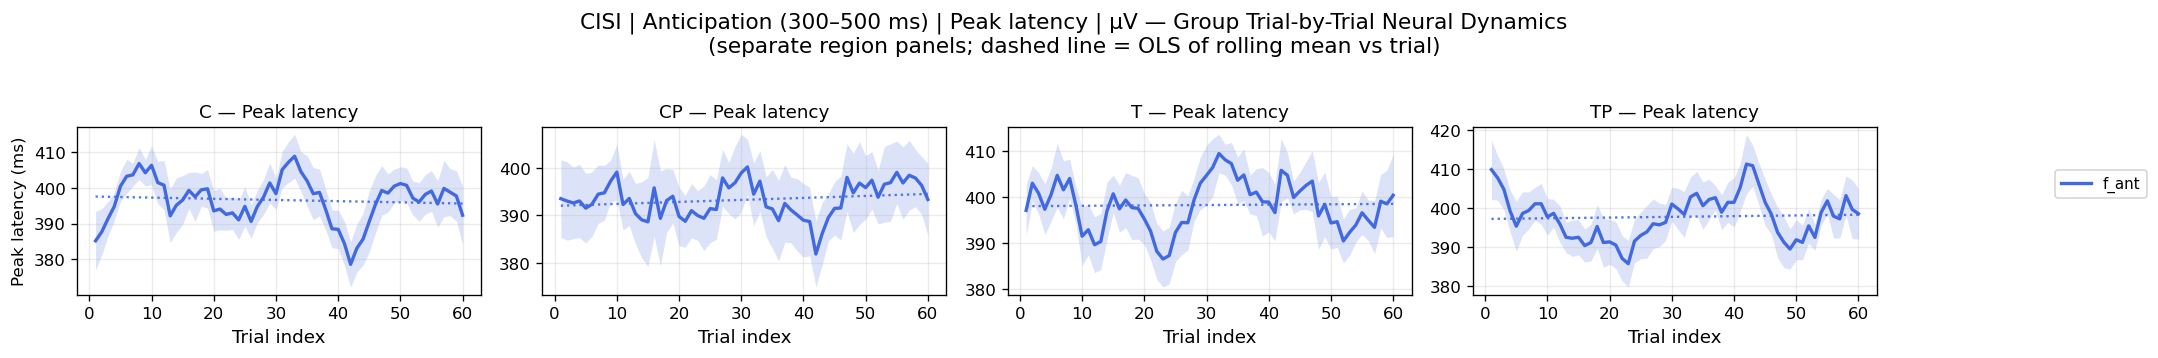

[trial dynamics] CISI | Welch band power (300–500 ms, dB vs baseline) | µV | keys=['freq_ANT200_500_beta_db'] | n_groups=4
CISI | Welch band power (300–500 ms, dB vs baseline) | µV | C | ANT window | freq_ANT200_500_beta_db: β=-0.01057, p=0.000193 ***
CISI | Welch band power (300–500 ms, dB vs baseline) | µV | CP | ANT window | freq_ANT200_500_beta_db: β=-0.01057, p=0.000193 ***


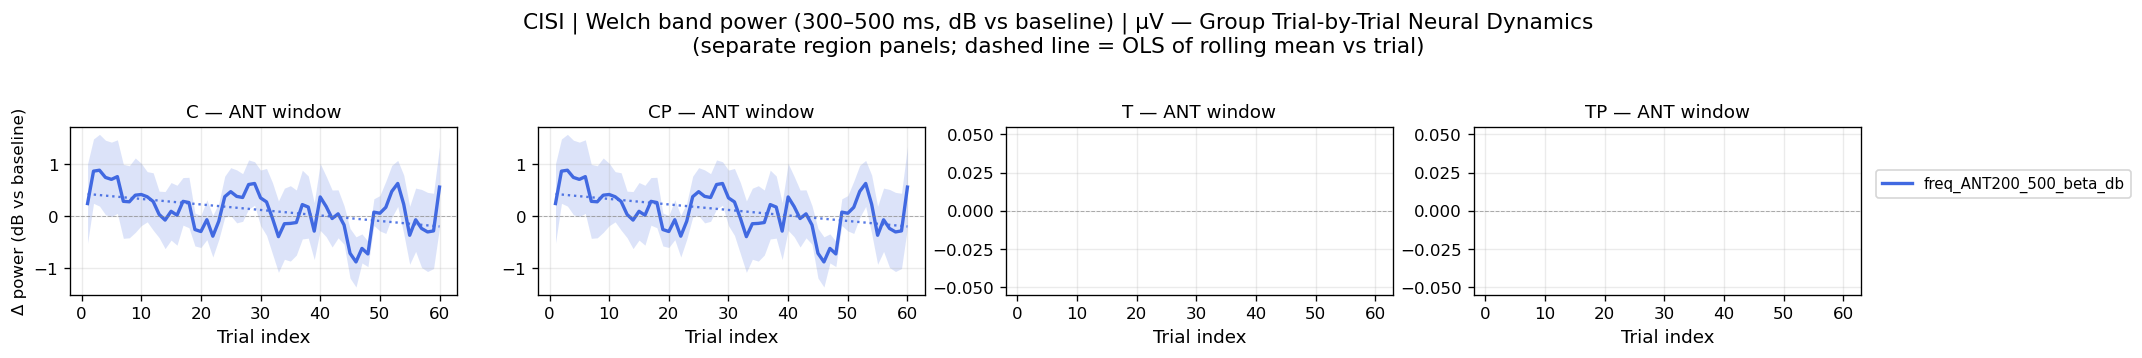

[trial dynamics] CISI | Stability: r vs template | µV | keys=['stab_sim_T', 'stab_sim_TP', 'stab_sim_C', 'stab_sim_CP'] | n_groups=4
CISI | Stability: r vs template | µV | C | Template similarity | stab_sim_C: β=-0.0004007, p=0.0142 *
CISI | Stability: r vs template | µV | CP | Template similarity | stab_sim_CP: β=8.467e-05, p=0.562 (n.s.)
CISI | Stability: r vs template | µV | T | Template similarity | stab_sim_T: β=-0.0003918, p=0.0033 **
CISI | Stability: r vs template | µV | TP | Template similarity | stab_sim_TP: β=-0.0001256, p=0.277 (n.s.)


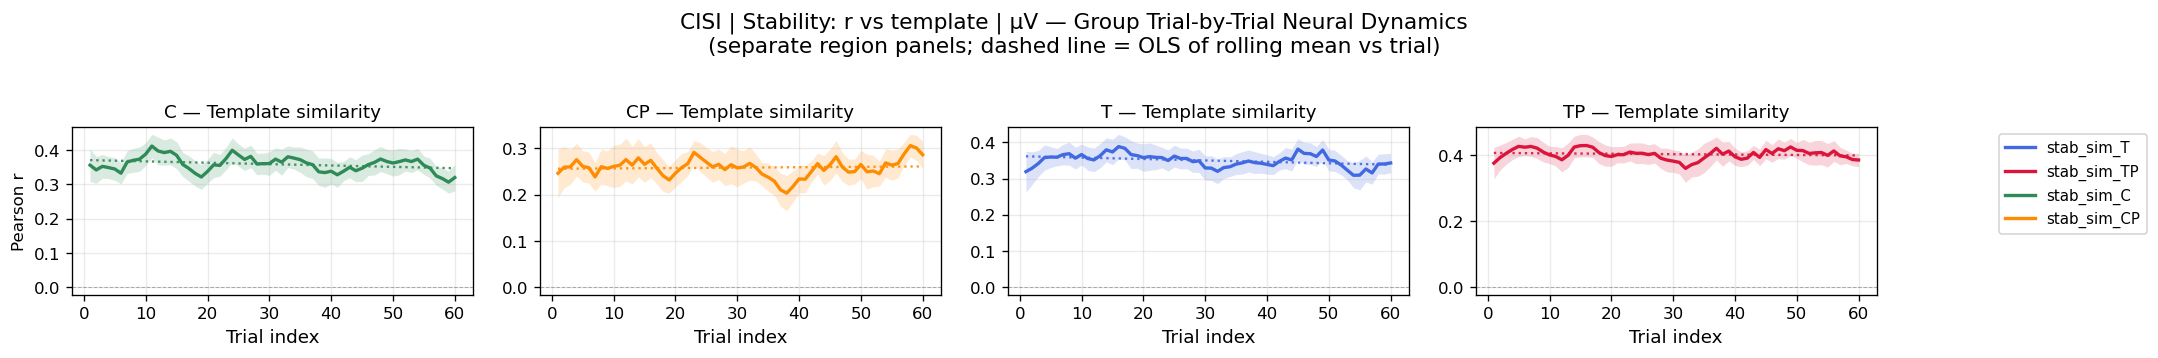

[trial dynamics] CISI | Stability: distance to previous trial | µV | keys=['stab_dist_T', 'stab_dist_TP', 'stab_dist_C', 'stab_dist_CP'] | n_groups=4
CISI | Stability: distance to previous trial | µV | C | Trial-to-trial distance | stab_dist_C: β=-0.007687, p=0.588 (n.s.)
CISI | Stability: distance to previous trial | µV | CP | Trial-to-trial distance | stab_dist_CP: β=0.1588, p=0.000193 ***
CISI | Stability: distance to previous trial | µV | T | Trial-to-trial distance | stab_dist_T: β=0.1158, p=0.00498 **
CISI | Stability: distance to previous trial | µV | TP | Trial-to-trial distance | stab_dist_TP: β=0.07062, p=0.00352 **


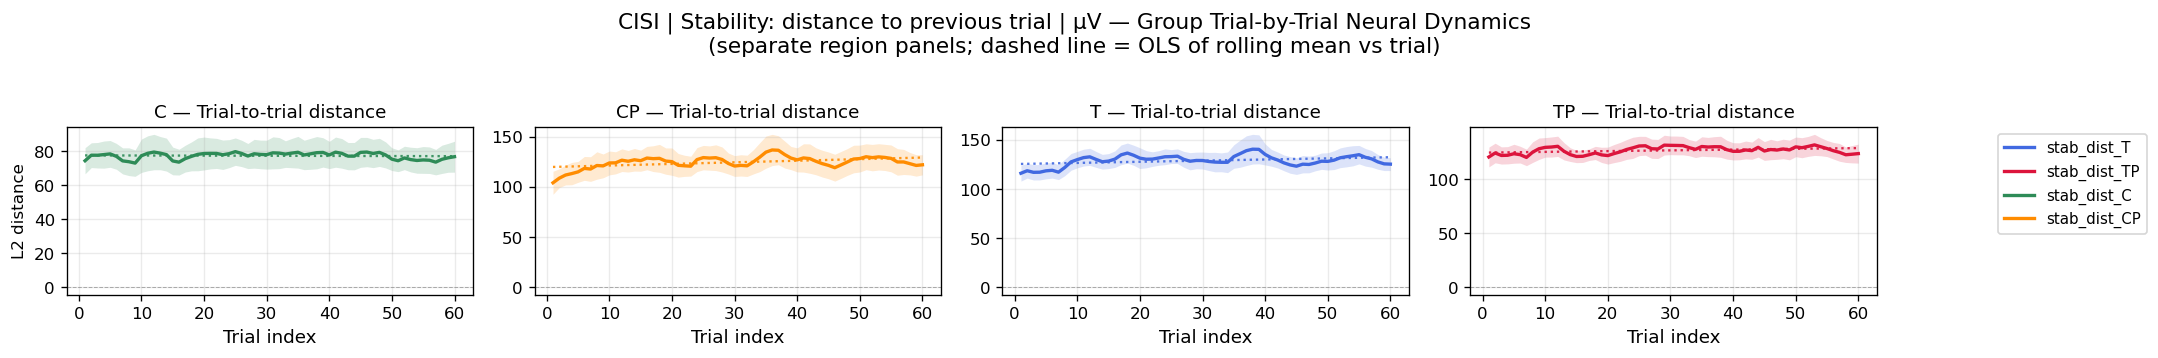

[trial dynamics] CISI | A-locked (0 ms) | Mean amplitude | z | keys=['P50_A', 'N1_A', 'P2_A', 'N2_A', 'P3_A'] | n_groups=4
CISI | A-locked (0 ms) | Mean amplitude | z | C | Mean amplitude | P50_A: β=-0.0003306, p=0.51 (n.s.)
CISI | A-locked (0 ms) | Mean amplitude | z | C | Mean amplitude | N1_A: β=-0.001183, p=0.00474 **
CISI | A-locked (0 ms) | Mean amplitude | z | C | Mean amplitude | P2_A: β=-0.001626, p=1.14e-06 ***
CISI | A-locked (0 ms) | Mean amplitude | z | C | Mean amplitude | N2_A: β=-0.00119, p=0.00733 **
CISI | A-locked (0 ms) | Mean amplitude | z | C | Mean amplitude | P3_A: β=0.0001368, p=0.702 (n.s.)
CISI | A-locked (0 ms) | Mean amplitude | z | CP | Mean amplitude | P50_A: β=-0.003118, p=3.49e-07 ***
CISI | A-locked (0 ms) | Mean amplitude | z | CP | Mean amplitude | N1_A: β=-0.00202, p=0.00307 **
CISI | A-locked (0 ms) | Mean amplitude | z | CP | Mean amplitude | P2_A: β=-0.002547, p=1.27e-05 ***
CISI | A-locked (0 ms) | Mean amplitude | z | CP | Mean amplitude | N2_A

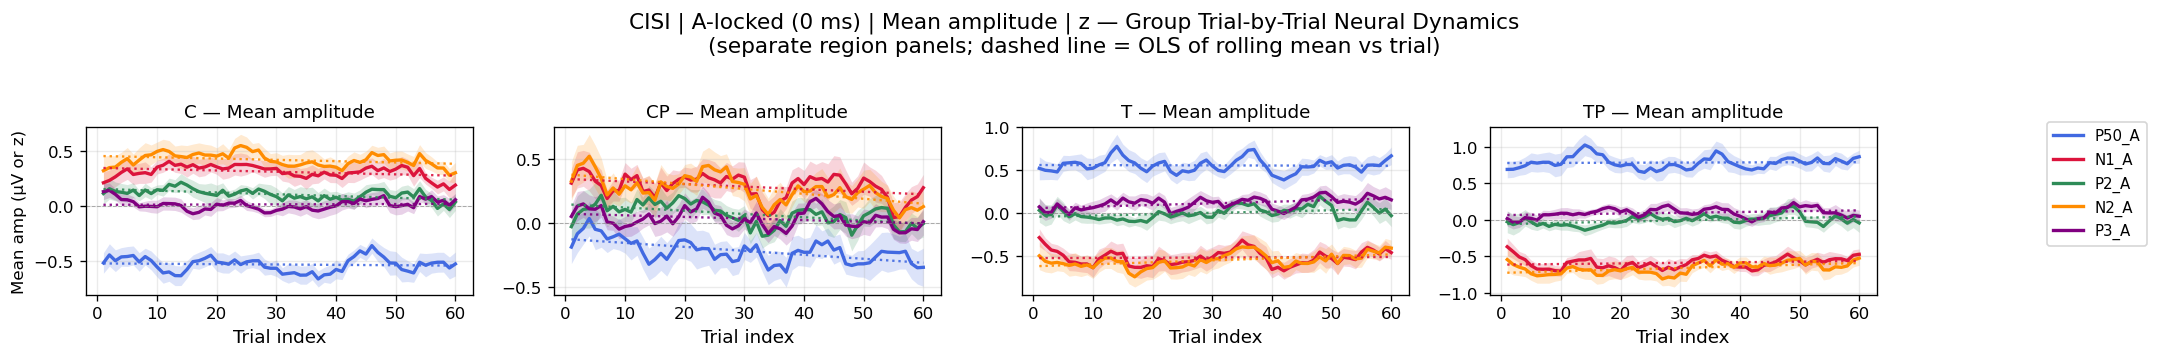

[trial dynamics] CISI | T-locked (500 ms) | Mean amplitude | z | keys=['P50_T', 'N1_T', 'P2_T', 'N2_T', 'P3_T'] | n_groups=4
CISI | T-locked (500 ms) | Mean amplitude | z | C | Mean amplitude | P50_T: β=-0.001135, p=0.00369 **
CISI | T-locked (500 ms) | Mean amplitude | z | C | Mean amplitude | N1_T: β=0.002889, p=3.85e-14 ***
CISI | T-locked (500 ms) | Mean amplitude | z | C | Mean amplitude | P2_T: β=0.001403, p=3.31e-05 ***
CISI | T-locked (500 ms) | Mean amplitude | z | C | Mean amplitude | N2_T: β=0.001281, p=0.000372 ***
CISI | T-locked (500 ms) | Mean amplitude | z | C | Mean amplitude | P3_T: β=-0.0005847, p=0.111 (n.s.)
CISI | T-locked (500 ms) | Mean amplitude | z | CP | Mean amplitude | P50_T: β=-0.0007514, p=0.331 (n.s.)
CISI | T-locked (500 ms) | Mean amplitude | z | CP | Mean amplitude | N1_T: β=0.001408, p=0.0214 *
CISI | T-locked (500 ms) | Mean amplitude | z | CP | Mean amplitude | P2_T: β=-0.0004121, p=0.542 (n.s.)
CISI | T-locked (500 ms) | Mean amplitude | z | CP | 

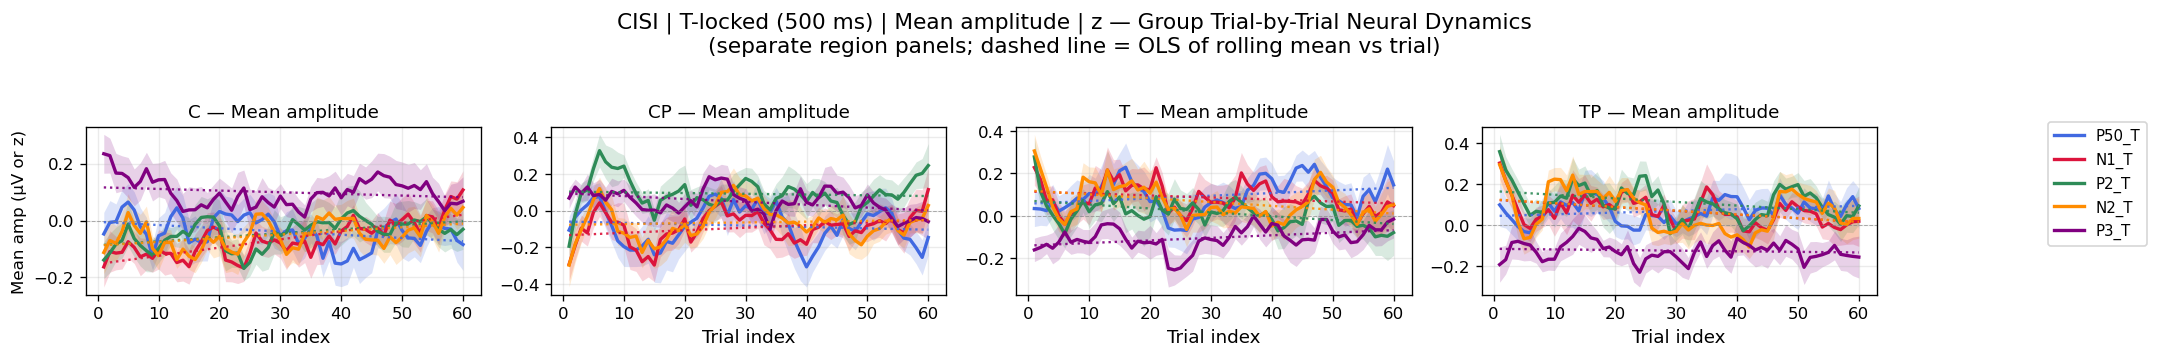

[trial dynamics] CISI | Anticipation (300–500 ms) | Mean amplitude | z | keys=['f_ant'] | n_groups=4
CISI | Anticipation (300–500 ms) | Mean amplitude | z | C | Mean amplitude | f_ant: β=-0.0005337, p=0.129 (n.s.)
CISI | Anticipation (300–500 ms) | Mean amplitude | z | CP | Mean amplitude | f_ant: β=-0.001439, p=0.00418 **
CISI | Anticipation (300–500 ms) | Mean amplitude | z | T | Mean amplitude | f_ant: β=0.002184, p=1.11e-06 ***
CISI | Anticipation (300–500 ms) | Mean amplitude | z | TP | Mean amplitude | f_ant: β=0.001836, p=2.63e-06 ***


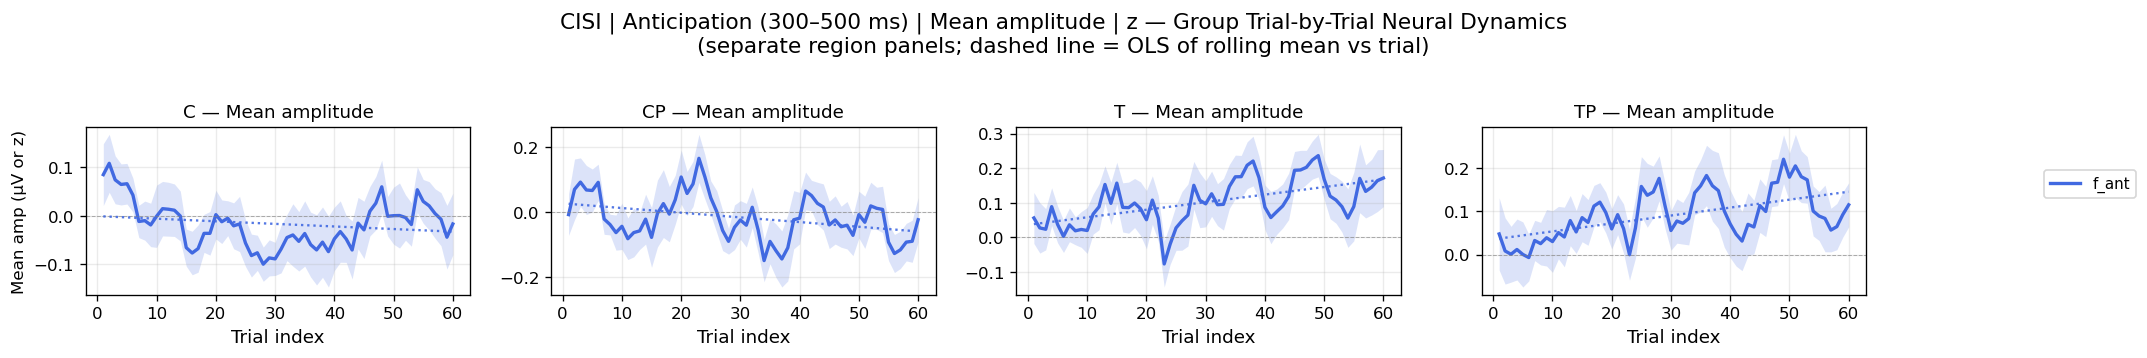

[trial dynamics] CISI | A-locked (0 ms) | Peak amplitude | z | keys=['P50_A', 'N1_A', 'P2_A', 'N2_A', 'P3_A'] | n_groups=4
CISI | A-locked (0 ms) | Peak amplitude | z | C | Peak amplitude | P50_A: β=-1.804e-05, p=0.969 (n.s.)
CISI | A-locked (0 ms) | Peak amplitude | z | C | Peak amplitude | N1_A: β=-0.001418, p=0.0146 *
CISI | A-locked (0 ms) | Peak amplitude | z | C | Peak amplitude | P2_A: β=-0.0007883, p=0.0868 (n.s.)
CISI | A-locked (0 ms) | Peak amplitude | z | C | Peak amplitude | N2_A: β=-0.001713, p=0.000914 ***
CISI | A-locked (0 ms) | Peak amplitude | z | C | Peak amplitude | P3_A: β=0.001017, p=0.0307 *
CISI | A-locked (0 ms) | Peak amplitude | z | CP | Peak amplitude | P50_A: β=-0.002475, p=3.62e-05 ***
CISI | A-locked (0 ms) | Peak amplitude | z | CP | Peak amplitude | N1_A: β=-0.003198, p=1.37e-05 ***
CISI | A-locked (0 ms) | Peak amplitude | z | CP | Peak amplitude | P2_A: β=-0.001785, p=0.0012 **
CISI | A-locked (0 ms) | Peak amplitude | z | CP | Peak amplitude | N2_A:

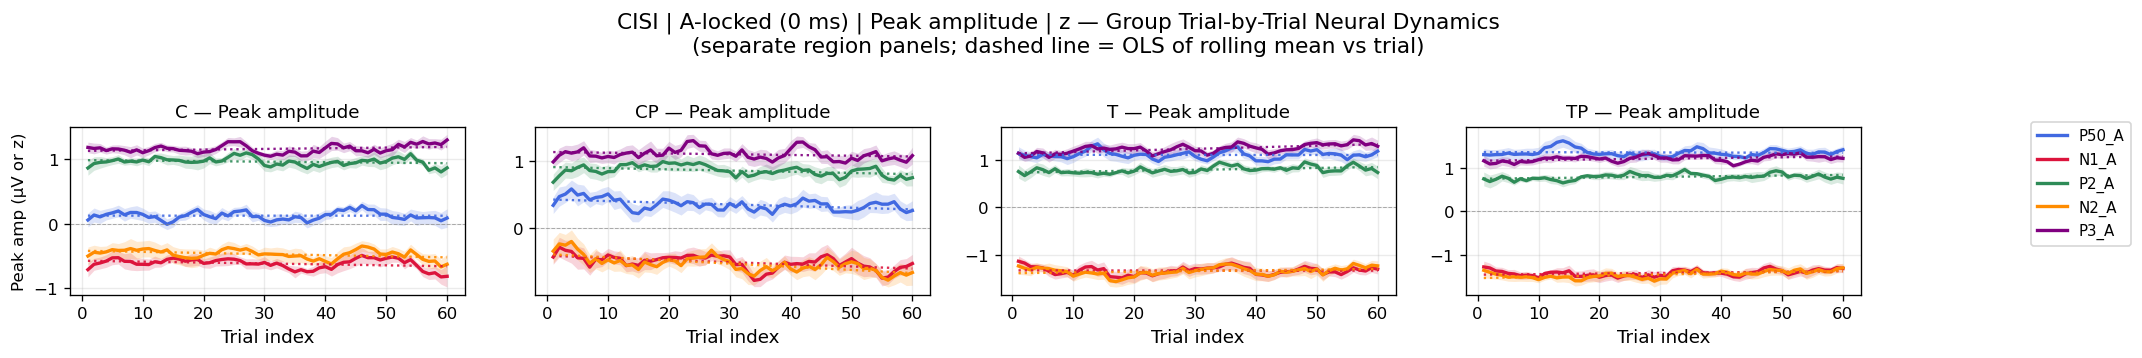

[trial dynamics] CISI | T-locked (500 ms) | Peak amplitude | z | keys=['P50_T', 'N1_T', 'P2_T', 'N2_T', 'P3_T'] | n_groups=4
CISI | T-locked (500 ms) | Peak amplitude | z | C | Peak amplitude | P50_T: β=-0.0009116, p=0.0942 (n.s.)
CISI | T-locked (500 ms) | Peak amplitude | z | C | Peak amplitude | N1_T: β=0.001858, p=0.000267 ***
CISI | T-locked (500 ms) | Peak amplitude | z | C | Peak amplitude | P2_T: β=0.003141, p=3.75e-11 ***
CISI | T-locked (500 ms) | Peak amplitude | z | C | Peak amplitude | N2_T: β=0.0005472, p=0.0894 (n.s.)
CISI | T-locked (500 ms) | Peak amplitude | z | C | Peak amplitude | P3_T: β=0.0003485, p=0.422 (n.s.)
CISI | T-locked (500 ms) | Peak amplitude | z | CP | Peak amplitude | P50_T: β=-6.911e-05, p=0.921 (n.s.)
CISI | T-locked (500 ms) | Peak amplitude | z | CP | Peak amplitude | N1_T: β=0.001479, p=0.0165 *
CISI | T-locked (500 ms) | Peak amplitude | z | CP | Peak amplitude | P2_T: β=0.001105, p=0.0943 (n.s.)
CISI | T-locked (500 ms) | Peak amplitude | z | C

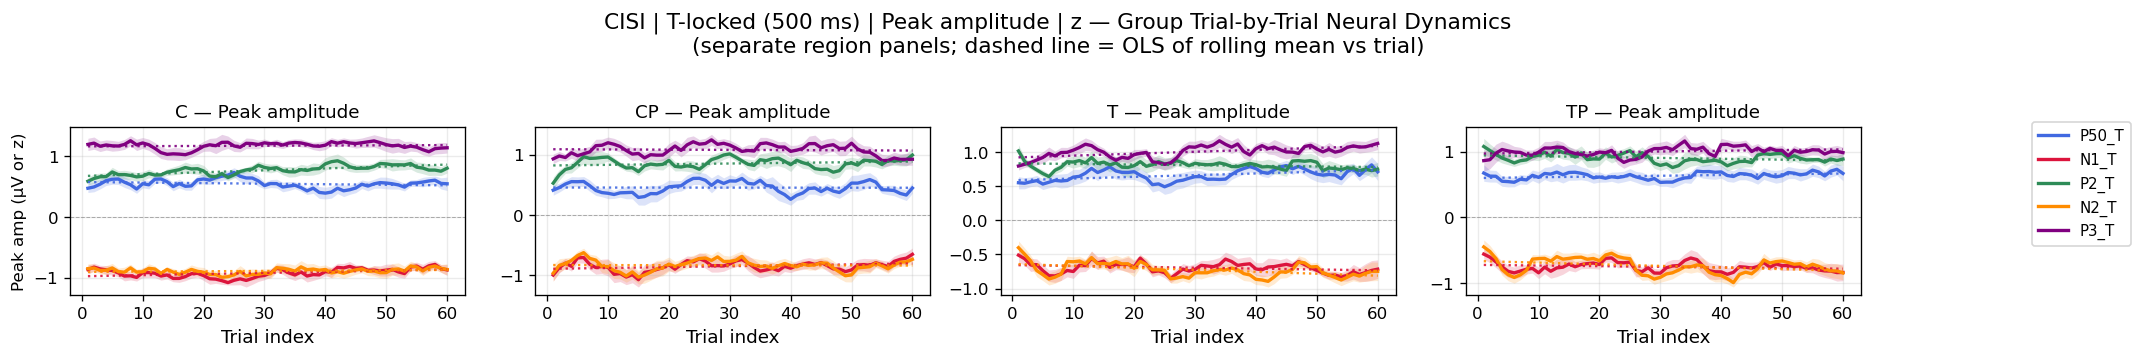

[trial dynamics] CISI | Anticipation (300–500 ms) | Peak amplitude | z | keys=['f_ant'] | n_groups=4
CISI | Anticipation (300–500 ms) | Peak amplitude | z | C | Peak amplitude | f_ant: β=6.895e-05, p=0.873 (n.s.)
CISI | Anticipation (300–500 ms) | Peak amplitude | z | CP | Peak amplitude | f_ant: β=-0.0006837, p=0.229 (n.s.)
CISI | Anticipation (300–500 ms) | Peak amplitude | z | T | Peak amplitude | f_ant: β=0.003197, p=9.13e-09 ***
CISI | Anticipation (300–500 ms) | Peak amplitude | z | TP | Peak amplitude | f_ant: β=0.002079, p=0.00014 ***


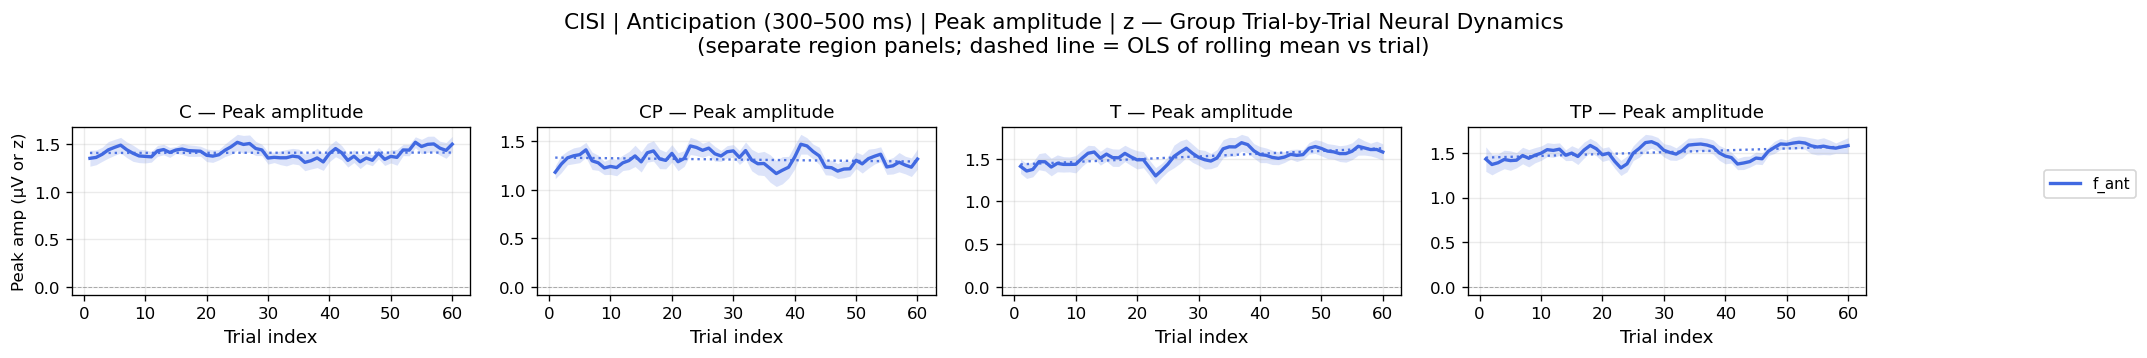

[trial dynamics] CISI | A-locked (0 ms) | Peak latency | z | keys=['P50_A', 'N1_A', 'P2_A', 'N2_A', 'P3_A'] | n_groups=4
CISI | A-locked (0 ms) | Peak latency | z | C | Peak latency | P50_A: β=0.03386, p=1.84e-07 ***
CISI | A-locked (0 ms) | Peak latency | z | C | Peak latency | N1_A: β=0.02451, p=0.0158 *
CISI | A-locked (0 ms) | Peak latency | z | C | Peak latency | P2_A: β=0.006798, p=0.522 (n.s.)
CISI | A-locked (0 ms) | Peak latency | z | C | Peak latency | N2_A: β=0.02181, p=0.0065 **
CISI | A-locked (0 ms) | Peak latency | z | C | Peak latency | P3_A: β=-0.03415, p=0.0204 *
CISI | A-locked (0 ms) | Peak latency | z | CP | Peak latency | P50_A: β=-0.02021, p=0.0183 *
CISI | A-locked (0 ms) | Peak latency | z | CP | Peak latency | N1_A: β=0.03446, p=0.00367 **
CISI | A-locked (0 ms) | Peak latency | z | CP | Peak latency | P2_A: β=-0.008684, p=0.49 (n.s.)
CISI | A-locked (0 ms) | Peak latency | z | CP | Peak latency | N2_A: β=0.02373, p=0.027 *
CISI | A-locked (0 ms) | Peak latenc

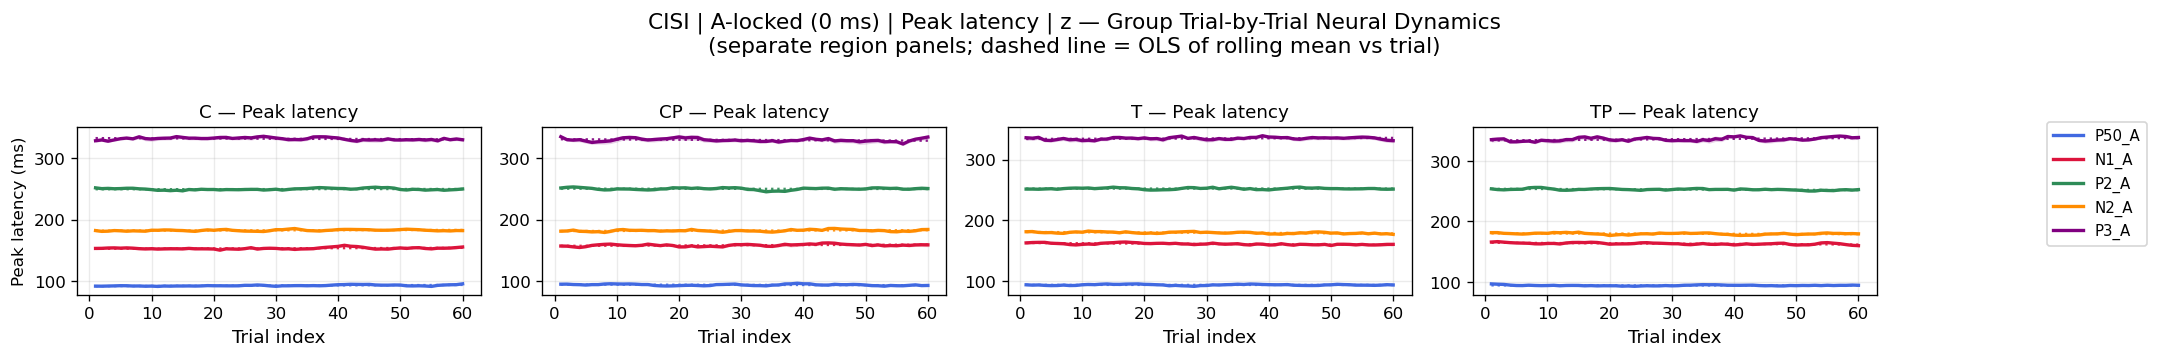

[trial dynamics] CISI | T-locked (500 ms) | Peak latency | z | keys=['P50_T', 'N1_T', 'P2_T', 'N2_T', 'P3_T'] | n_groups=4
CISI | T-locked (500 ms) | Peak latency | z | C | Peak latency | P50_T: β=0.0175, p=0.000109 ***
CISI | T-locked (500 ms) | Peak latency | z | C | Peak latency | N1_T: β=-0.009646, p=0.262 (n.s.)
CISI | T-locked (500 ms) | Peak latency | z | C | Peak latency | P2_T: β=0.002072, p=0.79 (n.s.)
CISI | T-locked (500 ms) | Peak latency | z | C | Peak latency | N2_T: β=0.04267, p=3.99e-05 ***
CISI | T-locked (500 ms) | Peak latency | z | C | Peak latency | P3_T: β=-0.001054, p=0.956 (n.s.)
CISI | T-locked (500 ms) | Peak latency | z | CP | Peak latency | P50_T: β=0.02123, p=0.0295 *
CISI | T-locked (500 ms) | Peak latency | z | CP | Peak latency | N1_T: β=0.006822, p=0.469 (n.s.)
CISI | T-locked (500 ms) | Peak latency | z | CP | Peak latency | P2_T: β=0.01526, p=0.154 (n.s.)
CISI | T-locked (500 ms) | Peak latency | z | CP | Peak latency | N2_T: β=0.01875, p=0.0579 (n.s

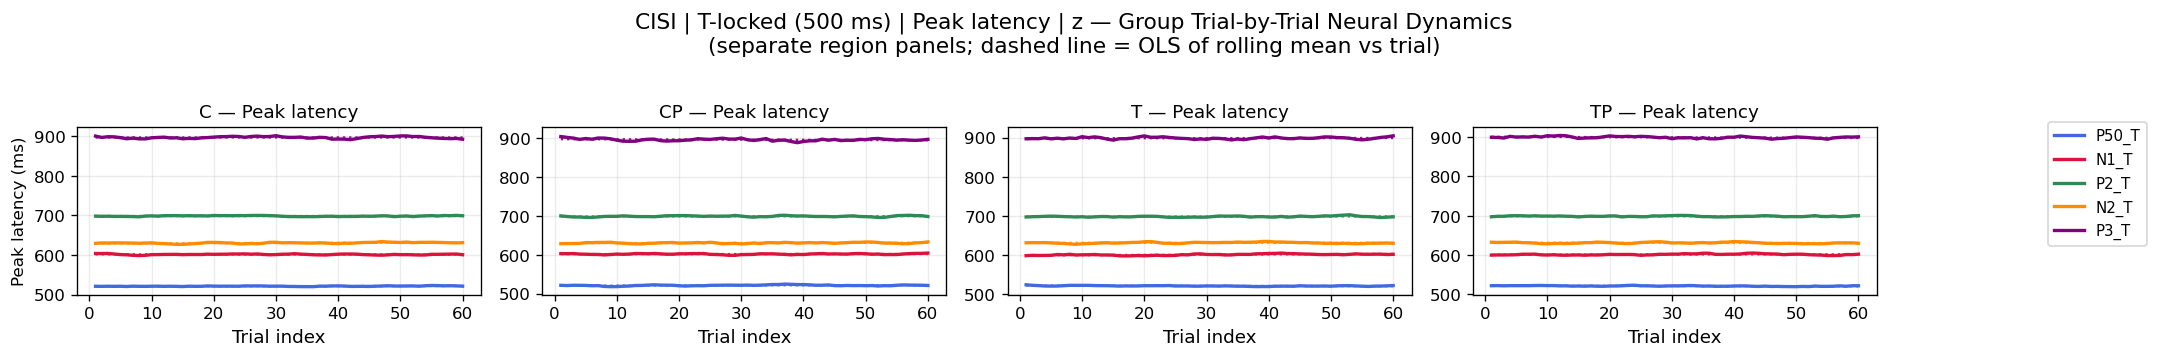

[trial dynamics] CISI | Anticipation (300–500 ms) | Peak latency | z | keys=['f_ant'] | n_groups=4
CISI | Anticipation (300–500 ms) | Peak latency | z | C | Peak latency | f_ant: β=-0.03297, p=0.485 (n.s.)
CISI | Anticipation (300–500 ms) | Peak latency | z | CP | Peak latency | f_ant: β=0.04205, p=0.129 (n.s.)
CISI | Anticipation (300–500 ms) | Peak latency | z | T | Peak latency | f_ant: β=0.008316, p=0.836 (n.s.)
CISI | Anticipation (300–500 ms) | Peak latency | z | TP | Peak latency | f_ant: β=0.01817, p=0.675 (n.s.)


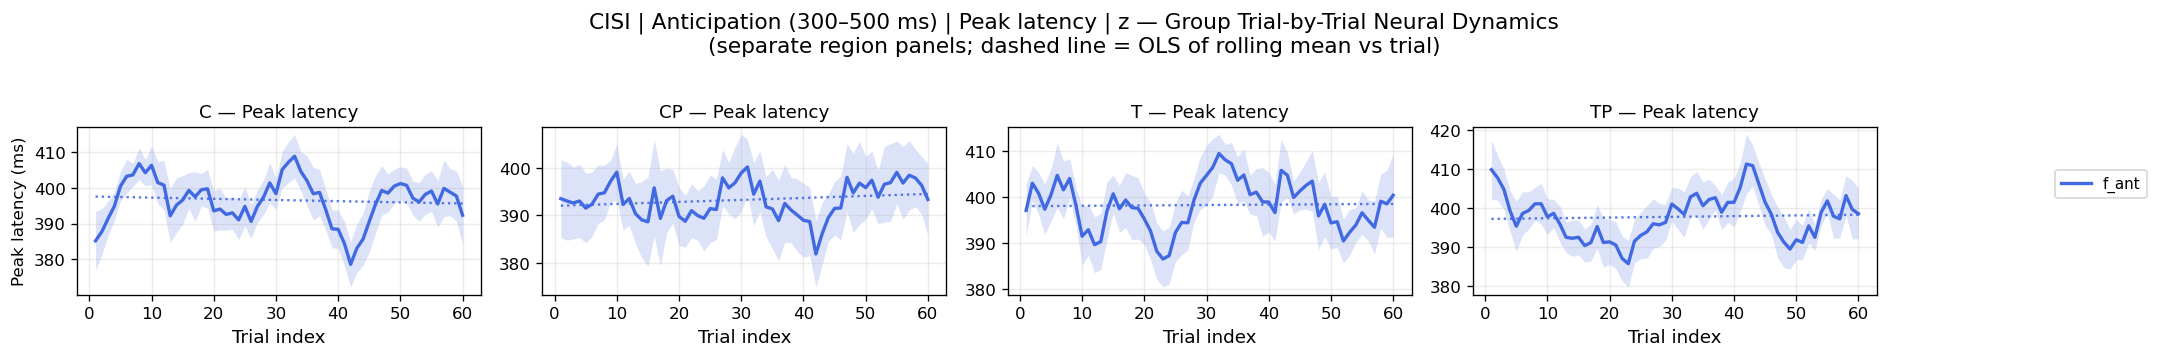

[trial dynamics] CISI | Welch band power (300–500 ms, dB vs baseline) | z | keys=['freq_ANT200_500_beta_db'] | n_groups=4
CISI | Welch band power (300–500 ms, dB vs baseline) | z | C | ANT window | freq_ANT200_500_beta_db: β=-0.01057, p=0.000193 ***
CISI | Welch band power (300–500 ms, dB vs baseline) | z | CP | ANT window | freq_ANT200_500_beta_db: β=-0.01057, p=0.000193 ***


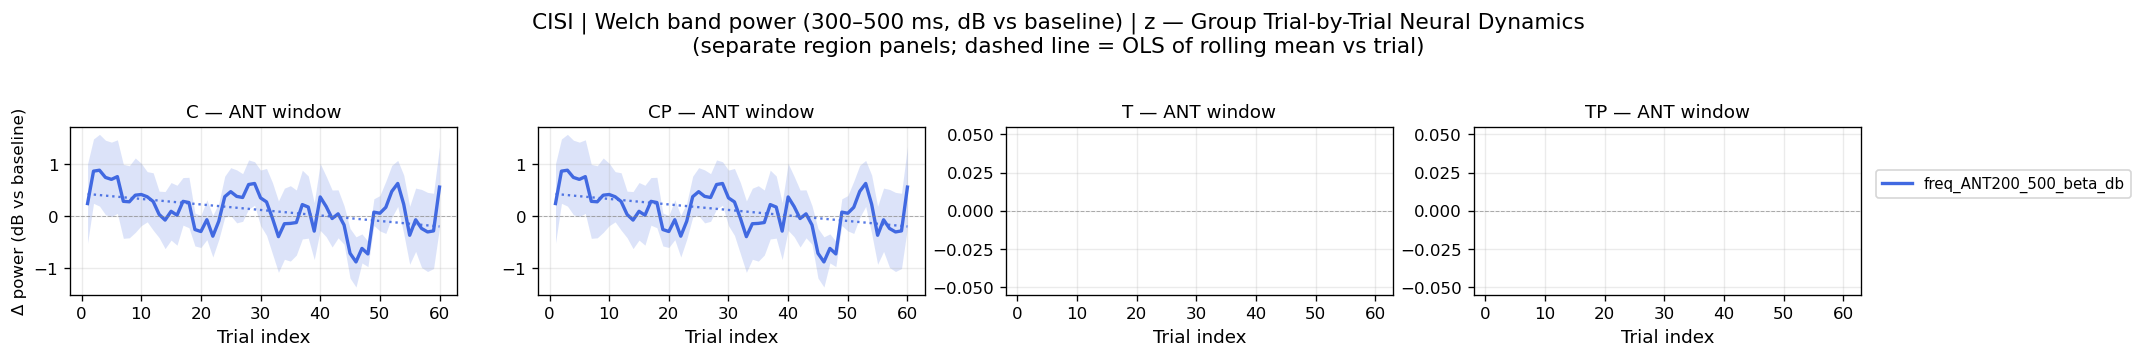

[trial dynamics] CISI | Stability: r vs template | z | keys=['stab_sim_T', 'stab_sim_TP', 'stab_sim_C', 'stab_sim_CP'] | n_groups=4
CISI | Stability: r vs template | z | C | Template similarity | stab_sim_C: β=-0.0004007, p=0.0142 *
CISI | Stability: r vs template | z | CP | Template similarity | stab_sim_CP: β=8.467e-05, p=0.562 (n.s.)
CISI | Stability: r vs template | z | T | Template similarity | stab_sim_T: β=-0.0003918, p=0.0033 **
CISI | Stability: r vs template | z | TP | Template similarity | stab_sim_TP: β=-0.0001256, p=0.277 (n.s.)


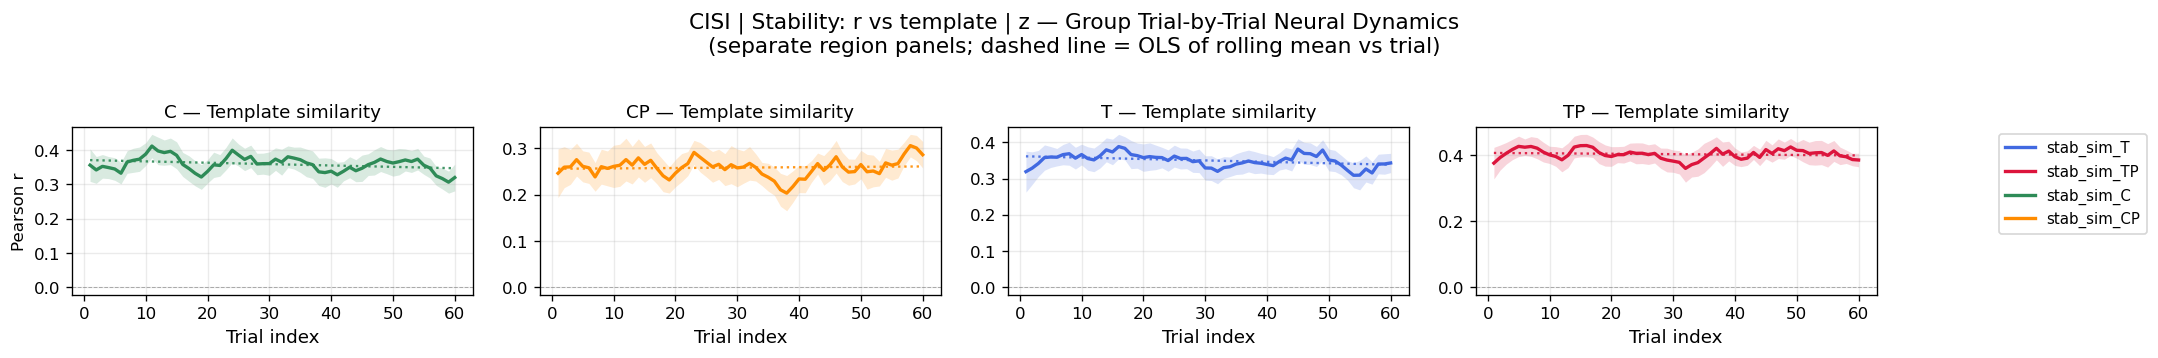

[trial dynamics] CISI | Stability: distance to previous trial | z | keys=['stab_dist_T', 'stab_dist_TP', 'stab_dist_C', 'stab_dist_CP'] | n_groups=4
CISI | Stability: distance to previous trial | z | C | Trial-to-trial distance | stab_dist_C: β=-0.007687, p=0.588 (n.s.)
CISI | Stability: distance to previous trial | z | CP | Trial-to-trial distance | stab_dist_CP: β=0.1588, p=0.000193 ***
CISI | Stability: distance to previous trial | z | T | Trial-to-trial distance | stab_dist_T: β=0.1158, p=0.00498 **
CISI | Stability: distance to previous trial | z | TP | Trial-to-trial distance | stab_dist_TP: β=0.07062, p=0.00352 **


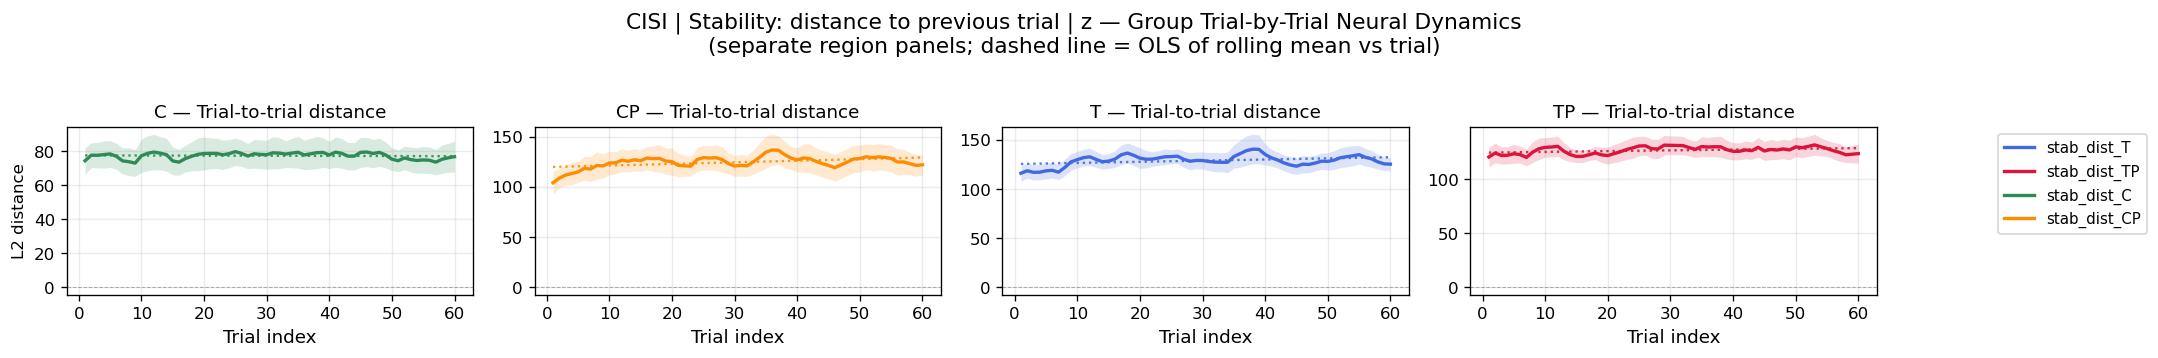

In [18]:
# Trial-by-trial dynamics: A / T / anticipation (mean, peak amp, peak latency)
# + ANT-window band power (Welch) + stability (template r + trial distance)
#
# Run this cell after the `plot_group_trial_dynamics` definition cell. If figures
# do not appear, run the imports cell with `%matplotlib inline` first (cell 2).

%matplotlib inline
print("§5b: trial dynamics — generating figures (one [trial dynamics] line per figure)", flush=True)

_METRICS = [
    ("mean_amp_roll_mean", "mean_amp_roll_sem", "Mean amp (µV or z)", "Mean amplitude"),
    ("peak_amp_roll_mean", "peak_amp_roll_sem", "Peak amp (µV or z)", "Peak amplitude"),
    ("peak_lat_ms_roll_mean", "peak_lat_ms_roll_sem", "Peak latency (ms)", "Peak latency"),
]

for tag, df in [
    ("µV", erp_roi_group_roll_df_bc),
    ("z", erp_roi_group_roll_df_z),
]:
    for mean_suf, sem_suf, ylab, title_h in _METRICS:
        plot_group_trial_dynamics(
            erp_roi_group_roll_df=df,
            feature_keys=AUDITORY_COMPS,
            CONDITION=f"{CHANNELS} | A-locked (0 ms) | {title_h} | {tag}",
            group_col="region",
            b_plot_channel_seperate=True,
            feature_specs=[(mean_suf, sem_suf, ylab, title_h)],
        )
        plot_group_trial_dynamics(
            erp_roi_group_roll_df=df,
            feature_keys=TACTILE_COMPS,
            CONDITION=f"{CHANNELS} | T-locked (500 ms) | {title_h} | {tag}",
            group_col="region",
            b_plot_channel_seperate=True,
            feature_specs=[(mean_suf, sem_suf, ylab, title_h)],
        )
        plot_group_trial_dynamics(
            erp_roi_group_roll_df=df,
            feature_keys=["f_ant"],
            CONDITION=f"{CHANNELS} | Anticipation (300–500 ms) | {title_h} | {tag}",
            group_col="region",
            b_plot_channel_seperate=True,
            feature_specs=[(mean_suf, sem_suf, ylab, title_h)],
        )

    plot_group_trial_dynamics(
        erp_roi_group_roll_df=df,
        feature_keys=["freq_ANT200_500_beta_db"],
        CONDITION=f"{CHANNELS} | Welch band power (300–500 ms, dB vs baseline) | {tag}",
        group_col="region",
        b_plot_channel_seperate=True,
        feature_specs=[("roll_mean", "roll_sem", "Δ power (dB vs baseline)", "ANT window")],
    )

    plot_group_trial_dynamics(
        erp_roi_group_roll_df=df,
        feature_keys=["stab_sim_T", "stab_sim_TP", "stab_sim_C", "stab_sim_CP"],
        CONDITION=f"{CHANNELS} | Stability: r vs template | {tag}",
        group_col="region",
        b_plot_channel_seperate=True,
        feature_specs=[("roll_mean", "roll_sem", "Pearson r", "Template similarity")],
    )

    plot_group_trial_dynamics(
        erp_roi_group_roll_df=df,
        feature_keys=["stab_dist_T", "stab_dist_TP", "stab_dist_C", "stab_dist_CP"],
        CONDITION=f"{CHANNELS} | Stability: distance to previous trial | {tag}",
        group_col="region",
        b_plot_channel_seperate=True,
        feature_specs=[("roll_mean", "roll_sem", "L2 distance", "Trial-to-trial distance")],
    )


In [19]:
# Optional overlay mode examples
# plot_group_trial_dynamics(
#     erp_roi_group_roll_df=erp_roi_group_roll_df,
#     feature_keys=AUDITORY_COMPS,
#     CONDITION=f"{CHANNELS} | A-locked (overlay)",
#     group_col="region",
#     b_plot_channel_seperate=False,
# )
#
# plot_group_trial_dynamics(
#     erp_roi_group_roll_df=erp_roi_group_roll_df,
#     feature_keys=TACTILE_COMPS,
#     CONDITION=f"{CHANNELS} | T-locked (overlay)",
#     group_col="region",
#     b_plot_channel_seperate=False,
# )

## Summary

| Step | Details |
|---|---|
| Protocol | BLA (Baseline Audio) |
| Subject | 5 |
| ROI | T7, T8, TP7, TP8 (temporal/temporo-parietal) |
| Trials (auditory) | varies ("No auditory" removed by `load_eeg_data`) |
| Baseline / variants | −500 ms to −50 ms subtract mean → `data_bc` (µV); copy + per-subject × channel z → `data_bc_z` |
| Feature windows | Same windows in **µV** (`*_bc`) and **z** (`*_z`); component peaks use `res_aud_bc` / `res_aud_z` |
| Rolling mean window | 5 trials (centered) |

Next steps:
- Repeat for other protocols (BLT, P1, P2, P3)
- Compare learning curves across protocols
- Statistical tests (e.g., linear regression of feature ~ trial_index)
